In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import os
import random
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA,TruncatedSVD
from mofapy2.run.entry_point import entry_point
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_similarity
import hdbscan
from umap import UMAP

# EDA

## Gene Expression Data set

In [3]:
hpa_rna_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene expression\1_4_hpa_rna_celline.tsv", sep='\t')
depmap_omicsexpressionallgenes_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene expression\2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv")
geoexpression_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene expression\3_GEOexpression.txt", sep='\t')
harmonized_ms_celline_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene expression\4_Harmonized_MS_CCLE_Gygi_subsetted.csv")

In [4]:
duplicate = hpa_rna_df[hpa_rna_df['nTPM'].duplicated()]
numeric_cols = duplicate.select_dtypes(include='number').columns
columns_to_keep = ['Gene'] + list(numeric_cols)
result_df = duplicate[columns_to_keep].groupby('Gene').aggregate('sum')
print(result_df)

                     TPM     pTPM     nTPM
Gene                                      
ENSG00000000003   8400.0  10693.2  10282.8
ENSG00000000005     78.2     99.4     88.7
ENSG00000000419  34064.9  43513.7  41903.3
ENSG00000000457   6615.0   8482.2   8328.3
ENSG00000000460  14957.3  19067.6  18622.8
...                  ...      ...      ...
ENSG00000291313   7624.6   9719.6   9275.2
ENSG00000291314    127.4    163.3    157.9
ENSG00000291315    177.9    229.7    220.0
ENSG00000291316  10278.4  13106.9  13098.3
ENSG00000291317  16319.2  20871.2  20977.9

[20162 rows x 3 columns]


In [5]:
print(hpa_rna_df.shape)
hpa_rna_df.head(20)

(24315372, 6)


,Gene,Gene name,Cell line,TPM,pTPM,nTPM
0,ENSG00000000003,TSPAN6,143B,22.0,27.6,25.9
1,ENSG00000000003,TSPAN6,22Rv1,2.8,3.6,2.7
2,ENSG00000000003,TSPAN6,23132/87,6.2,7.5,7.5
3,ENSG00000000003,TSPAN6,253J,14.2,18.7,25.4
4,ENSG00000000003,TSPAN6,253J-BV,13.0,17.1,18.5
5,ENSG00000000003,TSPAN6,42-MG-BA,14.1,17.7,18.6
6,ENSG00000000003,TSPAN6,537-mel,9.8,11.9,13.7
7,ENSG00000000003,TSPAN6,5637,33.5,39.7,44.4
8,ENSG00000000003,TSPAN6,59M,14.4,18.0,20.1
9,ENSG00000000003,TSPAN6,624-mel,11.6,14.6,15.7


In [6]:
gene_to_ensg = (
    hpa_rna_df[["Gene name", "Gene"]]
    .drop_duplicates()
)
gene_to_ensg.to_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene_to_ensg.csv', index=False)

In [7]:
hpa_rna_df.describe()

,TPM,pTPM,nTPM
count,2.431537e+07,2.431537e+07,2.431537e+07
mean,3.894269e+01,4.955707e+01,5.081671e+01
std,3.840951e+02,4.894009e+02,6.013716e+02
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.800000e+00,3.600000e+00,3.600000e+00
75%,1.790000e+01,2.280000e+01,2.250000e+01
max,1.534615e+05,1.837973e+05,4.211731e+05


In [8]:
hpa_rna_df.info

<bound method DataFrame.info of                      Gene Gene name Cell line   TPM  pTPM  nTPM
0         ENSG00000000003    TSPAN6      143B  22.0  27.6  25.9
1         ENSG00000000003    TSPAN6     22Rv1   2.8   3.6   2.7
2         ENSG00000000003    TSPAN6  23132/87   6.2   7.5   7.5
3         ENSG00000000003    TSPAN6      253J  14.2  18.7  25.4
4         ENSG00000000003    TSPAN6   253J-BV  13.0  17.1  18.5
...                   ...       ...       ...   ...   ...   ...
24315367  ENSG00000291317   TMEM276     YH-13  16.8  21.8  15.6
24315368  ENSG00000291317   TMEM276     YKG-1  25.1  32.2  24.0
24315369  ENSG00000291317   TMEM276     YMB-1  42.4  55.9  47.8
24315370  ENSG00000291317   TMEM276   ZR-75-1  30.0  40.9  30.8
24315371  ENSG00000291317   TMEM276  ZR-75-30  43.1  53.8  65.7

[24315372 rows x 6 columns]>

In [9]:
hpa_rna_df.dtypes

Gene             str
Gene name        str
Cell line        str
TPM          float64
pTPM         float64
nTPM         float64
dtype: object

In [10]:
non_numeric_columns = hpa_rna_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Gene', 'Gene name', 'Cell line'], dtype='str')


In [11]:
all_columns = hpa_rna_df.columns.tolist()
print(all_columns)

['Gene', 'Gene name', 'Cell line', 'TPM', 'pTPM', 'nTPM']


In [12]:
hpa_rna_df.isna().sum()

Gene         0
Gene name    0
Cell line    0
TPM          0
pTPM         0
nTPM         0
dtype: int64

In [13]:
hpa_rna_df.duplicated().sum()

np.int64(0)

In [14]:
print(depmap_omicsexpressionallgenes_df.shape)
depmap_omicsexpressionallgenes_df.head(20)

(1495, 53962)


,Unnamed: 0,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419),SCYL3 (ENSG00000000457),C1orf112 (ENSG00000000460),FGR (ENSG00000000938),CFH (ENSG00000000971),FUCA2 (ENSG00000001036),GCLC (ENSG00000001084),...,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723,ENSG00000288724,ENSG00000288725
0,PR-AdBjpG,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,0.000000,0.536053,0.000000,0.028569,0.176323,0.992768,2.797013,0.000000,0.0,0.000000
1,PR-I2AzwG,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,...,0.000000,0.879706,0.000000,0.014355,0.014355,0.432959,2.972693,0.056584,0.0,0.070389
2,PR-5ekAAC,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,0.028569,0.000000,0.084064,0.000000,0.097611,0.367371,1.695994,0.084064,0.0,0.000000
3,PR-I21681,5.085340,0.000000,7.154211,2.545968,3.084064,0.000000,5.868390,6.165309,4.489928,...,0.000000,0.000000,0.070389,0.000000,0.176323,0.411426,3.921246,0.028569,0.0,0.000000
4,PR-i9DRP1,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,...,0.000000,0.000000,0.201634,0.028569,0.137504,0.678072,4.418190,0.000000,0.0,0.000000
5,PR-llpknG,4.272770,0.189034,7.023255,2.555816,3.841973,0.000000,0.097611,4.888500,4.926948,...,0.000000,0.378512,0.176323,0.070389,0.163499,0.189034,3.054848,0.000000,0.0,0.000000
6,PR-feSGd6,3.337711,0.000000,5.927659,1.944858,2.678072,0.014355,3.090853,6.011451,3.642702,...,0.000000,0.495695,0.201634,0.042644,0.124328,0.422233,0.201634,0.000000,0.0,0.000000
7,PR-z36vet,0.056584,0.000000,6.094236,3.971773,3.731183,0.028569,6.093602,3.033863,3.422233,...,0.028569,0.000000,0.000000,0.014355,0.124328,1.304511,5.596637,0.124328,0.0,0.000000
8,PR-7WaDe1,4.017031,0.000000,6.534497,2.226509,3.021480,0.028569,0.084064,5.588565,6.380937,...,0.000000,0.163499,0.137504,0.014355,0.150560,2.906891,3.694880,0.000000,0.0,0.000000
9,PR-DPUwIm,4.412104,0.000000,6.412782,2.367371,4.275752,0.042644,0.201634,2.563158,6.104546,...,0.000000,0.000000,0.000000,0.028569,0.056584,0.839960,4.402586,0.042644,0.0,0.000000


In [15]:
depmap_omicsexpressionallgenes_df.iloc[:20, -10:]

,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723,ENSG00000288724,ENSG00000288725
0,0.000000,0.536053,0.000000,0.028569,0.176323,0.992768,2.797013,0.000000,0.0,0.000000
1,0.000000,0.879706,0.000000,0.014355,0.014355,0.432959,2.972693,0.056584,0.0,0.070389
2,0.028569,0.000000,0.084064,0.000000,0.097611,0.367371,1.695994,0.084064,0.0,0.000000
3,0.000000,0.000000,0.070389,0.000000,0.176323,0.411426,3.921246,0.028569,0.0,0.000000
4,0.000000,0.000000,0.201634,0.028569,0.137504,0.678072,4.418190,0.000000,0.0,0.000000
5,0.000000,0.378512,0.176323,0.070389,0.163499,0.189034,3.054848,0.000000,0.0,0.000000
6,0.000000,0.495695,0.201634,0.042644,0.124328,0.422233,0.201634,0.000000,0.0,0.000000
7,0.028569,0.000000,0.000000,0.014355,0.124328,1.304511,5.596637,0.124328,0.0,0.000000
8,0.000000,0.163499,0.137504,0.014355,0.150560,2.906891,3.694880,0.000000,0.0,0.000000
9,0.000000,0.000000,0.000000,0.028569,0.056584,0.839960,4.402586,0.042644,0.0,0.000000


In [16]:
depmap_omicsexpressionallgenes_df.describe()

,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419),SCYL3 (ENSG00000000457),C1orf112 (ENSG00000000460),FGR (ENSG00000000938),CFH (ENSG00000000971),FUCA2 (ENSG00000001036),GCLC (ENSG00000001084),NFYA (ENSG00000001167),...,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723,ENSG00000288724,ENSG00000288725
count,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,...,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000,1495.000000
mean,3.395123,0.076698,6.520645,2.366344,3.681424,0.427724,2.188295,5.161709,4.634028,4.048976,...,0.072130,0.100204,0.107615,0.026638,0.203767,0.626107,3.876529,0.061337,0.024432,0.014491
std,1.631365,0.372394,0.644190,0.540800,0.793538,1.225619,2.256766,1.812508,1.145805,0.745015,...,0.249766,0.207503,0.197683,0.037471,0.284223,0.395719,1.128181,0.135742,0.210555,0.039687
min,0.000000,0.000000,3.655352,0.594549,0.056584,0.000000,0.000000,0.000000,1.195348,0.815575,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.908813,0.000000,6.114992,2.007196,3.238022,0.014355,0.124328,4.743353,3.906890,3.587965,...,0.000000,0.000000,0.000000,0.000000,0.056584,0.367371,3.191405,0.000000,0.000000,0.000000
50%,3.820690,0.000000,6.504779,2.336283,3.751678,0.042644,1.257011,5.709291,4.505256,4.021480,...,0.000000,0.000000,0.028569,0.014355,0.124328,0.565597,3.943921,0.000000,0.000000,0.000000
75%,4.447249,0.000000,6.934045,2.670160,4.192589,0.137504,4.016585,6.297741,5.265097,4.481880,...,0.028569,0.150560,0.124328,0.042644,0.238787,0.807355,4.645010,0.070389,0.000000,0.000000
max,8.132680,5.251340,9.175250,4.747387,5.972463,8.014299,9.693016,8.633068,9.581991,7.434211,...,2.855990,1.871844,1.641546,0.669027,3.263034,4.485427,7.455492,2.424922,4.577731,0.536053


In [17]:
depmap_omicsexpressionallgenes_df.dtypes

Unnamed: 0                      str
TSPAN6 (ENSG00000000003)    float64
TNMD (ENSG00000000005)      float64
DPM1 (ENSG00000000419)      float64
SCYL3 (ENSG00000000457)     float64
                             ...   
ENSG00000288721             float64
ENSG00000288722             float64
ENSG00000288723             float64
ENSG00000288724             float64
ENSG00000288725             float64
Length: 53962, dtype: object

In [18]:
non_numeric_columns = depmap_omicsexpressionallgenes_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Unnamed: 0'], dtype='str')


In [19]:
depmap_omicsexpressionallgenes_df.info

<bound method DataFrame.info of      Unnamed: 0  TSPAN6 (ENSG00000000003)  TNMD (ENSG00000000005)  \
0     PR-AdBjpG                  4.331992                0.000000   
1     PR-I2AzwG                  4.567424                0.584963   
2     PR-5ekAAC                  3.150560                0.000000   
3     PR-I21681                  5.085340                0.000000   
4     PR-i9DRP1                  6.729417                0.000000   
...         ...                       ...                     ...   
1490  PR-ACNZor                  0.056584                0.000000   
1491  PR-eZ3iv8                  3.111031                0.000000   
1492  PR-RWNv81                  4.390943                0.000000   
1493  PR-IVFp8S                  5.057450                0.000000   
1494  PR-AsIpQ0                  4.249445                0.000000   

      DPM1 (ENSG00000000419)  SCYL3 (ENSG00000000457)  \
0                   7.364660                 2.792855   
1                   7.106

In [20]:
depmap_omicsexpressionallgenes_df.isna().sum()

Unnamed: 0                  0
TSPAN6 (ENSG00000000003)    0
TNMD (ENSG00000000005)      0
DPM1 (ENSG00000000419)      0
SCYL3 (ENSG00000000457)     0
                           ..
ENSG00000288721             0
ENSG00000288722             0
ENSG00000288723             0
ENSG00000288724             0
ENSG00000288725             0
Length: 53962, dtype: int64

In [21]:
nullcolumns = depmap_omicsexpressionallgenes_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Series([], dtype: int64)


In [22]:
depmap_omicsexpressionallgenes_df.duplicated().sum()

np.int64(0)

In [23]:
print(geoexpression_df.shape)
geoexpression_df.head(20)

(19914, 3268)


,Gene,GSM101610,GSM101615,GSM101616,GSM101667,GSM101668,GSM101671,GSM101672,GSM101673,GSM101674,...,GSM960289,GSM960290,GSM960291,GSM960292,GSM960293,GSM960294,GSM960295,GSM960296,GSM960297,GSM960298
0,ENSG00000000003,33.615700,553.249756,540.452209,599.431152,625.242737,400.554657,412.995605,427.403900,461.123535,...,197.712616,387.427826,116.657890,104.889442,158.400604,736.519043,631.033142,791.054504,181.986893,353.206940
1,ENSG00000000005,40.925682,31.327406,33.934967,34.213123,32.466286,36.243233,37.952511,34.644428,34.225410,...,4.392303,4.230473,4.651096,5.175624,5.540960,4.211264,4.159354,4.480873,4.630062,4.296047
2,ENSG00000000419,2182.281250,3419.430420,3514.540039,2295.817383,2378.469727,2297.564697,2276.069092,2368.761475,2689.160156,...,936.201782,1162.099731,1249.029053,1354.346069,1159.747559,1561.643799,1547.089233,1551.400146,939.964661,1054.350952
3,ENSG00000000457,58.934814,95.068222,94.900459,51.810070,52.327530,50.011375,53.793667,51.172344,52.677490,...,35.778347,57.736485,25.528204,24.593216,23.337006,47.793488,41.268002,64.042831,37.363773,61.027988
4,ENSG00000000460,136.418900,257.929169,271.317230,162.090073,160.913849,206.788635,209.966019,134.272583,147.408554,...,14.693585,19.083935,114.056015,137.948593,149.641708,111.793892,98.536613,167.151016,12.268769,24.296593
5,ENSG00000000938,58.961063,58.337406,64.827354,55.533710,51.006062,69.440880,55.008999,64.824722,58.586369,...,14.391623,24.941059,14.099665,13.392654,12.757866,9.116057,11.402735,10.913387,18.854208,23.200811
6,ENSG00000000971,49.317619,111.684074,110.419968,79.690567,66.069588,216.304184,233.937775,171.663483,169.657028,...,20.188559,52.287491,99.496101,135.342010,13.649463,137.864365,211.410019,344.196777,18.037682,54.376209
7,ENSG00000001036,986.179993,38.604950,23.709663,725.873901,772.674133,1516.985596,1695.581787,981.308777,1165.871704,...,152.760193,166.487946,532.568787,515.504700,475.281921,6.495412,4.887550,6.498924,157.187805,187.251465
8,ENSG00000001084,218.264709,205.202942,200.642609,233.214645,223.126877,92.675636,89.431686,330.104645,333.135315,...,215.719269,123.029762,57.266422,53.720882,75.023865,48.775723,48.510746,92.809387,223.896881,112.630020
9,ENSG00000001167,179.806183,249.743027,255.897781,207.392105,223.114822,248.164932,270.961823,187.782852,207.790283,...,32.982491,41.809486,39.377907,35.673672,53.231068,44.077847,39.596142,58.676270,33.619946,44.179768


In [24]:
geoexpression_df.describe()

,GSM101610,GSM101615,GSM101616,GSM101667,GSM101668,GSM101671,GSM101672,GSM101673,GSM101674,GSM101675,...,GSM960289,GSM960290,GSM960291,GSM960292,GSM960293,GSM960294,GSM960295,GSM960296,GSM960297,GSM960298
count,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,...,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000,19914.000000
mean,307.754267,309.811280,319.028222,301.564948,315.117556,306.957109,318.178358,287.086383,313.387723,295.329853,...,99.225167,104.366682,103.923019,103.645796,104.090986,105.185133,103.205392,106.863188,97.447945,103.595135
std,792.613875,823.046166,843.193865,787.452648,821.449956,806.898572,831.196604,749.647308,829.544343,752.681795,...,334.308442,344.420476,328.884540,324.821717,321.836257,331.007303,317.834097,338.284826,327.470430,334.260959
min,11.182878,12.025491,11.774850,10.843905,11.584125,11.208193,10.979595,11.459725,10.685497,11.551014,...,1.419709,1.406084,2.611017,2.557877,2.444957,2.557429,2.437886,2.514060,1.313119,1.497007
25%,54.606677,54.020123,53.232108,56.653185,54.587312,56.129228,54.302312,57.189886,54.955820,56.265784,...,9.474331,8.285829,8.860003,8.405547,8.795520,8.016908,8.228890,8.332879,9.570269,8.141373
50%,104.870041,103.914730,102.965572,105.912521,104.478802,105.715488,104.382164,106.138313,105.219765,107.056496,...,20.026580,19.727044,18.927858,18.356958,18.750834,18.586616,19.092801,18.520780,20.248286,19.681869
75%,262.564415,260.926208,266.130234,254.953556,265.424553,257.089745,265.399292,243.887764,259.429802,253.686165,...,65.963839,72.398626,70.963072,71.358349,71.440958,76.423628,74.722328,74.388248,64.972067,73.021406
max,20061.158203,22867.765625,21479.978516,21143.740234,20322.869141,22158.642578,21864.982422,22621.431641,21921.757812,19635.330078,...,9673.971680,9073.334961,8181.751953,8197.935547,7509.088379,9213.269531,8909.667969,8814.265625,9128.517578,8457.116211


In [25]:
geoexpression_df.info

<bound method DataFrame.info of                   Gene    GSM101610    GSM101615    GSM101616    GSM101667  \
0      ENSG00000000003    33.615700   553.249756   540.452209   599.431152   
1      ENSG00000000005    40.925682    31.327406    33.934967    34.213123   
2      ENSG00000000419  2182.281250  3419.430420  3514.540039  2295.817383   
3      ENSG00000000457    58.934814    95.068222    94.900459    51.810070   
4      ENSG00000000460   136.418900   257.929169   271.317230   162.090073   
...                ...          ...          ...          ...          ...   
19909  ENSG00000288586    43.665115    48.006367    49.420658    48.256123   
19910  ENSG00000288611    67.741661    56.979630    64.062752    56.845547   
19911  ENSG00000288612   106.467583    66.520317    63.365860    74.388527   
19912  ENSG00000288658    17.560717   126.690521   109.173874    35.579201   
19913  ENSG00000288670    45.932655    51.179592    48.444172    44.651478   

         GSM101668    GSM101671

In [26]:
geoexpression_df.dtypes

Gene             str
GSM101610    float64
GSM101615    float64
GSM101616    float64
GSM101667    float64
              ...   
GSM960294    float64
GSM960295    float64
GSM960296    float64
GSM960297    float64
GSM960298    float64
Length: 3268, dtype: object

In [27]:
all_columns = geoexpression_df.columns.tolist()
print(all_columns)

['Gene', 'GSM101610', 'GSM101615', 'GSM101616', 'GSM101667', 'GSM101668', 'GSM101671', 'GSM101672', 'GSM101673', 'GSM101674', 'GSM101675', 'GSM101676', 'GSM101677', 'GSM101678', 'GSM101679', 'GSM101680', 'GSM101685', 'GSM101686', 'GSM101687', 'GSM101688', 'GSM1017454', 'GSM1017455', 'GSM1017456', 'GSM1017457', 'GSM1017458', 'GSM1017459', 'GSM1017460', 'GSM1017461', 'GSM1017462', 'GSM1017463', 'GSM1017464', 'GSM1017465', 'GSM1017466', 'GSM1017467', 'GSM1017468', 'GSM1017469', 'GSM1017470', 'GSM1017471', 'GSM1017472', 'GSM1017473', 'GSM1017474', 'GSM1017475', 'GSM1017476', 'GSM1017477', 'GSM1017478', 'GSM1017479', 'GSM1017480', 'GSM1017481', 'GSM1017482', 'GSM1017483', 'GSM1017484', 'GSM1017485', 'GSM1017486', 'GSM1017487', 'GSM1017488', 'GSM1017489', 'GSM1017490', 'GSM1017491', 'GSM1017492', 'GSM1017493', 'GSM1017494', 'GSM1017495', 'GSM1017496', 'GSM1017497', 'GSM1017498', 'GSM1017499', 'GSM1017500', 'GSM1017501', 'GSM1017502', 'GSM1017503', 'GSM1017504', 'GSM1017505', 'GSM1017506', 'G

In [28]:
geoexpression_df.isna().sum()

Gene         0
GSM101610    0
GSM101615    0
GSM101616    0
GSM101667    0
            ..
GSM960294    0
GSM960295    0
GSM960296    0
GSM960297    0
GSM960298    0
Length: 3268, dtype: int64

In [29]:
nullcolumns = geoexpression_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Series([], dtype: int64)


In [30]:
geoexpression_df.duplicated().sum()

np.int64(0)

In [31]:
non_numeric_columns = geoexpression_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Gene'], dtype='str')


In [32]:
print(harmonized_ms_celline_df.shape)
harmonized_ms_celline_df.head(20)

(375, 12559)


,Unnamed: 0,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1),...,Q9Y6N7-2 (ROBO1),Q9Y4E1-4 (WASHC2C),Q9Y6Q5-2 (AP1M2),Q9Y6K9-2 (IKBKG),Q9Y3Y2-3 (CHTOP),Q9Y4P1-2 (ATG4B),Q9Y6I3-1 (EPN1),Q9Y5V3-2 (MAGED1),Q9Y575-3 (ASB3),Q9Y2L9-2 (LRCH1)
0,ACH-000849,0.358567,-0.172066,NaN,NaN,NaN,-0.496842,0.267691,0.045754,0.065342,...,0.255903,-0.081142,1.680544,0.001122,0.684397,0.397332,0.209930,-0.197547,NaN,-1.100381
1,ACH-000441,-1.112410,0.339446,NaN,NaN,NaN,-0.395633,-0.262715,-0.414909,-0.396370,...,0.199431,-0.300508,-0.414740,0.178375,-0.387377,-0.008456,-0.482339,0.148685,NaN,0.484499
2,ACH-000248,0.855575,-0.181171,NaN,NaN,NaN,-0.284720,-0.436849,0.555351,1.550787,...,-0.849680,0.096941,1.120568,-0.512328,0.102240,-0.204140,0.039421,-0.761104,NaN,-1.191209
3,ACH-000684,0.061377,-0.341233,NaN,NaN,NaN,1.481536,-0.006424,0.185271,-0.125160,...,-0.230147,0.148388,-0.162396,0.279161,-0.057371,-0.331465,-0.014308,0.617058,NaN,0.409230
4,ACH-000856,0.284258,-0.059558,NaN,NaN,NaN,-0.520511,0.680164,-0.281309,-0.691303,...,-0.024407,0.698199,-0.518353,-0.292139,0.498029,0.283140,-0.123974,-0.560028,NaN,-0.120029
5,ACH-000348,-0.485070,0.175596,NaN,NaN,NaN,0.219845,-0.409247,-0.028413,-1.035755,...,0.613695,0.281978,-0.432551,0.229111,-0.232866,0.095506,0.439410,0.575366,NaN,0.690250
6,ACH-000062,0.092390,-0.103205,NaN,NaN,NaN,-0.213080,0.211018,0.141351,0.247999,...,0.283128,-0.430593,-0.642881,-0.249909,0.022718,-0.193417,-0.013495,-0.065038,NaN,-0.316622
7,ACH-000650,-0.824035,0.359589,NaN,NaN,NaN,-0.738796,0.815496,-0.516983,0.039259,...,0.416147,-0.394692,-0.379485,0.147839,0.020672,-0.605861,0.084871,0.454384,NaN,1.097085
8,ACH-000484,0.926286,-0.042908,NaN,NaN,NaN,1.009174,-0.334718,0.577351,0.743176,...,-0.787901,0.198146,-0.181801,0.057036,-0.558416,0.265755,0.002877,0.064781,NaN,-0.620868
9,ACH-000625,1.323508,-1.265097,NaN,NaN,NaN,0.161150,NaN,0.625267,0.180301,...,1.297046,-0.149281,0.163288,-0.382492,0.428674,-0.123507,-0.088443,-0.447172,0.683573,-1.277952


In [33]:
harmonized_ms_celline_df['Unnamed: 0'].nunique()

375

In [34]:
harmonized_ms_celline_df.describe()

,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1),A0PK00 (TMEM120B),...,Q9Y6N7-2 (ROBO1),Q9Y4E1-4 (WASHC2C),Q9Y6Q5-2 (AP1M2),Q9Y6K9-2 (IKBKG),Q9Y3Y2-3 (CHTOP),Q9Y4P1-2 (ATG4B),Q9Y6I3-1 (EPN1),Q9Y5V3-2 (MAGED1),Q9Y575-3 (ASB3),Q9Y2L9-2 (LRCH1)
count,375.000000,267.000000,63.000000,81.000000,72.000000,375.000000,313.000000,357.000000,375.000000,232.000000,...,375.000000,366.000000,375.000000,375.000000,375.000000,366.000000,375.000000,375.000000,89.000000,375.000000
mean,-0.002987,-0.061135,0.022874,0.002333,-0.008551,-0.065120,-0.009067,-0.004091,0.022166,-0.012478,...,-0.000076,0.068608,-0.043130,0.028759,0.066923,-0.117139,0.035489,-0.079567,-0.089288,-0.063192
std,1.372289,0.682044,1.657040,0.481710,1.012384,0.651093,0.530732,0.509135,1.092889,0.636456,...,1.254841,0.799976,0.998980,0.689642,0.544423,0.726098,0.508080,0.979438,0.779965,0.696728
min,-3.289580,-2.656057,-7.410978,-1.082256,-3.167459,-2.307703,-1.908933,-2.002740,-4.035448,-2.308640,...,-3.511008,-2.482229,-2.201730,-2.449277,-1.875667,-2.858655,-3.167150,-3.114134,-5.271923,-3.135763
25%,-1.192285,-0.476617,-0.448315,-0.248888,-0.527451,-0.474825,-0.349768,-0.299514,-0.692937,-0.398159,...,-0.949557,-0.416655,-0.805028,-0.382455,-0.282062,-0.644977,-0.259295,-0.680465,-0.339639,-0.467716
50%,0.020793,-0.005984,0.042087,-0.070007,-0.024954,-0.004174,-0.019148,0.006202,0.111701,0.037627,...,0.073769,0.093090,-0.262211,0.065400,0.025313,-0.110386,0.065131,-0.121417,-0.099485,-0.055543
75%,1.081023,0.358568,0.717479,0.233652,0.452239,0.331855,0.291453,0.279415,0.732045,0.316327,...,0.894270,0.594141,0.683518,0.459487,0.435287,0.355972,0.353370,0.542195,0.246924,0.405800
max,3.749649,1.794445,3.464417,1.475419,3.167363,1.773387,1.523364,2.064317,3.576338,1.951560,...,3.626167,3.849788,3.547569,2.181013,1.748489,2.061346,1.529350,3.038490,1.549987,2.141966


In [35]:
harmonized_ms_celline_df.info

<bound method DataFrame.info of      Unnamed: 0  A0AV96 (RBM47)  A0AVF1 (IFT56)  A0AVG3 (TSNARE1)  \
0    ACH-000849        0.358567       -0.172066               NaN   
1    ACH-000441       -1.112410        0.339446               NaN   
2    ACH-000248        0.855575       -0.181171               NaN   
3    ACH-000684        0.061377       -0.341233               NaN   
4    ACH-000856        0.284258       -0.059558               NaN   
..          ...             ...             ...               ...   
370  ACH-000846        0.348655       -1.032205               NaN   
371  ACH-000265       -1.442707       -0.684201               NaN   
372  ACH-000006        0.436273       -0.770205               NaN   
373  ACH-000696       -1.585523        0.289067               NaN   
374  ACH-000146        0.077705       -1.031203               NaN   

     A0AVI4 (TMEM129)  A0AVK6 (E2F8)  A0AVT1 (UBA6)  A0JLT2 (MED19)  \
0                 NaN            NaN      -0.496842        0.267691 

In [36]:
harmonized_ms_celline_df.dtypes

Unnamed: 0               str
A0AV96 (RBM47)       float64
A0AVF1 (IFT56)       float64
A0AVG3 (TSNARE1)     float64
A0AVI4 (TMEM129)     float64
                      ...   
Q9Y4P1-2 (ATG4B)     float64
Q9Y6I3-1 (EPN1)      float64
Q9Y5V3-2 (MAGED1)    float64
Q9Y575-3 (ASB3)      float64
Q9Y2L9-2 (LRCH1)     float64
Length: 12559, dtype: object

In [37]:
all_columns = harmonized_ms_celline_df.columns.tolist()
print(all_columns)

['Unnamed: 0', 'A0AV96 (RBM47)', 'A0AVF1 (IFT56)', 'A0AVG3 (TSNARE1)', 'A0AVI4 (TMEM129)', 'A0AVK6 (E2F8)', 'A0AVT1 (UBA6)', 'A0JLT2 (MED19)', 'A0JNW5 (BLTP3B)', 'A0MZ66 (SHTN1)', 'A0PK00 (TMEM120B)', 'A1A4S6 (ARHGAP10)', 'A1A5B4 (ANO9)', 'A1A5C7 (SLC22A23)', 'A1L0T0 (ILVBL)', 'A1L390 (PLEKHG3)', 'A1L3X0 (ELOVL7)', 'A1X283 (SH3PXD2B)', 'A1XBS5 (CIBAR1)', 'A1Z1Q3 (MACROD2)', 'A2A288 (ZC3H12D)', 'A2A2Y4 (FRMD3)', 'A2RRP1 (NBAS)', 'A2RTX5 (TARS3)', 'A2RU49 (HYKK)', 'A2RUB1 (MEIOC)', 'A2RUB6 (CCDC66)', 'A2RUC4 (TYW5)', 'A3KMH1 (VWA8)', 'A4D0S4 (LAMB4)', 'A4D126 (CRPPA)', 'A4D161 (FAM221A)', 'A4D1E9 (GTPBP10)', 'A4D1P6 (WDR91)', 'A4D2B0 (MBLAC1)', 'A4UGR9 (XIRP2)', 'A5A3E0 (POTEF)', 'A5D8V6 (VPS37C)', 'A5PLL7 (PEDS1)', 'A5YKK6 (CNOT1)', 'A6H8Y1 (BDP1)', 'A6NC98 (CCDC88B)', 'A6ND36 (FAM83G)', 'A6NDB9 (PALM3)', 'A6NDE4 (RBMY1B)', 'A6NDG6 (PGP)', 'A6NED2 (RCCD1)', 'A6NFQ2 (TCAF2)', 'A6NHL2 (TUBAL3)', 'A6NHR9 (SMCHD1)', 'A6NHX0 (CASTOR2)', 'A6NIH7 (UNC119B)', 'A6NIX2 (WTIP)', 'A6NJ78 (METTL15)'

In [38]:
harmonized_ms_celline_df.isna().sum()

Unnamed: 0             0
A0AV96 (RBM47)         0
A0AVF1 (IFT56)       108
A0AVG3 (TSNARE1)     312
A0AVI4 (TMEM129)     294
                    ... 
Q9Y4P1-2 (ATG4B)       9
Q9Y6I3-1 (EPN1)        0
Q9Y5V3-2 (MAGED1)      0
Q9Y575-3 (ASB3)      286
Q9Y2L9-2 (LRCH1)       0
Length: 12559, dtype: int64

In [39]:
nullcolumns = harmonized_ms_celline_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

A0AVF1 (IFT56)        108
A0AVG3 (TSNARE1)      312
A0AVI4 (TMEM129)      294
A0AVK6 (E2F8)         303
A0JLT2 (MED19)         62
                     ... 
Q9UPX8-3 (SHANK2)      61
Q9Y2Q0-3 (ATP8A1)     179
Q9Y4E1-4 (WASHC2C)      9
Q9Y4P1-2 (ATG4B)        9
Q9Y575-3 (ASB3)       286
Length: 7451, dtype: int64


In [40]:
harmonized_ms_celline_df.duplicated().sum()

np.int64(0)

In [41]:
non_numeric_columns = harmonized_ms_celline_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Unnamed: 0'], dtype='str')


In [42]:
protein_gene_mapping = []

for col in harmonized_ms_celline_df.columns[1:]:
    if "(" in col and ")" in col:
        protein_id = col.split(" (")[0].strip()
        gene_name = col.split("(")[1].replace(")", "").strip()
        
        protein_gene_mapping.append([protein_id, gene_name])
    else:
        print(f"Skipping malformed or structural column: {col}")

protein_gene_mapping_df = pd.DataFrame(
    protein_gene_mapping,
    columns=["ProteinID", "GeneName"]
)

print("\nMapped Data Preview:")
print(protein_gene_mapping_df.head())

output_csv_path = r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\protein_gene_mapping.csv'
protein_gene_mapping_df.to_csv(output_csv_path, index=False)

Skipping malformed or structural column: O00370
Skipping malformed or structural column: E9PSI1
Skipping malformed or structural column: B4E1Z4
Skipping malformed or structural column: B7Z1Y9
Skipping malformed or structural column: F8W031
Skipping malformed or structural column: H0YHG0
Skipping malformed or structural column: H7C469
Skipping malformed or structural column: B4DKC2
Skipping malformed or structural column: B4DN88
Skipping malformed or structural column: B4DXA9
Skipping malformed or structural column: B4DXK4
Skipping malformed or structural column: E9PLD3
Skipping malformed or structural column: H3BMH7
Skipping malformed or structural column: H3BQF6
Skipping malformed or structural column: H3BV83
Skipping malformed or structural column: Q6ZSR9
Skipping malformed or structural column: Q9UF83

Mapped Data Preview:
  ProteinID GeneName
0    A0AV96    RBM47
1    A0AVF1    IFT56
2    A0AVG3  TSNARE1
3    A0AVI4  TMEM129
4    A0AVK6     E2F8


## Gene Properties

In [43]:
OmicsFusionFilteredSupplementary_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene properties\5_OmicsFusionFilteredSupplementary.csv")
OmicsSomaticMutationsProfile_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\gene properties\6_OmicsSomaticMutationsProfile.csv")


In [44]:
print(OmicsFusionFilteredSupplementary_df.shape)
OmicsFusionFilteredSupplementary_df.head(20)

(184237, 30)


,Unnamed: 0,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,CanonicalFusionName,gene1(ENS ID),gene2(ENS ID),TotalReadsInSample,...,breakpoint2,site1,site2,type,coverage1,coverage2,tags,retained_protein_domains,direction1,direction2
0,0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,DLG1--SERPINI1,DLG1 (ENSG00000075711.21),SERPINI1 (.),47434547,...,chr3:167836645,CDS/splice-site,intergenic,inversion,1454,76,.,.,upstream,upstream
1,1,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,CDS/splice-site,CDS/splice-site,deletion/read-through,883,724,.,.,upstream,downstream
2,2,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9412405,CDS/splice-site,CDS/splice-site,deletion/read-through,883,754,.,.,upstream,downstream
3,3,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,exon/splice-site,CDS/splice-site,deletion/read-through,41,724,.,.,upstream,downstream
4,4,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9408205,CDS/splice-site,CDS/splice-site,deletion/read-through,883,680,.,.,upstream,downstream
5,5,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,PCYT1A--RBFOX1,PCYT1A (ENSG00000161217.12),RBFOX1 (ENSG00000078328.23),47434547,...,chr16:6654603,CDS/splice-site,CDS/splice-site,translocation,1343,39,.,.,upstream,upstream
6,6,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,PCYT1A--RBFOX1,PCYT1A (ENSG00000161217.12),RBFOX1 (ENSG00000078328.23),47434547,...,chr16:6654603,CDS/splice-site,CDS/splice-site,translocation,1624,39,.,.,upstream,upstream
7,7,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,PCYT1A--RBFOX1,PCYT1A (ENSG00000161217.12),RBFOX1 (ENSG00000078328.23),47434547,...,chr16:6654603,CDS/splice-site,CDS/splice-site,translocation,1304,39,.,.,upstream,upstream
8,8,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,SUGCT--XRCC4,XRCC4 (ENSG00000152422.16),SUGCT (ENSG00000175600.16),47434547,...,chr7:40749434,CDS/splice-site,CDS/splice-site,translocation,168,63,.,.,downstream,upstream
9,9,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,CACNA2D1--SEMA3E,CACNA2D1 (ENSG00000153956.16),SEMA3E (ENSG00000170381.14),47434547,...,chr7:83469302,CDS/splice-site,CDS/splice-site,duplication,158,110,.,.,upstream,downstream


In [45]:
OmicsFusionFilteredSupplementary_df.describe()

,Unnamed: 0,TotalReadsInSample,TotalReadsSupportingFusion,FFPM,split_reads1,split_reads2,discordant_mates,coverage1,coverage2
count,184237.00000,1.842370e+05,184237.000000,184237.000000,184237.000000,184237.000000,184237.000000,184237.000000,184237.000000
mean,92118.00000,7.267194e+07,24.663075,0.373804,5.077069,6.435358,13.150648,2364.179123,2021.717228
std,53184.78511,4.155384e+07,72.510047,1.130487,21.000314,24.226756,40.994024,9340.225023,8981.271466
min,0.00000,2.379884e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,46059.00000,5.600753e+07,3.000000,0.040825,0.000000,0.000000,1.000000,39.000000,12.000000
50%,92118.00000,6.523225e+07,5.000000,0.076646,1.000000,1.000000,3.000000,148.000000,52.000000
75%,138177.00000,7.714063e+07,14.000000,0.216010,3.000000,3.000000,7.000000,537.000000,265.000000
max,184236.00000,4.376229e+08,1509.000000,29.710591,642.000000,680.000000,300.000000,65535.000000,65535.000000


In [46]:
print(OmicsFusionFilteredSupplementary_df['confidence'].head(10))

0      high
1      high
2    medium
3       low
4       low
5      high
6    medium
7    medium
8      high
9      high
Name: confidence, dtype: str


In [47]:
OmicsFusionFilteredSupplementary_df.info

<bound method DataFrame.info of         Unnamed: 0 SequencingID     ModelID IsDefaultEntryForModel  \
0                0   CDS-010xbm  ACH-001113                    Yes   
1                1   CDS-010xbm  ACH-001113                    Yes   
2                2   CDS-010xbm  ACH-001113                    Yes   
3                3   CDS-010xbm  ACH-001113                    Yes   
4                4   CDS-010xbm  ACH-001113                    Yes   
...            ...          ...         ...                    ...   
184232      184232   CDS-zx92JS  ACH-000052                    Yes   
184233      184233   CDS-zx92JS  ACH-000052                    Yes   
184234      184234   CDS-zx92JS  ACH-000052                    Yes   
184235      184235   CDS-zx92JS  ACH-000052                    Yes   
184236      184236   CDS-zx92JS  ACH-000052                    Yes   

       ModelConditionID IsDefaultEntryForMC         CanonicalFusionName  \
0        MC-001113-k2lR                 Yes         

In [48]:
OmicsFusionFilteredSupplementary_df.dtypes

Unnamed: 0                      int64
SequencingID                      str
ModelID                           str
IsDefaultEntryForModel            str
ModelConditionID                  str
IsDefaultEntryForMC               str
CanonicalFusionName               str
gene1(ENS ID)                     str
gene2(ENS ID)                     str
TotalReadsInSample              int64
TotalReadsSupportingFusion      int64
FFPM                          float64
confidence                        str
split_reads1                    int64
split_reads2                    int64
discordant_mates                int64
strand1(gene/fusion)              str
strand2(gene/fusion)              str
reading_frame                     str
breakpoint1                       str
breakpoint2                       str
site1                             str
site2                             str
type                              str
coverage1                       int64
coverage2                       int64
tags        

In [49]:
all_columns = OmicsFusionFilteredSupplementary_df.columns.tolist()
print(all_columns)

['Unnamed: 0', 'SequencingID', 'ModelID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC', 'CanonicalFusionName', 'gene1(ENS ID)', 'gene2(ENS ID)', 'TotalReadsInSample', 'TotalReadsSupportingFusion', 'FFPM', 'confidence', 'split_reads1', 'split_reads2', 'discordant_mates', 'strand1(gene/fusion)', 'strand2(gene/fusion)', 'reading_frame', 'breakpoint1', 'breakpoint2', 'site1', 'site2', 'type', 'coverage1', 'coverage2', 'tags', 'retained_protein_domains', 'direction1', 'direction2']


In [50]:
OmicsFusionFilteredSupplementary_df.isna().sum()

Unnamed: 0                    0
SequencingID                  0
ModelID                       0
IsDefaultEntryForModel        0
ModelConditionID              0
IsDefaultEntryForMC           0
CanonicalFusionName           0
gene1(ENS ID)                 0
gene2(ENS ID)                 0
TotalReadsInSample            0
TotalReadsSupportingFusion    0
FFPM                          0
confidence                    0
split_reads1                  0
split_reads2                  0
discordant_mates              0
strand1(gene/fusion)          0
strand2(gene/fusion)          0
reading_frame                 0
breakpoint1                   0
breakpoint2                   0
site1                         0
site2                         0
type                          0
coverage1                     0
coverage2                     0
tags                          0
retained_protein_domains      0
direction1                    0
direction2                    0
dtype: int64

In [51]:
nullcolumns = OmicsFusionFilteredSupplementary_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Series([], dtype: int64)


In [52]:
OmicsFusionFilteredSupplementary_df.duplicated().sum()

np.int64(0)

In [53]:
non_numeric_columns = OmicsFusionFilteredSupplementary_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['SequencingID', 'ModelID', 'IsDefaultEntryForModel', 'ModelConditionID',
       'IsDefaultEntryForMC', 'CanonicalFusionName', 'gene1(ENS ID)',
       'gene2(ENS ID)', 'confidence', 'strand1(gene/fusion)',
       'strand2(gene/fusion)', 'reading_frame', 'breakpoint1', 'breakpoint2',
       'site1', 'site2', 'type', 'tags', 'retained_protein_domains',
       'direction1', 'direction2'],
      dtype='str')


In [54]:
print(OmicsSomaticMutationsProfile_df.shape)
OmicsSomaticMutationsProfile_df.head(20)

(1066869, 70)


,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,...,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,RescueReason,ProfileID,Hotspot,EntrezGeneID
0,chr1,818203,G,A,0.240,27,21,6,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-t8SaQo,False,400728.0
1,chr1,851926,G,A,0.158,17,15,2,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-lhMBt6,False,643837.0
2,chr1,924510,GC,AA,0.412,35,21,14,0|1,924510.0,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-uKiczK,False,148398.0
3,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-sxFiuq,False,148398.0
4,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-DNEoiz,False,148398.0
5,chr1,924909,G,A,0.285,52,37,15,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-2ei6MD,False,148398.0
6,chr1,930198,C,T,0.366,42,27,15,0/1,NaN,...,NaN,NaN,Neutral,NaN,NaN,False,NaN,PR-CYz5sB,False,148398.0
7,chr1,930309,G,A,0.395,43,26,17,0/1,NaN,...,NaN,NaN,Neutral,NaN,NaN,False,NaN,PR-ttA2N7,False,148398.0
8,chr1,935783,A,G,0.354,29,19,10,0/1,NaN,...,NaN,NaN,Neutral,NaN,NaN,False,NaN,PR-xcsbEI,False,148398.0
9,chr1,935813,G,C,0.372,47,30,17,0/1,NaN,...,NaN,NaN,Damaging,NaN,NaN,False,NaN,PR-ppRdDh,False,148398.0


In [55]:
OmicsSomaticMutationsProfile_df.describe()

,Pos,AF,DP,RefCount,AltCount,PS,GcContent,LofNumberOfTranscriptsInGene,LofPercentOfTranscriptsAffected,GnomadeAF,GnomadgAF,VepPliGeneValue,VepLofTool,Brca1FuncScore,CivicID,CivicScore,RevelScore,GwasPmID,AMPathogenicity,EntrezGeneID
count,1.066869e+06,1.066869e+06,1.066869e+06,1.066869e+06,1.066869e+06,6.791700e+04,1.066869e+06,143895.000000,143895.000000,1.066869e+06,1.066869e+06,944253.000000,800342.000000,34.000000,2062.000000,2062.000000,819428.000000,3.520000e+02,752341.000000,1.056362e+06
mean,7.721519e+07,4.625341e-01,9.908421e+01,5.196928e+01,4.711493e+01,7.410081e+07,5.079967e-01,1.015053,0.996445,8.159038e-07,5.987101e-07,0.377768,0.475844,-1.628534,428.310378,161.485572,0.300069,2.836772e+07,0.388466,9.074609e+05
std,5.786999e+07,2.008977e-01,2.327678e+02,8.876145e+01,1.981868e+02,5.851063e+07,1.258937e-01,0.121763,0.042009,8.040848e-06,7.491028e-06,0.441595,0.319309,1.159216,551.950053,379.953732,0.258389,2.999447e+06,0.333207,9.225423e+06
min,3.308000e+03,1.500000e-01,2.000000e+00,0.000000e+00,1.000000e+00,3.313000e+03,1.895262e-01,1.000000,0.500000,0.000000e+00,0.000000e+00,0.000000,0.000069,-4.591699,4.000000,0.000000,0.000000,1.755426e+07,0.024500,1.000000e+00
25%,3.225100e+07,3.160000e-01,3.200000e+01,1.400000e+01,1.200000e+01,3.111252e+07,4.014963e-01,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.180000,-2.522635,103.000000,11.250000,0.088000,2.786325e+07,0.106800,6.449000e+03
50%,6.257154e+07,4.520000e-01,5.300000e+01,2.900000e+01,2.400000e+01,5.560263e+07,5.037406e-01,1.000000,1.000000,0.000000e+00,0.000000e+00,0.040000,0.458000,-1.888048,196.000000,40.000000,0.216000,2.987549e+07,0.226200,2.598100e+04
75%,1.149948e+08,5.460000e-01,1.130000e+02,6.200000e+01,4.900000e+01,1.084701e+08,6.109726e-01,1.000000,1.000000,0.000000e+00,0.000000e+00,0.960000,0.772000,-0.426655,604.000000,74.500000,0.455000,2.987549e+07,0.684100,8.445800e+04
max,2.489183e+08,1.000000e+00,7.744000e+03,6.194000e+03,7.500000e+03,2.488583e+08,9.027431e-01,2.000000,1.000000,9.921000e-04,9.009000e-04,1.000000,1.000000,0.146136,3344.000000,1353.500000,1.000000,3.101546e+07,1.000000,1.168049e+08


In [56]:
OmicsSomaticMutationsProfile_df.info

<bound method DataFrame.info of         Chrom       Pos Ref Alt     AF  DP  RefCount  AltCount   GT  \
0        chr1    818203   G   A  0.240  27        21         6  0/1   
1        chr1    851926   G   A  0.158  17        15         2  0/1   
2        chr1    924510  GC  AA  0.412  35        21        14  0|1   
3        chr1    924657   C   G  0.437  17         9         8  0/1   
4        chr1    924750   C   T  0.625  19         7        12  0/1   
...       ...       ...  ..  ..    ...  ..       ...       ...  ...   
1066864  chrY  20768944   G   T  0.193  34        28         6  0/1   
1066865  chrY  26400957   T   A  0.561   2         1         1  0|1   
1066866  chrY  26414504   T   A  0.987  80         0        80  1|1   
1066867  chrY  26543783   G   A  0.978  45         0        45  1|1   
1066868  chrY  26614964   C   A  0.702   8         2         6  0/1   

                 PS  ... GwasPmID GtexGene ProveanPrediction    AMClass  \
0               NaN  ...      NaN      N

In [57]:
OmicsSomaticMutationsProfile_df['Hotspot'].value_counts()

Hotspot
False    1061433
True        5436
Name: count, dtype: int64

In [58]:
OmicsSomaticMutationsProfile_df['ProveanPrediction'].value_counts()

ProveanPrediction
Neutral     437607
Damaging    359048
Name: count, dtype: int64

In [59]:
OmicsSomaticMutationsProfile_df.dtypes

Chrom               str
Pos               int64
Ref                 str
Alt                 str
AF              float64
                 ...   
Rescue             bool
RescueReason        str
ProfileID           str
Hotspot            bool
EntrezGeneID    float64
Length: 70, dtype: object

In [60]:
all_columns = OmicsSomaticMutationsProfile_df.columns.tolist()
print(all_columns)

['Chrom', 'Pos', 'Ref', 'Alt', 'AF', 'DP', 'RefCount', 'AltCount', 'GT', 'PS', 'VariantType', 'VariantInfo', 'DNAChange', 'ProteinChange', 'HugoSymbol', 'Exon', 'Intron', 'EnsemblGeneID', 'EnsemblFeatureID', 'HgncName', 'HgncFamily', 'UniprotID', 'DbsnpRsID', 'GcContent', 'LofGeneName', 'LofGeneId', 'LofNumberOfTranscriptsInGene', 'LofPercentOfTranscriptsAffected', 'NMD', 'MolecularConsequence', 'VepImpact', 'VepBiotype', 'VepHgncID', 'VepExistingVariation', 'VepManeSelect', 'VepENSP', 'VepSwissprot', 'Sift', 'Polyphen', 'GnomadeAF', 'GnomadgAF', 'VepClinSig', 'VepSomatic', 'VepPliGeneValue', 'VepLofTool', 'OncogeneHighImpact', 'TumorSuppressorHighImpact', 'TranscriptLikelyLof', 'Brca1FuncScore', 'CivicID', 'CivicDescription', 'CivicScore', 'LikelyLoF', 'HessDriver', 'HessSignature', 'RevelScore', 'PharmgkbId', 'DidaID', 'DidaName', 'GwasDisease', 'GwasPmID', 'GtexGene', 'ProveanPrediction', 'AMClass', 'AMPathogenicity', 'Rescue', 'RescueReason', 'ProfileID', 'Hotspot', 'EntrezGeneID']

In [61]:
OmicsSomaticMutationsProfile_df['EnsemblGeneID'].nunique()

19798

In [62]:
OmicsSomaticMutationsProfile_df['EnsemblGeneID'].head(10)

0    ENSG00000177757
1    ENSG00000228794
2    ENSG00000187634
3    ENSG00000187634
4    ENSG00000187634
5    ENSG00000187634
6    ENSG00000187634
7    ENSG00000187634
8    ENSG00000187634
9    ENSG00000187634
Name: EnsemblGeneID, dtype: str

In [63]:
OmicsSomaticMutationsProfile_df.isna().sum()

Chrom                 0
Pos                   0
Ref                   0
Alt                   0
AF                    0
                 ...   
Rescue                0
RescueReason    1047972
ProfileID             0
Hotspot               0
EntrezGeneID      10507
Length: 70, dtype: int64

In [64]:
nullcolumns = OmicsSomaticMutationsProfile_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

PS                                  998952
DNAChange                              499
ProteinChange                        35347
Exon                                 32447
Intron                             1032046
HgncName                             23651
HgncFamily                          308927
UniprotID                           459894
DbsnpRsID                          1050202
LofGeneName                         922974
LofGeneId                           922974
LofNumberOfTranscriptsInGene        922974
LofPercentOfTranscriptsAffected     922974
NMD                                1022403
MolecularConsequence               1031542
VepHgncID                               25
VepExistingVariation                560586
VepManeSelect                        27083
VepENSP                               2774
VepSwissprot                         84900
Sift                                219050
Polyphen                            274519
VepClinSig                         1043881
VepSomatic 

In [65]:
OmicsSomaticMutationsProfile_df.duplicated().sum()

np.int64(0)

In [66]:
non_numeric_columns = OmicsSomaticMutationsProfile_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Chrom', 'Ref', 'Alt', 'GT', 'VariantType', 'VariantInfo', 'DNAChange',
       'ProteinChange', 'HugoSymbol', 'Exon', 'Intron', 'EnsemblGeneID',
       'EnsemblFeatureID', 'HgncName', 'HgncFamily', 'UniprotID', 'DbsnpRsID',
       'LofGeneName', 'LofGeneId', 'NMD', 'MolecularConsequence', 'VepImpact',
       'VepBiotype', 'VepHgncID', 'VepExistingVariation', 'VepManeSelect',
       'VepENSP', 'VepSwissprot', 'Sift', 'Polyphen', 'VepClinSig',
       'VepSomatic', 'OncogeneHighImpact', 'TumorSuppressorHighImpact',
       'TranscriptLikelyLof', 'CivicDescription', 'LikelyLoF', 'HessDriver',
       'HessSignature', 'PharmgkbId', 'DidaID', 'DidaName', 'GwasDisease',
       'GtexGene', 'ProveanPrediction', 'AMClass', 'Rescue', 'RescueReason',
       'ProfileID', 'Hotspot'],
      dtype='str')


## Nomenclature

In [67]:
cellosaurus_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\nomenclature\7_cellosaurus.csv")
DepMap_OmicsProfiles_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\nomenclature\8_DepMap_OmicsProfiles.csv")
DepMap_sample_info_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\nomenclature\9_DepMap_sample_info.csv")
GEOInfo_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\nomenclature\10_GEOInfo.txt", sep='\t')
hpa_rna_celline_description_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\nomenclature\11_hpa_rna_celline_description.tsv", sep='\t')


In [68]:
print(cellosaurus_df.shape)
cellosaurus_df.head(20)

(152231, 17)


,Identifier (cell line name),Accession (CVCL_xxxx),Secondary accession number(s),Synonyms,Cross-references,References identifiers,Web pages,Comments,STR profile data,Diseases,Species of origin,Hierarchy,Originate from same individual,Sex of cell,Age of donor at sampling,Category,Date (entry history)
0,#132 PC3-1-SC-E8,CVCL_B0T9,NaN,Z48-5MG-70,Wikidata; Q108819335,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
1,#132 PL12 SC-D1,CVCL_B0T8,NaN,Z48-5MG-63,Wikidata; Q108819336,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
2,#15310-LN,CVCL_E548,NaN,15310-LN; TER461; TER-461; Ter 461; TER479; TE...,dbMHC; 48439 || ECACC; 94050311 || IHW; IHW093...,NaN,http://pathology.ucla.edu/workfiles/360cx.pdf ...,Part of: 12th International Histocompatibility...,NaN,NaN,NCBI_TaxID=9606; ! Homo sapiens (Human),NaN,NaN,Female,Age unspecified,Transformed cell line,Created: 22-10-12; Last updated: 30-01-24; Ver...
3,#16-15,CVCL_KA96,NaN,NaN,RCB; RCB4635 || Wikidata; Q54422067,PubMed=25400923;,NaN,Monoclonal antibody isotype: IgM. || Monoclona...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse) || NC...,CVCL_4032 ! P3X63Ag8.653,NaN,NaN,NaN,Hybridoma,Created: 22-08-17; Last updated: 21-03-23; Ver...
4,#40a,CVCL_IW91,NaN,NaN,Wikidata; Q54422071,PubMed=28159921;,NaN,Characteristics: Established from parent cell ...,NaN,NCIt; C21619; Mouse mesothelioma,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_IW90 ! 40,NaN,Male,1-2M,Cancer cell line,Created: 15-05-17; Last updated: 29-06-23; Ver...
5,#490,CVCL_B375,NaN,490; Mab 7; Mab7,CLO; CLO_0001018 || ATCC; HB-12029 || Wikidata...,Patent=US5616470;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_4032 ! P3X63Ag8.653,NaN,NaN,NaN,Hybridoma,Created: 06-06-12; Last updated: 21-03-23; Ver...
6,#822,CVCL_X345,NaN,822; Mab 13; Mab13,ATCC; HB-12030 || Wikidata; Q54422076,Patent=US5616470;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_4032 ! P3X63Ag8.653,NaN,NaN,NaN,Hybridoma,Created: 17-07-14; Last updated: 21-03-23; Ver...
7,#G65G,CVCL_C4ZN,NaN,NaN,Wikidata; Q116047768,PubMed=11394529;,NaN,Monoclonal antibody isotype: IgG2a. || Monoclo...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_6971 ! FOX-NY,NaN,NaN,NaN,Hybridoma,Created: 15-12-22; Last updated: 21-03-23; Ver...
8,#W7079,CVCL_E549,NaN,#W7079 REM; REMUS; W7079,dbMHC; 48440 || ECACC; 94022552 || IHW; IHW092...,PubMed=30844424;,NaN,Part of: 12th International Histocompatibility...,NaN,NaN,NCBI_TaxID=9606; ! Homo sapiens (Human),NaN,NaN,Sex unspecified,Age unspecified,Transformed cell line,Created: 22-10-12; Last updated: 30-01-24; Ver...
9,(BF1) 8A3.31,CVCL_G217,NaN,NaN,CLO; CLO_0001019 || ATCC; HB-9283 || Wikidata;...,Patent=US4845026;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),NaN,NaN,NaN,NaN,Hybridoma,Created: 11-02-13; Last updated: 21-03-23; Ver...


In [69]:
cellosaurus_df.describe

<bound method NDFrame.describe of                             Identifier (cell line name) Accession (CVCL_xxxx)  \
0                                      #132 PC3-1-SC-E8             CVCL_B0T9   
1                                       #132 PL12 SC-D1             CVCL_B0T8   
2                                             #15310-LN             CVCL_E548   
3                                                #16-15             CVCL_KA96   
4                                                  #40a             CVCL_IW91   
...                                                 ...                   ...   
152226                                     ZZUSAHi001-A             CVCL_ZB29   
152227                                     ZZUSAHi002-A             CVCL_ZB30   
152228                                     ZZUSAHi003-A             CVCL_A3ZF   
152229                                     ZZUSAHi004-A             CVCL_C6U7   
152230  __Parent_cell_line_of_DLD-1/HCT 8/HCT 15/HRT-18             CVCL_34

In [70]:
cellosaurus_df.info

<bound method DataFrame.info of                             Identifier (cell line name) Accession (CVCL_xxxx)  \
0                                      #132 PC3-1-SC-E8             CVCL_B0T9   
1                                       #132 PL12 SC-D1             CVCL_B0T8   
2                                             #15310-LN             CVCL_E548   
3                                                #16-15             CVCL_KA96   
4                                                  #40a             CVCL_IW91   
...                                                 ...                   ...   
152226                                     ZZUSAHi001-A             CVCL_ZB29   
152227                                     ZZUSAHi002-A             CVCL_ZB30   
152228                                     ZZUSAHi003-A             CVCL_A3ZF   
152229                                     ZZUSAHi004-A             CVCL_C6U7   
152230  __Parent_cell_line_of_DLD-1/HCT 8/HCT 15/HRT-18             CVCL_3449

In [71]:
cellosaurus_df.dtypes

Identifier (cell line name)       str
Accession (CVCL_xxxx)             str
Secondary accession number(s)     str
Synonyms                          str
Cross-references                  str
References identifiers            str
Web pages                         str
Comments                          str
STR profile data                  str
Diseases                          str
Species of origin                 str
Hierarchy                         str
Originate from same individual    str
Sex of cell                       str
Age of donor at sampling          str
Category                          str
Date (entry history)              str
dtype: object

In [72]:
all_columns = cellosaurus_df.columns.tolist()
print(all_columns)

['Identifier (cell line name)', 'Accession (CVCL_xxxx)', 'Secondary accession number(s)', 'Synonyms', 'Cross-references', 'References identifiers', 'Web pages', 'Comments', 'STR profile data', 'Diseases', 'Species of origin', 'Hierarchy', 'Originate from same individual', 'Sex of cell', 'Age of donor at sampling', 'Category', 'Date (entry history)']


In [73]:
cellosaurus_df.isna().sum()

Identifier (cell line name)            1
Accession (CVCL_xxxx)                  0
Secondary accession number(s)     151689
Synonyms                           79845
Cross-references                    1801
References identifiers             69142
Web pages                         140601
Comments                            1747
STR profile data                  143497
Diseases                           81241
Species of origin                      0
Hierarchy                          96294
Originate from same individual    136677
Sex of cell                        17222
Age of donor at sampling           22599
Category                               0
Date (entry history)                   0
dtype: int64

In [74]:
nullcolumns = cellosaurus_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Identifier (cell line name)            1
Secondary accession number(s)     151689
Synonyms                           79845
Cross-references                    1801
References identifiers             69142
Web pages                         140601
Comments                            1747
STR profile data                  143497
Diseases                           81241
Hierarchy                          96294
Originate from same individual    136677
Sex of cell                        17222
Age of donor at sampling           22599
dtype: int64


In [75]:
cellosaurus_df.duplicated().sum()

np.int64(0)

In [76]:
non_numeric_columns = depmap_omicsexpressionallgenes_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)


Index(['Unnamed: 0'], dtype='str')


In [77]:
print(DepMap_OmicsProfiles_df.shape)
DepMap_OmicsProfiles_df.head(20)

(3830, 5)


,ProfileID,ModelCondition,ModelID,Datatype,WESKit
0,PR-00UtU3,MC-001131-kkJv,ACH-001131,wgs,NaN
1,PR-01r7OM,MC-000957-Yckn,ACH-000957,rna,NaN
2,PR-02XmLG,MC-002785-qo9e,ACH-002785,rna,NaN
3,PR-04VvBz,MC-001289-BpdI,ACH-001289,wes,ICE
4,PR-09gmEI,MC-000520-YIm7,ACH-000520,rna,NaN
5,PR-09S1KU,MC-002269-tG4R,ACH-002269,wes,AGILENT
6,PR-0B6q0Z,MC-000575-q3Ch,ACH-000575,rna,NaN
7,PR-0c2Lny,MC-000074-Qybw,ACH-000074,wes,AGILENT
8,PR-0ccWFQ,MC-000869-u5uo,ACH-000869,rna,NaN
9,PR-0CHfFI,MC-001409-HWlo,ACH-001409,rna,NaN


In [78]:
DepMap_OmicsProfiles_df.describe

<bound method NDFrame.describe of       ProfileID  ModelCondition     ModelID Datatype   WESKit
0     PR-00UtU3  MC-001131-kkJv  ACH-001131      wgs      NaN
1     PR-01r7OM  MC-000957-Yckn  ACH-000957      rna      NaN
2     PR-02XmLG  MC-002785-qo9e  ACH-002785      rna      NaN
3     PR-04VvBz  MC-001289-BpdI  ACH-001289      wes      ICE
4     PR-09gmEI  MC-000520-YIm7  ACH-000520      rna      NaN
...         ...             ...         ...      ...      ...
3825  PR-zyM15A  MC-000796-MvBN  ACH-000796      wes  AGILENT
3826  PR-ZYtjVT  MC-000278-uC8l  ACH-000278      wgs      NaN
3827  PR-ZzHTvC  MC-000231-tEoc  ACH-000231      rna      NaN
3828  PR-ZzjQOA  MC-000310-adwH  ACH-000310      wes      ICE
3829  PR-ZzPC09  MC-001172-cKtB  ACH-001172      rna      NaN

[3830 rows x 5 columns]>

In [79]:
DepMap_OmicsProfiles_df.info

<bound method DataFrame.info of       ProfileID  ModelCondition     ModelID Datatype   WESKit
0     PR-00UtU3  MC-001131-kkJv  ACH-001131      wgs      NaN
1     PR-01r7OM  MC-000957-Yckn  ACH-000957      rna      NaN
2     PR-02XmLG  MC-002785-qo9e  ACH-002785      rna      NaN
3     PR-04VvBz  MC-001289-BpdI  ACH-001289      wes      ICE
4     PR-09gmEI  MC-000520-YIm7  ACH-000520      rna      NaN
...         ...             ...         ...      ...      ...
3825  PR-zyM15A  MC-000796-MvBN  ACH-000796      wes  AGILENT
3826  PR-ZYtjVT  MC-000278-uC8l  ACH-000278      wgs      NaN
3827  PR-ZzHTvC  MC-000231-tEoc  ACH-000231      rna      NaN
3828  PR-ZzjQOA  MC-000310-adwH  ACH-000310      wes      ICE
3829  PR-ZzPC09  MC-001172-cKtB  ACH-001172      rna      NaN

[3830 rows x 5 columns]>

In [80]:
DepMap_OmicsProfiles_df.dtypes

ProfileID         str
ModelCondition    str
ModelID           str
Datatype          str
WESKit            str
dtype: object

In [81]:
all_columns = DepMap_OmicsProfiles_df.columns.tolist()
print(all_columns)

['ProfileID', 'ModelCondition', 'ModelID', 'Datatype', 'WESKit']


In [82]:
DepMap_OmicsProfiles_df.isna().sum()

ProfileID            0
ModelCondition       0
ModelID              0
Datatype             0
WESKit            1970
dtype: int64

In [83]:
nullcolumns = DepMap_OmicsProfiles_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

WESKit    1970
dtype: int64


In [84]:
DepMap_OmicsProfiles_df.duplicated().sum()

np.int64(0)

In [85]:
non_numeric_columns = DepMap_OmicsProfiles_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)


Index(['ProfileID', 'ModelCondition', 'ModelID', 'Datatype', 'WESKit'], dtype='str')


In [86]:
print(DepMap_sample_info_df.shape)
DepMap_sample_info_df.head(20)

(1840, 29)


,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN
2,ACH-000033,NCI-H1819,NCIH1819,NCIH1819_LUNG,NaN,NaN,Female,Academic lab,CVCL_1497,NaN,...,NSCLC_adenocarcinoma,NaN,NaN,NaN,NaN,PT-9p1WQv,NaN,Lung adenocarcinoma,C3512,NaN
3,ACH-000043,Hs 895.T,HS895T,HS895T_FIBROBLAST,NaN,NaN,Female,ATCC,CVCL_0993,NaN,...,NaN,NaN,2D: adherent,NaN,NaN,PT-rTUVZQ,NaN,Melanoma,C3224,NaN
4,ACH-000049,HEK TE,HEKTE,HEKTE_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_WS59,NaN,...,NaN,NaN,NaN,immortalized,NaN,PT-qWYYgr,NaN,NaN,NaN,No information is available about this cell li...
5,ACH-000051,TE 617.T,TE617T,TE617T_SOFT_TISSUE,NaN,NaN,Female,ATCC,CVCL_1755,NaN,...,NaN,NaN,2D: adherent,NaN,NaN,PT-xfVhgW,NaN,Rhabdomyosarcoma,C3359,NaN
6,ACH-000064,SALE,SALE,SALE_LUNG,NaN,NaN,Male,Academic lab,CVCL_WS60,NaN,...,NaN,NaN,NaN,immortalized,NaN,PT-Vm8sIp,NaN,NaN,NaN,No information is available about this cell li...
7,ACH-000068,REC-1,REC1,REC1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Male,DSMZ,CVCL_1884,NaN,...,b_cell_mantle_cell,NaN,NaN,NaN,NaN,PT-WEet0z,NaN,Mantle cell lymphoma,C4337,Indicated to be from a 57 year old female pati...
8,ACH-000071,NaN,HS706T,HS706T_BONE,NaN,NaN,Female,ATCC,CVCL_0863,NaN,...,NaN,NaN,2D: adherent,NaN,NaN,PT-HqO4KC,NaN,Malignancy in giant cell tumor of bone,C4304,NaN
9,ACH-000076,NCO2,NCO2,NCO2_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,HSRRB,CVCL_3043,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-Ugji7b,NaN,"Chronic myelogenous leukemia, BCR-ABL1 positive",C3174,NaN


In [87]:
DepMap_sample_info_df.describe

<bound method NDFrame.describe of        DepMap_ID cell_line_name stripped_cell_line_name  \
0     ACH-000016         SLR 21                   SLR21   
1     ACH-000032     MHH-CALL-3                MHHCALL3   
2     ACH-000033      NCI-H1819                NCIH1819   
3     ACH-000043       Hs 895.T                  HS895T   
4     ACH-000049         HEK TE                   HEKTE   
...          ...            ...                     ...   
1835  ACH-002393        CRO-AP3                  CROAP3   
1836  ACH-002394            GEO                     GEO   
1837  ACH-002395  HuH-6 Clone 5              HUH6CLONE5   
1838  ACH-002396       Sarc9371                SARC9371   
1839  ACH-002397          KMH-2                KMHDASH2   

                                        CCLE_Name alias   COSMICID     sex  \
0                                    SLR21_KIDNEY   NaN        NaN     NaN   
1     MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE   NaN        NaN  Female   
2                      

In [88]:
DepMap_sample_info_df.info

<bound method DataFrame.info of        DepMap_ID cell_line_name stripped_cell_line_name  \
0     ACH-000016         SLR 21                   SLR21   
1     ACH-000032     MHH-CALL-3                MHHCALL3   
2     ACH-000033      NCI-H1819                NCIH1819   
3     ACH-000043       Hs 895.T                  HS895T   
4     ACH-000049         HEK TE                   HEKTE   
...          ...            ...                     ...   
1835  ACH-002393        CRO-AP3                  CROAP3   
1836  ACH-002394            GEO                     GEO   
1837  ACH-002395  HuH-6 Clone 5              HUH6CLONE5   
1838  ACH-002396       Sarc9371                SARC9371   
1839  ACH-002397          KMH-2                KMHDASH2   

                                        CCLE_Name alias   COSMICID     sex  \
0                                    SLR21_KIDNEY   NaN        NaN     NaN   
1     MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE   NaN        NaN  Female   
2                        

In [89]:
DepMap_sample_info_df.dtypes

DepMap_ID                         str
cell_line_name                    str
stripped_cell_line_name           str
CCLE_Name                         str
alias                             str
COSMICID                      float64
sex                               str
source                            str
RRID                              str
WTSI_Master_Cell_ID           float64
sample_collection_site            str
primary_or_metastasis             str
primary_disease                   str
Subtype                           str
age                               str
Sanger_Model_ID                   str
depmap_public_comments            str
lineage                           str
lineage_subtype                   str
lineage_sub_subtype               str
lineage_molecular_subtype         str
default_growth_pattern            str
model_manipulation                str
model_manipulation_details        str
patient_id                        str
parent_depmap_id                  str
Cellosaurus_

In [90]:
all_columns = DepMap_sample_info_df.columns.tolist()
print(all_columns)

['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name', 'CCLE_Name', 'alias', 'COSMICID', 'sex', 'source', 'RRID', 'WTSI_Master_Cell_ID', 'sample_collection_site', 'primary_or_metastasis', 'primary_disease', 'Subtype', 'age', 'Sanger_Model_ID', 'depmap_public_comments', 'lineage', 'lineage_subtype', 'lineage_sub_subtype', 'lineage_molecular_subtype', 'default_growth_pattern', 'model_manipulation', 'model_manipulation_details', 'patient_id', 'parent_depmap_id', 'Cellosaurus_NCIt_disease', 'Cellosaurus_NCIt_id', 'Cellosaurus_issues']


In [91]:
DepMap_sample_info_df.isna().sum()

DepMap_ID                        0
cell_line_name                  92
stripped_cell_line_name          1
CCLE_Name                        4
alias                         1727
COSMICID                       859
sex                            102
source                          47
RRID                            22
WTSI_Master_Cell_ID            860
sample_collection_site           7
primary_or_metastasis          642
primary_disease                  0
Subtype                        144
age                            341
Sanger_Model_ID                687
depmap_public_comments        1776
lineage                          0
lineage_subtype                 97
lineage_sub_subtype           1033
lineage_molecular_subtype     1704
default_growth_pattern         778
model_manipulation            1807
model_manipulation_details    1827
patient_id                       0
parent_depmap_id              1754
Cellosaurus_NCIt_disease        93
Cellosaurus_NCIt_id             93
Cellosaurus_issues  

In [92]:
nullcolumns = DepMap_sample_info_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

cell_line_name                  92
stripped_cell_line_name          1
CCLE_Name                        4
alias                         1727
COSMICID                       859
sex                            102
source                          47
RRID                            22
WTSI_Master_Cell_ID            860
sample_collection_site           7
primary_or_metastasis          642
Subtype                        144
age                            341
Sanger_Model_ID                687
depmap_public_comments        1776
lineage_subtype                 97
lineage_sub_subtype           1033
lineage_molecular_subtype     1704
default_growth_pattern         778
model_manipulation            1807
model_manipulation_details    1827
parent_depmap_id              1754
Cellosaurus_NCIt_disease        93
Cellosaurus_NCIt_id             93
Cellosaurus_issues            1666
dtype: int64


In [93]:
DepMap_sample_info_df.duplicated().sum()

np.int64(0)

In [94]:
non_numeric_columns = DepMap_sample_info_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name', 'CCLE_Name',
       'alias', 'sex', 'source', 'RRID', 'sample_collection_site',
       'primary_or_metastasis', 'primary_disease', 'Subtype', 'age',
       'Sanger_Model_ID', 'depmap_public_comments', 'lineage',
       'lineage_subtype', 'lineage_sub_subtype', 'lineage_molecular_subtype',
       'default_growth_pattern', 'model_manipulation',
       'model_manipulation_details', 'patient_id', 'parent_depmap_id',
       'Cellosaurus_NCIt_disease', 'Cellosaurus_NCIt_id',
       'Cellosaurus_issues'],
      dtype='str')


In [95]:
print(GEOInfo_df.shape)
GEOInfo_df.head(20)

(3267, 23)


,Geo_accession,CEL_file_names,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,contact_institute,GSE_ID,GSE_filename,cell_line,disease,origin,Cellosaurus_ID,Cellline,Matching_Type,cell_line_Trimmed
0,GSM101610,GSM101610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0131,A-172,Cello GEO GSM,NaN
1,GSM101615,GSM101615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
2,GSM101616,GSM101616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
3,GSM101667,GSM101667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN
4,GSM101668,GSM101668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN
5,GSM101671,GSM101671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0633,U-118MG,Cello GEO GSM,NaN
6,GSM101672,GSM101672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0633,U-118MG,Cello GEO GSM,NaN
7,GSM101673,GSM101673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0020,U-138MG,Cello GEO GSM,NaN
8,GSM101674,GSM101674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0020,U-138MG,Cello GEO GSM,NaN
9,GSM101675,GSM101675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0021,U-251MG,Cello GEO GSM,NaN


In [96]:
GEOInfo_df.describe

<bound method NDFrame.describe of      Geo_accession CEL_file_names title status submission_date  \
0        GSM101610      GSM101610   NaN    NaN             NaN   
1        GSM101615      GSM101615   NaN    NaN             NaN   
2        GSM101616      GSM101616   NaN    NaN             NaN   
3        GSM101667      GSM101667   NaN    NaN             NaN   
4        GSM101668      GSM101668   NaN    NaN             NaN   
...            ...            ...   ...    ...             ...   
3262     GSM960294      GSM960294   NaN    NaN             NaN   
3263     GSM960295      GSM960295   NaN    NaN             NaN   
3264     GSM960296      GSM960296   NaN    NaN             NaN   
3265     GSM960297      GSM960297   NaN    NaN             NaN   
3266     GSM960298      GSM960298   NaN    NaN             NaN   

     last_update_date type  channel_count source_name_ch1 organism_ch1  ...  \
0                 NaN  NaN            NaN             NaN          NaN  ...   
1              

In [97]:
GEOInfo_df.info

<bound method DataFrame.info of      Geo_accession CEL_file_names title status submission_date  \
0        GSM101610      GSM101610   NaN    NaN             NaN   
1        GSM101615      GSM101615   NaN    NaN             NaN   
2        GSM101616      GSM101616   NaN    NaN             NaN   
3        GSM101667      GSM101667   NaN    NaN             NaN   
4        GSM101668      GSM101668   NaN    NaN             NaN   
...            ...            ...   ...    ...             ...   
3262     GSM960294      GSM960294   NaN    NaN             NaN   
3263     GSM960295      GSM960295   NaN    NaN             NaN   
3264     GSM960296      GSM960296   NaN    NaN             NaN   
3265     GSM960297      GSM960297   NaN    NaN             NaN   
3266     GSM960298      GSM960298   NaN    NaN             NaN   

     last_update_date type  channel_count source_name_ch1 organism_ch1  ...  \
0                 NaN  NaN            NaN             NaN          NaN  ...   
1                

In [98]:
GEOInfo_df.dtypes

Geo_accession              str
CEL_file_names             str
title                      str
status                     str
submission_date            str
last_update_date           str
type                       str
channel_count          float64
source_name_ch1            str
organism_ch1               str
characteristics_ch1        str
platform_id                str
contact_country            str
contact_institute          str
GSE_ID                     str
GSE_filename               str
cell_line                  str
disease                    str
origin                     str
Cellosaurus_ID             str
Cellline                   str
Matching_Type              str
cell_line_Trimmed          str
dtype: object

In [99]:
all_columns = GEOInfo_df.columns.tolist()
print(all_columns)

['Geo_accession', 'CEL_file_names', 'title', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'characteristics_ch1', 'platform_id', 'contact_country', 'contact_institute', 'GSE_ID', 'GSE_filename', 'cell_line', 'disease', 'origin', 'Cellosaurus_ID', 'Cellline', 'Matching_Type', 'cell_line_Trimmed']


In [100]:
GEOInfo_df.isna().sum()

Geo_accession             0
CEL_file_names            0
title                   938
status                  938
submission_date         938
last_update_date        938
type                    938
channel_count           938
source_name_ch1         938
organism_ch1            938
characteristics_ch1     938
platform_id             938
contact_country         938
contact_institute       938
GSE_ID                  938
GSE_filename            938
cell_line               938
disease                2443
origin                 2340
Cellosaurus_ID          108
Cellline                586
Matching_Type           586
cell_line_Trimmed       938
dtype: int64

In [101]:
nullcolumns = GEOInfo_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

title                   938
status                  938
submission_date         938
last_update_date        938
type                    938
channel_count           938
source_name_ch1         938
organism_ch1            938
characteristics_ch1     938
platform_id             938
contact_country         938
contact_institute       938
GSE_ID                  938
GSE_filename            938
cell_line               938
disease                2443
origin                 2340
Cellosaurus_ID          108
Cellline                586
Matching_Type           586
cell_line_Trimmed       938
dtype: int64


In [102]:
GEOInfo_df.duplicated().sum()

np.int64(0)

In [103]:
non_numeric_columns = GEOInfo_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Geo_accession', 'CEL_file_names', 'title', 'status', 'submission_date',
       'last_update_date', 'type', 'source_name_ch1', 'organism_ch1',
       'characteristics_ch1', 'platform_id', 'contact_country',
       'contact_institute', 'GSE_ID', 'GSE_filename', 'cell_line', 'disease',
       'origin', 'Cellosaurus_ID', 'Cellline', 'Matching_Type',
       'cell_line_Trimmed'],
      dtype='str')


In [104]:
print(hpa_rna_celline_description_df.shape)
hpa_rna_celline_description_df.head(20)

(1206, 7)


,Cell line,Disease,Disease subtype,Cellosaurus ID,Patient,Primary/Metastasis,Sample collection site
0,143B,Bone cancer,Osteosarcoma,CVCL_2270,13,Primary,bone
1,22Rv1,Prostate cancer,Adenocarcinoma,CVCL_1045,Male,primary,prostate
2,23132/87,Gastric cancer,Adenocarcinoma,CVCL_1046,"Male, 72",primary,stomach
3,253J,Bladder cancer,Carcinoma,CVCL_7935,"Male, 53",metastasis,lymph node
4,253J-BV,Bladder cancer,Carcinoma,CVCL_7937,"Male, 53",metastasis,lymph node
5,42-MG-BA,Brain cancer,Astrocytoma,CVCL_1798,"Male, 63",primary,central nervous system
6,537-mel,Skin cancer,Melanoma,CVCL_8052,NaN,NaN,NaN
7,5637,Bladder cancer,NaN,CVCL_0126,"Male, 68",NaN,urinary tract
8,59M,Ovarian cancer,"Adenocarcinoma, high grade serous",CVCL_2291,"Female, 65",metastasis,ascites
9,624-mel,Skin cancer,Melanoma,CVCL_8054,NaN,NaN,NaN


In [105]:
hpa_rna_celline_description_df.describe

<bound method NDFrame.describe of      Cell line          Disease          Disease subtype Cellosaurus ID  \
0         143B      Bone cancer             Osteosarcoma      CVCL_2270   
1        22Rv1  Prostate cancer           Adenocarcinoma      CVCL_1045   
2     23132/87   Gastric cancer           Adenocarcinoma      CVCL_1046   
3         253J   Bladder cancer                Carcinoma      CVCL_7935   
4      253J-BV   Bladder cancer                Carcinoma      CVCL_7937   
...        ...              ...                      ...            ...   
1201     YH-13     Brain cancer             Glioblastoma      CVCL_1795   
1202     YKG-1     Brain cancer             Glioblastoma      CVCL_1796   
1203     YMB-1    Breast cancer  Breast Ductal Carcinoma      CVCL_2814   
1204   ZR-75-1    Breast cancer  Breast Ductal Carcinoma      CVCL_0588   
1205  ZR-75-30    Breast cancer  Breast Ductal Carcinoma      CVCL_1661   

         Patient Primary/Metastasis  Sample collection site  
0  

In [106]:
hpa_rna_celline_description_df.info

<bound method DataFrame.info of      Cell line          Disease          Disease subtype Cellosaurus ID  \
0         143B      Bone cancer             Osteosarcoma      CVCL_2270   
1        22Rv1  Prostate cancer           Adenocarcinoma      CVCL_1045   
2     23132/87   Gastric cancer           Adenocarcinoma      CVCL_1046   
3         253J   Bladder cancer                Carcinoma      CVCL_7935   
4      253J-BV   Bladder cancer                Carcinoma      CVCL_7937   
...        ...              ...                      ...            ...   
1201     YH-13     Brain cancer             Glioblastoma      CVCL_1795   
1202     YKG-1     Brain cancer             Glioblastoma      CVCL_1796   
1203     YMB-1    Breast cancer  Breast Ductal Carcinoma      CVCL_2814   
1204   ZR-75-1    Breast cancer  Breast Ductal Carcinoma      CVCL_0588   
1205  ZR-75-30    Breast cancer  Breast Ductal Carcinoma      CVCL_1661   

         Patient Primary/Metastasis  Sample collection site  
0    

In [107]:
hpa_rna_celline_description_df.dtypes

Cell line                 str
Disease                   str
Disease subtype           str
Cellosaurus ID            str
Patient                   str
Primary/Metastasis        str
Sample collection site    str
dtype: object

In [108]:
hpa_rna_celline_description_df['Disease subtype'].nunique()

121

In [109]:
hpa_rna_celline_description_df[hpa_rna_celline_description_df['Cell line'] == '143B']


,Cell line,Disease,Disease subtype,Cellosaurus ID,Patient,Primary/Metastasis,Sample collection site
0,143B,Bone cancer,Osteosarcoma,CVCL_2270,13,Primary,bone


In [110]:
hpa_rna_celline_description_df[['Disease', 'Disease subtype']].nunique()

Disease             30
Disease subtype    121
dtype: int64

In [111]:
all_columns = hpa_rna_celline_description_df.columns.tolist()
print(all_columns)

['Cell line', 'Disease', 'Disease subtype', 'Cellosaurus ID', 'Patient', 'Primary/Metastasis', 'Sample collection site']


In [112]:
hpa_rna_celline_description_df.isna().sum()

Cell line                   0
Disease                     0
Disease subtype           159
Cellosaurus ID              8
Patient                   105
Primary/Metastasis        339
Sample collection site     68
dtype: int64

In [113]:
nullcolumns = hpa_rna_celline_description_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Disease subtype           159
Cellosaurus ID              8
Patient                   105
Primary/Metastasis        339
Sample collection site     68
dtype: int64


In [114]:
hpa_rna_celline_description_df.duplicated().sum()

np.int64(0)

In [115]:
non_numeric_columns = hpa_rna_celline_description_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Cell line', 'Disease', 'Disease subtype', 'Cellosaurus ID', 'Patient',
       'Primary/Metastasis', 'Sample collection site'],
      dtype='str')


## Non Gene Expression

In [116]:
CCLE_metabolomics_20190502_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\non gene expression\12_CCLE_metabolomics_20190502.csv")
CCLE_miRNA_20181103_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\non gene expression\13_CCLE_miRNA_20181103.gct", sep='\t', skiprows=2)
OmicsGlobalSignatures_df = pd.read_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\non gene expression\14_OmicsGlobalSignatures.csv")


In [117]:
print(CCLE_metabolomics_20190502_df.shape)
CCLE_metabolomics_20190502_df.head(20)

(928, 227)


,CCLE_ID,DepMap_ID,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
0,DMS53_LUNG,ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
1,SW1116_LARGE_INTESTINE,ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
2,NCIH1694_LUNG,ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
3,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
4,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260
5,UMUC3_URINARY_TRACT,ACH-000522,5.892011,6.039330,6.309562,5.645860,5.501537,5.975171,5.907445,5.180048,...,5.906705,6.472323,6.298740,6.348706,6.211220,6.492331,6.770051,6.176431,6.353418,6.320354
6,HOS_BONE,ACH-000613,6.234494,6.072933,6.123578,5.509110,6.236506,6.031743,5.927760,6.057326,...,5.917310,5.417065,5.507133,5.514527,5.634411,5.713458,5.414780,5.345226,5.149174,5.521381
7,HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000829,5.972748,5.523737,5.826709,6.034410,6.097423,6.133391,6.196595,6.092996,...,6.296524,6.343887,6.449730,6.249917,6.012821,5.923957,5.679810,6.618194,6.677205,6.608639
8,AML193_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000557,6.041394,5.474501,6.767043,6.265092,5.484676,6.233674,5.999579,5.946140,...,6.560985,6.598282,6.654132,6.603181,6.399416,6.085661,6.342183,6.829409,6.885379,6.404696
9,RVH421_SKIN,ACH-000614,6.081218,6.080584,6.109159,5.865165,6.064304,5.782527,5.614704,6.203720,...,4.150082,5.962325,5.174400,4.905110,5.517499,5.746800,6.291661,5.357712,5.266682,5.008880


In [118]:
CCLE_metabolomics_20190502_df.describe

<bound method NDFrame.describe of                                       CCLE_ID   DepMap_ID  2-aminoadipate  \
0                                  DMS53_LUNG  ACH-000698        6.112727   
1                      SW1116_LARGE_INTESTINE  ACH-000489        5.577413   
2                               NCIH1694_LUNG  ACH-000431        5.886398   
3    P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000707        5.770030   
4    HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000509        5.480683   
..                                        ...         ...             ...   
923              SF268_CENTRAL_NERVOUS_SYSTEM  ACH-000655        5.977636   
924              SF539_CENTRAL_NERVOUS_SYSTEM  ACH-000273        5.957233   
925              SNB75_CENTRAL_NERVOUS_SYSTEM  ACH-000504        5.967707   
926                                HOP92_LUNG  ACH-000825        5.962415   
927  MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000084        6.332344   

     3-phosphoglycerate  alpha-glyceropho

In [119]:
CCLE_metabolomics_20190502_df.info

<bound method DataFrame.info of                                       CCLE_ID   DepMap_ID  2-aminoadipate  \
0                                  DMS53_LUNG  ACH-000698        6.112727   
1                      SW1116_LARGE_INTESTINE  ACH-000489        5.577413   
2                               NCIH1694_LUNG  ACH-000431        5.886398   
3    P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000707        5.770030   
4    HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000509        5.480683   
..                                        ...         ...             ...   
923              SF268_CENTRAL_NERVOUS_SYSTEM  ACH-000655        5.977636   
924              SF539_CENTRAL_NERVOUS_SYSTEM  ACH-000273        5.957233   
925              SNB75_CENTRAL_NERVOUS_SYSTEM  ACH-000504        5.967707   
926                                HOP92_LUNG  ACH-000825        5.962415   
927  MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  ACH-000084        6.332344   

     3-phosphoglycerate  alpha-glycerophosp

In [120]:
CCLE_metabolomics_20190502_df.dtypes

CCLE_ID                       str
DepMap_ID                     str
2-aminoadipate            float64
3-phosphoglycerate        float64
alpha-glycerophosphate    float64
                           ...   
C56:3 TAG                 float64
C56:2 TAG                 float64
C58:8 TAG                 float64
C58:7 TAG                 float64
C58:6 TAG                 float64
Length: 227, dtype: object

In [121]:
all_columns = CCLE_metabolomics_20190502_df.columns.tolist()
print(all_columns)

['CCLE_ID', 'DepMap_ID', '2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate', '4-pyridoxate', 'aconitate', 'adenine', 'adipate', 'alpha-ketoglutarate', 'AMP', 'citrate', 'isocitrate', 'CMP', 'cystathionine', 'cytidine', 'dCMP', 'DHAP/glyceraldehyde 3P', 'erythrose-4-phosphate', 'F1P/F6P/G1P/G6P', 'hexoses (HILIC neg)', 'fumarate/maleate/alpha-ketoisovalerate', 'glucuronate', 'glutathione oxidized', 'glutathione reduced', 'GMP', 'guanosine', 'hippurate', 'hypoxanthine', 'inosine', 'kynurenine', 'lactate', 'lactose', 'malate', 'NAD', 'NADP', 'oxalate', 'pantothenate', 'PEP', 'ribose-5-P/ribulose5-P', 'sorbitol', 'succinate/methylmalonate', 'sucrose', 'thymine', 'UMP', 'UDP-galactose/UDP-glucose', 'uracil', 'urate', 'uridine', 'xanthine', 'taurocholate', 'glycodeoxycholate/glycochenodeoxycholate', 'taurodeoxycholate/taurochenodeoxycholate', 'phosphocreatine', '3-methyladipate/pimelate', '6-phosphogluconate', 'alpha-hydroxybutyrate', '2-hydroxyglutarate', 'inositol', 'malondia

In [122]:
CCLE_metabolomics_20190502_df.isna().sum()

CCLE_ID                   0
DepMap_ID                 1
2-aminoadipate            0
3-phosphoglycerate        0
alpha-glycerophosphate    0
                         ..
C56:3 TAG                 0
C56:2 TAG                 0
C58:8 TAG                 0
C58:7 TAG                 0
C58:6 TAG                 0
Length: 227, dtype: int64

In [123]:
nullcolumns = CCLE_metabolomics_20190502_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

DepMap_ID    1
dtype: int64


In [124]:
CCLE_metabolomics_20190502_df.duplicated().sum()

np.int64(0)

In [125]:
non_numeric_columns = CCLE_metabolomics_20190502_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['CCLE_ID', 'DepMap_ID'], dtype='str')


In [126]:
print(CCLE_miRNA_20181103_df.shape)
CCLE_miRNA_20181103_df.head(20)

(734, 956)


,Name,Description,DMS53_LUNG,SW1116_LARGE_INTESTINE,NCIH1694_LUNG,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,UMUC3_URINARY_TRACT,HOS_BONE,HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,...,MOLT3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HOP62_LUNG,EKVX_LUNG,OVCAR5_OVARY,UO31_KIDNEY,SF268_CENTRAL_NERVOUS_SYSTEM,SF539_CENTRAL_NERVOUS_SYSTEM,SNB75_CENTRAL_NERVOUS_SYSTEM,HOP92_LUNG,MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
0,nmiR00001.1,hsa-let-7a,4362.58,5191.50,24991.05,3253.83,225.28,35051.17,5706.63,1821.46,...,30327.89,32129.83,18651.43,17551.39,30510.57,23953.54,26114.02,14115.97,13986.26,244.46
1,nmiR00002.1,hsa-let-7b,187.44,868.22,5066.09,74.21,35.74,1014.65,1211.27,22.54,...,2618.06,7962.03,3990.50,2629.28,5482.37,2718.48,2094.48,1318.81,1893.46,98.57
2,nmiR00003.1,hsa-let-7c,267.03,244.88,818.49,53.28,27.19,473.15,163.82,437.44,...,431.15,1573.10,528.74,506.52,1019.14,491.97,424.39,1830.06,355.16,77.54
3,nmiR00004.1,hsa-let-7d,868.11,556.55,3661.86,315.87,94.00,1766.54,904.84,133.18,...,8721.99,6134.93,6059.74,4448.79,4296.90,4183.58,6098.12,3645.09,970.48,197.15
4,nmiR00005.1,hsa-let-7e,1.04,92.02,942.62,1.90,0.77,279.63,168.07,1.02,...,99.07,2184.77,3893.23,806.47,1455.61,508.19,1872.56,1188.79,685.53,1.31
5,nmiR00006.1,hsa-let-7f,959.22,1519.75,4616.12,755.43,147.60,1853.53,599.27,399.53,...,30815.90,14117.54,13928.51,7140.04,9737.96,14775.43,20773.17,3829.95,1841.84,152.46
6,nmiR00007.1,hsa-let-7g,1638.85,1067.09,2195.57,1162.62,183.33,3004.00,694.34,686.38,...,24974.34,13736.13,9633.73,2147.55,9351.27,4231.33,7252.30,3547.79,1434.04,97.26
7,nmiR00008.1,hsa-let-7i,1229.40,553.58,4243.72,388.18,231.50,4519.32,915.03,235.62,...,4232.57,2882.70,6201.07,2137.63,3607.24,1829.13,2934.09,3831.71,239.53,47.31
8,nmiR00009.1,hsa-miR-1,10.48,25.23,15.52,45.67,12.43,17.75,18.68,11.27,...,91.73,33.24,34.08,23.13,38.14,19.83,27.45,1268.39,30.97,22.34
9,nmiR00010.1,hsa-miR-100,7.33,32.65,17.45,91.34,12.43,22255.74,803.83,30.73,...,10.09,14984.80,3281.35,4725.60,6836.27,6313.66,3647.89,3466.41,14903.05,15.77


In [127]:
CCLE_miRNA_20181103_df.describe

<bound method NDFrame.describe of             Name     Description  DMS53_LUNG  SW1116_LARGE_INTESTINE  \
0    nmiR00001.1      hsa-let-7a     4362.58                 5191.50   
1    nmiR00002.1      hsa-let-7b      187.44                  868.22   
2    nmiR00003.1      hsa-let-7c      267.03                  244.88   
3    nmiR00004.1      hsa-let-7d      868.11                  556.55   
4    nmiR00005.1      hsa-let-7e        1.04                   92.02   
..           ...             ...         ...                     ...   
729  nmiR00796.1  kshv-miR-K12-7       13.61                   34.14   
730  nmiR00797.1  kshv-miR-K12-8        4.19                   13.36   
731  nmiR00798.1  kshv-miR-K12-9       27.23                   59.37   
732  nmiR00799.1   mcv-miR-M1-3p        9.42                   13.36   
733  nmiR00800.1   mcv-miR-M1-5p       37.69                   80.14   

     NCIH1694_LUNG  P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  \
0         24991.05                   

In [128]:
CCLE_miRNA_20181103_df.info

<bound method DataFrame.info of             Name     Description  DMS53_LUNG  SW1116_LARGE_INTESTINE  \
0    nmiR00001.1      hsa-let-7a     4362.58                 5191.50   
1    nmiR00002.1      hsa-let-7b      187.44                  868.22   
2    nmiR00003.1      hsa-let-7c      267.03                  244.88   
3    nmiR00004.1      hsa-let-7d      868.11                  556.55   
4    nmiR00005.1      hsa-let-7e        1.04                   92.02   
..           ...             ...         ...                     ...   
729  nmiR00796.1  kshv-miR-K12-7       13.61                   34.14   
730  nmiR00797.1  kshv-miR-K12-8        4.19                   13.36   
731  nmiR00798.1  kshv-miR-K12-9       27.23                   59.37   
732  nmiR00799.1   mcv-miR-M1-3p        9.42                   13.36   
733  nmiR00800.1   mcv-miR-M1-5p       37.69                   80.14   

     NCIH1694_LUNG  P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  \
0         24991.05                     

In [129]:
CCLE_miRNA_20181103_df.dtypes

Name                                            str
Description                                     str
DMS53_LUNG                                  float64
SW1116_LARGE_INTESTINE                      float64
NCIH1694_LUNG                               float64
                                             ...   
SF268_CENTRAL_NERVOUS_SYSTEM                float64
SF539_CENTRAL_NERVOUS_SYSTEM                float64
SNB75_CENTRAL_NERVOUS_SYSTEM                float64
HOP92_LUNG                                  float64
MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE    float64
Length: 956, dtype: object

In [130]:
all_columns = CCLE_miRNA_20181103_df.columns.tolist()
print(all_columns)

['Name', 'Description', 'DMS53_LUNG', 'SW1116_LARGE_INTESTINE', 'NCIH1694_LUNG', 'P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'UMUC3_URINARY_TRACT', 'HOS_BONE', 'HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'AML193_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'RVH421_SKIN', 'NCIH1184_LUNG', 'HCC2157_BREAST', 'TC71_BONE', 'NCIH2227_LUNG', 'SNU449_LIVER', 'NCIH28_PLEURA', 'OV56_OVARY', 'JHOS4_OVARY', 'KYSE450_OESOPHAGUS', 'RMUGS_OVARY', 'KLE_ENDOMETRIUM', 'HS895T_FIBROBLAST', 'LN229_CENTRAL_NERVOUS_SYSTEM', 'P31FUJ_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'RKN_SOFT_TISSUE', 'PATU8988S_PANCREAS', 'NH6_AUTONOMIC_GANGLIA', 'SF126_CENTRAL_NERVOUS_SYSTEM', 'RERFLCAD2_LUNG', 'OUMS23_LARGE_INTESTINE', 'SNGM_ENDOMETRIUM', 'OUMS27_BONE', 'NCIH2347_LUNG', 'SW1990_PANCREAS', 'HS940T_FIBROBLAST', 'HS611T_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'TOLEDO_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'RERFGC1B_STOMACH', 'HT1080_SOFT_TISSUE', 'NCIH2087_LUNG', 'COV318_OVARY', 'NCIH2085_LU

In [131]:
CCLE_miRNA_20181103_df.isna().sum()

Name                                        0
Description                                 0
DMS53_LUNG                                  0
SW1116_LARGE_INTESTINE                      0
NCIH1694_LUNG                               0
                                           ..
SF268_CENTRAL_NERVOUS_SYSTEM                0
SF539_CENTRAL_NERVOUS_SYSTEM                0
SNB75_CENTRAL_NERVOUS_SYSTEM                0
HOP92_LUNG                                  0
MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE    0
Length: 956, dtype: int64

In [132]:
nullcolumns = CCLE_miRNA_20181103_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

Series([], dtype: int64)


In [133]:
CCLE_miRNA_20181103_df.duplicated().sum()

np.int64(0)

In [134]:
non_numeric_columns = CCLE_miRNA_20181103_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['Name', 'Description'], dtype='str')


In [135]:
print(OmicsGlobalSignatures_df.shape)
OmicsGlobalSignatures_df.head(20)

(3021, 12)


,Unnamed: 0,SequencingID,ModelID,ModelConditionID,IsDefaultEntryForModel,IsDefaultEntryForMC,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
0,0,CDS-00Nrci,ACH-000839,MC-000839-krru,Yes,Yes,3.68,0.107443,1.0,0.502634,3.158291,20.0
1,1,CDS-051xn7,ACH-000041,MC-000041-uPBf,Yes,Yes,2.21,0.130089,1.0,0.523865,3.236089,19.0
2,2,CDS-099jzP,ACH-002046,MC-002046-oaX8,Yes,Yes,2.87,0.222342,1.0,0.679772,3.326715,30.0
3,3,CDS-0A4mDu,ACH-002048,MC-002048-52d6,Yes,Yes,2.48,NaN,NaN,NaN,NaN,NaN
4,4,CDS-0Eax8o,ACH-000042,MC-000042-eOnX,Yes,Yes,2.07,NaN,NaN,NaN,NaN,NaN
5,5,CDS-0Fwtih,ACH-002433,MC-002433-iccX,No,No,2.39,0.424911,1.0,0.665781,2.903033,22.0
6,6,CDS-0GB1gy,ACH-001669,MC-001669-PygV,Yes,Yes,66.49,0.061682,0.0,0.215906,2.147944,6.0
7,7,CDS-0PlxsQ,ACH-001300,MC-001300-8ioY,Yes,Yes,1.66,0.017485,0.0,0.224173,2.206072,9.0
8,8,CDS-0RmKXB,ACH-001574,MC-001574-0hwo,Yes,Yes,2.66,0.015127,0.0,0.190192,2.158543,6.0
9,9,CDS-0V2XTR,ACH-000332,MC-000332-21ni,Yes,Yes,2.96,0.250914,1.0,0.722422,3.603280,31.0


In [136]:
OmicsGlobalSignatures_df.describe

<bound method NDFrame.describe of       Unnamed: 0 SequencingID     ModelID ModelConditionID  \
0              0   CDS-00Nrci  ACH-000839   MC-000839-krru   
1              1   CDS-051xn7  ACH-000041   MC-000041-uPBf   
2              2   CDS-099jzP  ACH-002046   MC-002046-oaX8   
3              3   CDS-0A4mDu  ACH-002048   MC-002048-52d6   
4              4   CDS-0Eax8o  ACH-000042   MC-000042-eOnX   
...          ...          ...         ...              ...   
3016        3016   CDS-zuxWuZ  ACH-001622   MC-001622-QSPg   
3017        3017   CDS-zvEfPE  ACH-001379   MC-001379-q3xU   
3018        3018   CDS-zvvAOM  ACH-001690   MC-001690-yWll   
3019        3019   CDS-zyxdAN  ACH-002225   MC-002225-0ukX   
3020        3020   CDS-zzbiLf  ACH-000687   MC-000687-ggUv   

     IsDefaultEntryForModel IsDefaultEntryForMC  MSIScore  LoHFraction  WGD  \
0                       Yes                 Yes      3.68     0.107443  1.0   
1                       Yes                 Yes      2.21     0

In [137]:
OmicsGlobalSignatures_df.info

<bound method DataFrame.info of       Unnamed: 0 SequencingID     ModelID ModelConditionID  \
0              0   CDS-00Nrci  ACH-000839   MC-000839-krru   
1              1   CDS-051xn7  ACH-000041   MC-000041-uPBf   
2              2   CDS-099jzP  ACH-002046   MC-002046-oaX8   
3              3   CDS-0A4mDu  ACH-002048   MC-002048-52d6   
4              4   CDS-0Eax8o  ACH-000042   MC-000042-eOnX   
...          ...          ...         ...              ...   
3016        3016   CDS-zuxWuZ  ACH-001622   MC-001622-QSPg   
3017        3017   CDS-zvEfPE  ACH-001379   MC-001379-q3xU   
3018        3018   CDS-zvvAOM  ACH-001690   MC-001690-yWll   
3019        3019   CDS-zyxdAN  ACH-002225   MC-002225-0ukX   
3020        3020   CDS-zzbiLf  ACH-000687   MC-000687-ggUv   

     IsDefaultEntryForModel IsDefaultEntryForMC  MSIScore  LoHFraction  WGD  \
0                       Yes                 Yes      3.68     0.107443  1.0   
1                       Yes                 Yes      2.21     0.1

In [138]:
OmicsGlobalSignatures_df.dtypes

Unnamed: 0                  int64
SequencingID                  str
ModelID                       str
ModelConditionID              str
IsDefaultEntryForModel        str
IsDefaultEntryForMC           str
MSIScore                  float64
LoHFraction               float64
WGD                       float64
CIN                       float64
Ploidy                    float64
Aneuploidy                float64
dtype: object

In [139]:
all_columns = OmicsGlobalSignatures_df.columns.tolist()
print(all_columns)

['Unnamed: 0', 'SequencingID', 'ModelID', 'ModelConditionID', 'IsDefaultEntryForModel', 'IsDefaultEntryForMC', 'MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']


In [140]:
OmicsGlobalSignatures_df.isna().sum()

Unnamed: 0                  0
SequencingID                0
ModelID                     0
ModelConditionID            0
IsDefaultEntryForModel      0
IsDefaultEntryForMC         0
MSIScore                    0
LoHFraction               439
WGD                       439
CIN                       439
Ploidy                    439
Aneuploidy                439
dtype: int64

In [141]:
nullcolumns = OmicsGlobalSignatures_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)

LoHFraction    439
WGD            439
CIN            439
Ploidy         439
Aneuploidy     439
dtype: int64


In [142]:
OmicsGlobalSignatures_df.duplicated().sum()

np.int64(0)

In [143]:
non_numeric_columns = OmicsGlobalSignatures_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)

Index(['SequencingID', 'ModelID', 'ModelConditionID', 'IsDefaultEntryForModel',
       'IsDefaultEntryForMC'],
      dtype='str')


In [144]:
OmicsGlobalSignatures_df['IsDefaultEntryForModel'].value_counts()

IsDefaultEntryForModel
Yes    1955
No     1066
Name: count, dtype: int64

## Gene expression dataset to give proteins

In [145]:
mart_export_df = pd.read_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\data\mart_export.txt', sep='\t')

In [146]:
mart_export_df.shape

(86369, 7)

In [147]:
mart_export_df.head(20)

,Gene stable ID,Gene stable ID version,Chromosome/scaffold name,Gene start (bp),Gene end (bp),Strand,Gene type
0,ENSG00000210049,ENSG00000210049.1,MT,577,647,1,Mt_tRNA
1,ENSG00000211459,ENSG00000211459.2,MT,648,1601,1,Mt_rRNA
2,ENSG00000210077,ENSG00000210077.1,MT,1602,1670,1,Mt_tRNA
3,ENSG00000210082,ENSG00000210082.2,MT,1671,3229,1,Mt_rRNA
4,ENSG00000209082,ENSG00000209082.1,MT,3230,3304,1,Mt_tRNA
5,ENSG00000198888,ENSG00000198888.2,MT,3307,4262,1,protein_coding
6,ENSG00000210100,ENSG00000210100.1,MT,4263,4331,1,Mt_tRNA
7,ENSG00000210107,ENSG00000210107.1,MT,4329,4400,-1,Mt_tRNA
8,ENSG00000210112,ENSG00000210112.1,MT,4402,4469,1,Mt_tRNA
9,ENSG00000198763,ENSG00000198763.3,MT,4470,5511,1,protein_coding


In [148]:
mart_export_df[mart_export_df['Gene type'] == 'protein_coding'].nunique()

Gene stable ID              23262
Gene stable ID version      23262
Chromosome/scaffold name      410
Gene start (bp)             23067
Gene end (bp)               23012
Strand                          2
Gene type                       1
dtype: int64

In [149]:
mart_export_df['Gene type'].value_counts()

Gene type
lncRNA                                36490
protein_coding                        23262
processed_pseudogene                  10234
unprocessed_pseudogene                 2802
misc_RNA                               2418
snRNA                                  2094
miRNA                                  1945
transcribed_unprocessed_pseudogene     1801
transcribed_processed_pseudogene       1219
TEC                                    1084
snoRNA                                 1020
rRNA_pseudogene                         516
IG_V_pseudogene                         300
IG_V_gene                               229
transcribed_unitary_pseudogene          206
TR_V_gene                               160
unitary_pseudogene                       97
TR_J_gene                                93
rRNA                                     71
IG_D_gene                                64
scaRNA                                   51
TR_V_pseudogene                          46
IG_J_gene             

# Data Clean up

In [150]:
hpa_rna_df.head(10)

,Gene,Gene name,Cell line,TPM,pTPM,nTPM
0,ENSG00000000003,TSPAN6,143B,22.0,27.6,25.9
1,ENSG00000000003,TSPAN6,22Rv1,2.8,3.6,2.7
2,ENSG00000000003,TSPAN6,23132/87,6.2,7.5,7.5
3,ENSG00000000003,TSPAN6,253J,14.2,18.7,25.4
4,ENSG00000000003,TSPAN6,253J-BV,13.0,17.1,18.5
5,ENSG00000000003,TSPAN6,42-MG-BA,14.1,17.7,18.6
6,ENSG00000000003,TSPAN6,537-mel,9.8,11.9,13.7
7,ENSG00000000003,TSPAN6,5637,33.5,39.7,44.4
8,ENSG00000000003,TSPAN6,59M,14.4,18.0,20.1
9,ENSG00000000003,TSPAN6,624-mel,11.6,14.6,15.7


In [151]:
hpa_rna_df = hpa_rna_df[[ "Gene", "Gene name", "Cell line", "nTPM" ]]
hpa_rna_df["log_nTPM"] = np.log2( hpa_rna_df["nTPM"] + 1 )
hpa_pivot_df = hpa_rna_df.pivot_table( index="Cell line", columns="Gene", values="log_nTPM" )
hpa_pivot_df = hpa_pivot_df.reset_index()
print(hpa_pivot_df.shape)
print(hpa_pivot_df.head())
hpa_pivot_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene expression\1_4_hpa_rna_celline.csv", index=False)

(1206, 20163)
Gene Cell line  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0         143B         4.749534              0.0         7.062856   
1        22Rv1         1.887525              0.0         6.070389   
2     23132/87         3.087463              0.0         7.004501   
3         253J         4.722466              0.0         6.187847   
4      253J-BV         4.285402              0.0         6.179909   

Gene  ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0            2.070389         4.137504              0.0         0.378512   
1            3.655352         4.399171              0.0         0.263034   
2            4.217231         3.817623              0.0         0.137504   
3            2.744161         2.925999              0.0         0.584963   
4            2.321928         3.655352              0.0         0.000000   

Gene  ENSG00000001036  ENSG00000001084  ...  ENSG00000291302  ENSG00000291303  \
0            5.517276         5.0

In [152]:
conversionofrnatable = DepMap_sample_info_df[['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name']]
newhparna_df = hpa_pivot_df.merge(conversionofrnatable,left_on='Cell line', right_on='cell_line_name', how='left')
print(newhparna_df.head(2))
print(newhparna_df['DepMap_ID'].isna().sum())
print(newhparna_df['Cell line'].isna().sum())
print(newhparna_df.shape)

  Cell line  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0      143B         4.749534              0.0         7.062856   
1     22Rv1         1.887525              0.0         6.070389   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         2.070389         4.137504              0.0         0.378512   
1         3.655352         4.399171              0.0         0.263034   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000291309  ENSG00000291312  \
0         5.517276         5.083213  ...         0.378512              0.0   
1         5.778734         6.931919  ...         0.000000              0.0   

   ENSG00000291313  ENSG00000291314  ENSG00000291315  ENSG00000291316  \
0         5.529821              0.0              0.0         1.632268   
1         0.000000              0.0              0.0         3.523562   

   ENSG00000291317   DepMap_ID  cell_line_name  stripped_cell_line_name  
0         2.584963  ACH-001001            143B      

In [153]:
DepMap_sample_info_df.head(2)

,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN


In [154]:
newhparna2_df2 = hpa_pivot_df.merge(hpa_rna_celline_description_df, on='Cell line', how='left')
DepMap_sample_info_renamed_df = DepMap_sample_info_df.rename(columns={'RRID': 'Cellosaurus ID', 'DepMap_ID': 'ModelID'})
newhparna2_df2 = newhparna2_df2.merge(DepMap_sample_info_renamed_df, on='Cellosaurus ID', how='left')
print(newhparna2_df2['ModelID'].isna().sum())
print(newhparna2_df2['ModelID'].duplicated().sum())

94
247


In [155]:
conversionofrnatable = DepMap_sample_info_df[['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name']]

# 2. First Pass: Merge on 'cell_line_name' (Your original code)
newhparna_df = hpa_pivot_df.merge(
    conversionofrnatable, 
    left_on='Cell line', 
    right_on='cell_line_name', 
    how='left'
)

# 3. Second Pass (Fallback): Find where DepMap_ID is still NaN
# Merge those specific rows using 'stripped_cell_line_name' instead
fallback_merge = hpa_pivot_df[newhparna_df['DepMap_ID'].isna()].merge(
    conversionofrnatable, 
    left_on='Cell line', 
    right_on='stripped_cell_line_name', 
    how='left'
)

# 4. Patch the fallback results back into your primary dataframe
# This fills in the NaN values of the first merge using the matched values of the second merge
newhparna_df.loc[newhparna_df['DepMap_ID'].isna(), 'DepMap_ID'] = fallback_merge['DepMap_ID'].values

# Clean up redundant reference columns to keep it tidy
newhparna_df.drop(columns=['cell_line_name', 'stripped_cell_line_name'], errors='ignore', inplace=True)

# 5. Verify the improvements
print("--- Final Matrix Inspection ---")
print(newhparna_df.head(2))
print("Remaining NaN DepMap_IDs:", newhparna_df['DepMap_ID'].isna().sum())
print("NaN 'Cell line' entries:", newhparna_df['Cell line'].isna().sum())
print("Duplicates present", newhparna_df['DepMap_ID'].duplicated().sum())
print("Final Shape:", newhparna_df.shape)

--- Final Matrix Inspection ---
  Cell line  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0      143B         4.749534              0.0         7.062856   
1     22Rv1         1.887525              0.0         6.070389   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         2.070389         4.137504              0.0         0.378512   
1         3.655352         4.399171              0.0         0.263034   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000291303  ENSG00000291307  \
0         5.517276         5.083213  ...              0.0              0.0   
1         5.778734         6.931919  ...              0.0              0.0   

   ENSG00000291309  ENSG00000291312  ENSG00000291313  ENSG00000291314  \
0         0.378512              0.0         5.529821              0.0   
1         0.000000              0.0         0.000000              0.0   

   ENSG00000291315  ENSG00000291316  ENSG00000291317   DepMap_ID  
0              0.0         

In [156]:
non_numeric_hparna_df = newhparna_df.select_dtypes(exclude=['number'])

# Display the filtered dataframe
print(non_numeric_hparna_df)

            Cell line   DepMap_ID
0                143B  ACH-001001
1               22Rv1  ACH-000956
2            23132/87  ACH-000948
3                253J  ACH-000011
4             253J-BV  ACH-000026
...               ...         ...
1201     fHDF/TERT166         NaN
1202           hTCEpi         NaN
1203  hTEC/SVTERT24-B         NaN
1204       hTERT-HME1         NaN
1205       hTERT-RPE1         NaN

[1206 rows x 2 columns]


In [157]:
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_df.copy()
new_columns = []
for col in depmap_omicsexpressionallgenes_cleaned_df.columns:
    col = str(col).strip()
    match = re.search(r"ENSG\d+",col)
    if match:
        new_columns.append(match.group())
    else:
        new_columns.append(col)
depmap_omicsexpressionallgenes_cleaned_df.columns = new_columns
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df.rename(columns={'Unnamed: 0' : 'ProfileID'})
print(depmap_omicsexpressionallgenes_cleaned_df.shape)
print(depmap_omicsexpressionallgenes_cleaned_df.head())
depmap_omicsexpressionallgenes_cleaned_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene expression\2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv")

(1495, 53962)
   ProfileID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  PR-AdBjpG         4.331992         0.000000         7.364660   
1  PR-I2AzwG         4.567424         0.584963         7.106641   
2  PR-5ekAAC         3.150560         0.000000         7.379118   
3  PR-I21681         5.085340         0.000000         7.154211   
4  PR-i9DRP1         6.729417         0.000000         6.537917   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         2.792855         4.471187         0.028569         1.226509   
1         2.543496         3.504620         0.000000         0.189034   
2         2.333424         4.228049         0.056584         1.310340   
3         2.545968         3.084064         0.000000         5.868390   
4         2.456806         3.867896         0.799087         7.208478   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000288714  ENSG00000288717  \
0         3.044394         6.500005  ...         0.000000         

In [158]:
geoexpression_clean_df = geoexpression_df.copy()
geoexpression_clean_df.iloc[:, 1:] = np.log2(geoexpression_clean_df.iloc[:, 1:] + 1 )
print(geoexpression_clean_df.shape)
print(geoexpression_clean_df.head(10))
geoexpression_clean_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene expression\3_GEOexpression.csv")


(19914, 3268)
              Gene  GSM101610  GSM101615  GSM101616  GSM101667  GSM101668  \
0  ENSG00000000003   5.113355   9.114392   9.080690   9.229855   9.290578   
1  ENSG00000000005   5.389762   5.014686   5.126600   5.138041   5.064637   
2  ENSG00000000419  11.092282  11.739962  11.779531  11.165420  11.216424   
3  ENSG00000000457   5.905322   6.585987   6.583466   5.722741   5.736809   
4  ENSG00000000460   7.102437   8.016414   8.089144   7.349525   7.339083   
5  ENSG00000000938   5.905954   5.890870   6.040615   5.821039   5.700608   
6  ENSG00000000971   5.652992   6.816140   6.799864   6.334328   6.067587   
7  ENSG00000001036   9.947169   5.307609   4.627003   9.505561   9.595582   
8  ENSG00000001084   7.776530   7.687921   7.655657   7.871687   7.808172   
9  ENSG00000001167   7.498300   7.970066   8.005051   7.703157   7.808094   

   GSM101671  GSM101672  GSM101673  GSM101674  ...  GSM960289  GSM960290  \
0   8.649453   8.693472   8.742828   8.852135  ...   7.634540 

In [159]:
harmonized_ms_celline_cleaned_df = harmonized_ms_celline_df.copy()
harmonized_ms_celline_cleaned_df = harmonized_ms_celline_cleaned_df.rename(columns={harmonized_ms_celline_cleaned_df.columns[0]: "ModelID"})
new_columns = ["ModelID"]
for col in harmonized_ms_celline_cleaned_df.columns[1:]:
    col = str(col).strip()
    protein_id = re.split(r"\s*\(", col)[0]
    new_columns.append(protein_id)
harmonized_ms_celline_cleaned_df.columns = new_columns
print(harmonized_ms_celline_cleaned_df.shape)
print(harmonized_ms_celline_cleaned_df.head(5))
harmonized_ms_celline_cleaned_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene expression\4_harmonized_ms_cellline_cleaned.csv",index=False)

(375, 12559)
      ModelID    A0AV96    A0AVF1  A0AVG3  A0AVI4  A0AVK6    A0AVT1    A0JLT2  \
0  ACH-000849  0.358567 -0.172066     NaN     NaN     NaN -0.496842  0.267691   
1  ACH-000441 -1.112410  0.339446     NaN     NaN     NaN -0.395633 -0.262715   
2  ACH-000248  0.855575 -0.181171     NaN     NaN     NaN -0.284720 -0.436849   
3  ACH-000684  0.061377 -0.341233     NaN     NaN     NaN  1.481536 -0.006424   
4  ACH-000856  0.284258 -0.059558     NaN     NaN     NaN -0.520511  0.680164   

     A0JNW5    A0MZ66  ...  Q9Y6N7-2  Q9Y4E1-4  Q9Y6Q5-2  Q9Y6K9-2  Q9Y3Y2-3  \
0  0.045754  0.065342  ...  0.255903 -0.081142  1.680544  0.001122  0.684397   
1 -0.414909 -0.396370  ...  0.199431 -0.300508 -0.414740  0.178375 -0.387377   
2  0.555351  1.550787  ... -0.849680  0.096941  1.120568 -0.512328  0.102240   
3  0.185271 -0.125160  ... -0.230147  0.148388 -0.162396  0.279161 -0.057371   
4 -0.281309 -0.691303  ... -0.024407  0.698199 -0.518353 -0.292139  0.498029   

   Q9Y4P1-2  Q9Y6I3

## Gene Properties

In [160]:
OmicsFusionFilteredSupplementary_cleaned_df = OmicsFusionFilteredSupplementary_df.copy()
OmicsFusionFilteredSupplementary_cleaned_df = OmicsFusionFilteredSupplementary_cleaned_df.drop(columns=["Unnamed: 0"])
def split_gene_ens(value):
    value = str(value).strip()
    match = re.match(r"(.+?)\s*\((.*?)\)",value)
    if match:
        gene_name = match.group(1).strip()
        ens_raw = match.group(2).strip()
        ens_match = re.search(r"(ENSG\d+)",ens_raw)
        ensg_id = ens_match.group(1) if ens_match else None
        return pd.Series([gene_name, ensg_id])
    return pd.Series([value, None])
OmicsFusionFilteredSupplementary_cleaned_df[["gene1", "gene1_ENSG_ID"]] = OmicsFusionFilteredSupplementary_cleaned_df["gene1(ENS ID)"].apply(split_gene_ens)
OmicsFusionFilteredSupplementary_cleaned_df[["gene2", "gene2_ENSG_ID"]] = OmicsFusionFilteredSupplementary_cleaned_df["gene2(ENS ID)"].apply(split_gene_ens)
OmicsFusionFilteredSupplementary_cleaned_df = OmicsFusionFilteredSupplementary_cleaned_df.drop(columns=["gene1(ENS ID)","gene2(ENS ID)"])
print(OmicsFusionFilteredSupplementary_cleaned_df[
        [
            "gene1",
            "gene1_ENSG_ID",
            "gene2",
            "gene2_ENSG_ID"
        ]
    ].head(3)
)
print(OmicsFusionFilteredSupplementary_cleaned_df.shape)
print(OmicsFusionFilteredSupplementary_cleaned_df.head(5))
OmicsFusionFilteredSupplementary_cleaned_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene properties\5_OmicsFusionFilteredSupplementary.csv")

    gene1    gene1_ENSG_ID     gene2    gene2_ENSG_ID
0    DLG1  ENSG00000075711  SERPINI1              NaN
1  ADAM17  ENSG00000151694  ITGB1BP1  ENSG00000119185
2  ADAM17  ENSG00000151694  ITGB1BP1  ENSG00000119185
(184237, 31)
  SequencingID     ModelID IsDefaultEntryForModel ModelConditionID  \
0   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
1   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
2   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
3   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   
4   CDS-010xbm  ACH-001113                    Yes   MC-001113-k2lR   

  IsDefaultEntryForMC CanonicalFusionName  TotalReadsInSample  \
0                 Yes      DLG1--SERPINI1            47434547   
1                 Yes    ADAM17--ITGB1BP1            47434547   
2                 Yes    ADAM17--ITGB1BP1            47434547   
3                 Yes    ADAM17--ITGB1BP1            47434547   
4                 Yes    

In [161]:
OmicsSomaticMutationsProfile_cleaned_df = OmicsSomaticMutationsProfile_df.copy()
OmicsSomaticMutationsProfile_cleaned_df = OmicsSomaticMutationsProfile_cleaned_df.merge(DepMap_OmicsProfiles_df, on='ProfileID', how='left')
priority_cols = ["ProfileID", "ModelID", "EnsemblGeneID"]
other_cols = [col for col in OmicsSomaticMutationsProfile_cleaned_df.columns if col not in priority_cols]
OmicsSomaticMutationsProfile_cleaned_df = OmicsSomaticMutationsProfile_cleaned_df[priority_cols + other_cols]
OmicsSomaticMutationsProfile_cleaned_df = OmicsSomaticMutationsProfile_cleaned_df.drop(columns=["ModelCondition", "Datatype", "WESKit"])
print("The duplicates present in the data with ModelID", OmicsSomaticMutationsProfile_cleaned_df['ModelID'].duplicated().sum())
print("The duplicates present in the data", OmicsSomaticMutationsProfile_cleaned_df.duplicated().sum())
print("The Null values present in the data with respect to modelid", OmicsSomaticMutationsProfile_cleaned_df['ModelID'].isna().sum())
print("The Null values present in the data with respect to profileid", OmicsSomaticMutationsProfile_cleaned_df['ProfileID'].isna().sum())
print(OmicsSomaticMutationsProfile_cleaned_df.shape)
print(OmicsSomaticMutationsProfile_cleaned_df.head(5))
OmicsSomaticMutationsProfile_cleaned_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\gene properties\6_OmicsSomaticMutationsProfile.csv")
check_OmicsSomaticMutationsProfile_cleaned_df = OmicsSomaticMutationsProfile_cleaned_df[OmicsSomaticMutationsProfile_cleaned_df['ModelID'].isna()]
print(check_OmicsSomaticMutationsProfile_cleaned_df['EnsemblGeneID'].nunique())


The duplicates present in the data with ModelID 1065124
The duplicates present in the data 0
The Null values present in the data with respect to modelid 152885
The Null values present in the data with respect to profileid 0
(1066869, 71)
   ProfileID     ModelID    EnsemblGeneID Chrom     Pos Ref Alt     AF  DP  \
0  PR-t8SaQo  ACH-000062  ENSG00000177757  chr1  818203   G   A  0.240  27   
1  PR-lhMBt6         NaN  ENSG00000228794  chr1  851926   G   A  0.158  17   
2  PR-uKiczK         NaN  ENSG00000187634  chr1  924510  GC  AA  0.412  35   
3  PR-sxFiuq  ACH-000693  ENSG00000187634  chr1  924657   C   G  0.437  17   
4  PR-DNEoiz  ACH-000930  ENSG00000187634  chr1  924750   C   T  0.625  19   

   RefCount  ...  GwasDisease GwasPmID  GtexGene ProveanPrediction AMClass  \
0        21  ...          NaN      NaN       NaN               NaN     NaN   
1        15  ...          NaN      NaN       NaN               NaN     NaN   
2        21  ...          NaN      NaN       NaN           

## Non Gene Expression

In [162]:
CCLE_metabolomics_cleaned_20190502_df = CCLE_metabolomics_20190502_df.rename(columns={'DepMap_ID': 'ModelID'})
CCLE_metabolomics_cleaned_20190502_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\non gene expression\12_CCLE_metabolomics_20190502.csv")

In [163]:
OmicsGlobalSignatures_cleaned_df = OmicsGlobalSignatures_df.drop(columns=['Unnamed: 0'])
OmicsGlobalSignatures_cleaned_df = OmicsGlobalSignatures_cleaned_df[OmicsGlobalSignatures_cleaned_df['IsDefaultEntryForModel'] == 'Yes']
print(OmicsGlobalSignatures_cleaned_df.shape)
print(OmicsGlobalSignatures_cleaned_df.head(5))
OmicsGlobalSignatures_cleaned_df.to_csv(r"C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\non gene expression\14_OmicsGlobalSignatures.csv")

(1955, 11)
  SequencingID     ModelID ModelConditionID IsDefaultEntryForModel  \
0   CDS-00Nrci  ACH-000839   MC-000839-krru                    Yes   
1   CDS-051xn7  ACH-000041   MC-000041-uPBf                    Yes   
2   CDS-099jzP  ACH-002046   MC-002046-oaX8                    Yes   
3   CDS-0A4mDu  ACH-002048   MC-002048-52d6                    Yes   
4   CDS-0Eax8o  ACH-000042   MC-000042-eOnX                    Yes   

  IsDefaultEntryForMC  MSIScore  LoHFraction  WGD       CIN    Ploidy  \
0                 Yes      3.68     0.107443  1.0  0.502634  3.158291   
1                 Yes      2.21     0.130089  1.0  0.523865  3.236089   
2                 Yes      2.87     0.222342  1.0  0.679772  3.326715   
3                 Yes      2.48          NaN  NaN       NaN       NaN   
4                 Yes      2.07          NaN  NaN       NaN       NaN   

   Aneuploidy  
0        20.0  
1        19.0  
2        30.0  
3         NaN  
4         NaN  


# Preprocessing

In [164]:
proteincoding = mart_export_df[mart_export_df['Gene type'] == 'protein_coding']

In [165]:
proteincodingvalid_ensg_ids = set(proteincoding["Gene stable ID"].astype(str).str.strip())
def filtercolumns(x):
    keepcolumns = []
    keepcolumns.append(x.columns[0])
    for columns in x.columns[1:]:
        if columns in proteincodingvalid_ensg_ids:
            keepcolumns.append(columns)
    
    return keepcolumns

columnstokeep = filtercolumns(depmap_omicsexpressionallgenes_cleaned_df)
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df[columnstokeep]
depmap_omicsexpressionallgenes_cleaned_df.shape
depmap_omicsexpressionallgenes_cleaned_df.head(10)

,ProfileID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288699,ENSG00000288701,ENSG00000288702,ENSG00000288705,ENSG00000288709,ENSG00000288710,ENSG00000288711,ENSG00000288721,ENSG00000288722,ENSG00000288725
0,PR-AdBjpG,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,0.000000,5.285032,1.378512,0.505891,0.000000,1.963474,0.000000,0.992768,2.797013,0.000000
1,PR-I2AzwG,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,...,0.000000,6.080871,0.000000,0.000000,0.000000,1.786596,0.000000,0.432959,2.972693,0.070389
2,PR-5ekAAC,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,0.097611,4.095924,0.000000,0.000000,0.000000,1.682573,0.536053,0.367371,1.695994,0.000000
3,PR-I21681,5.085340,0.000000,7.154211,2.545968,3.084064,0.000000,5.868390,6.165309,4.489928,...,0.000000,4.916954,0.000000,0.056584,1.505891,1.985500,0.000000,0.411426,3.921246,0.000000
4,PR-i9DRP1,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,...,0.000000,6.030557,0.831877,0.333424,0.000000,2.389567,0.070389,0.678072,4.418190,0.000000
5,PR-llpknG,4.272770,0.189034,7.023255,2.555816,3.841973,0.000000,0.097611,4.888500,4.926948,...,0.097611,5.485105,0.321928,0.084064,1.752749,2.189034,0.000000,0.189034,3.054848,0.000000
6,PR-feSGd6,3.337711,0.000000,5.927659,1.944858,2.678072,0.014355,3.090853,6.011451,3.642702,...,0.000000,4.191405,0.000000,0.000000,2.629939,1.641546,0.124328,0.422233,0.201634,0.000000
7,PR-z36vet,0.056584,0.000000,6.094236,3.971773,3.731183,0.028569,6.093602,3.033863,3.422233,...,0.097611,6.038261,0.056584,0.000000,0.526069,2.229588,0.575312,1.304511,5.596637,0.000000
8,PR-7WaDe1,4.017031,0.000000,6.534497,2.226509,3.021480,0.028569,0.084064,5.588565,6.380937,...,0.000000,6.530445,0.097611,0.400538,1.895303,1.883621,0.000000,2.906891,3.694880,0.000000
9,PR-DPUwIm,4.412104,0.000000,6.412782,2.367371,4.275752,0.042644,0.201634,2.563158,6.104546,...,0.333424,5.483816,1.275007,0.250962,0.000000,2.752749,0.000000,0.839960,4.402586,0.000000


In [166]:
DepMap_OmicsProfiles_df.head(10)

,ProfileID,ModelCondition,ModelID,Datatype,WESKit
0,PR-00UtU3,MC-001131-kkJv,ACH-001131,wgs,NaN
1,PR-01r7OM,MC-000957-Yckn,ACH-000957,rna,NaN
2,PR-02XmLG,MC-002785-qo9e,ACH-002785,rna,NaN
3,PR-04VvBz,MC-001289-BpdI,ACH-001289,wes,ICE
4,PR-09gmEI,MC-000520-YIm7,ACH-000520,rna,NaN
5,PR-09S1KU,MC-002269-tG4R,ACH-002269,wes,AGILENT
6,PR-0B6q0Z,MC-000575-q3Ch,ACH-000575,rna,NaN
7,PR-0c2Lny,MC-000074-Qybw,ACH-000074,wes,AGILENT
8,PR-0ccWFQ,MC-000869-u5uo,ACH-000869,rna,NaN
9,PR-0CHfFI,MC-001409-HWlo,ACH-001409,rna,NaN


In [167]:
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df.merge(DepMap_OmicsProfiles_df, on='ProfileID', how='left')
priority_cols = ["ProfileID", "ModelID"]
other_cols = [
    col
    for col in depmap_omicsexpressionallgenes_cleaned_df.columns
    if col not in priority_cols
]
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df[priority_cols + other_cols]
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df.drop(columns=["ProfileID", "ModelCondition", "Datatype", "WESKit"])
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df.drop_duplicates(subset=['ModelID'], keep='first')
gene_cols = depmap_omicsexpressionallgenes_cleaned_df.columns[1:]
scaler = StandardScaler()
depmap_omicsexpressionallgenes_cleaned_df[gene_cols] = scaler.fit_transform(depmap_omicsexpressionallgenes_cleaned_df[gene_cols])
print(depmap_omicsexpressionallgenes_cleaned_df.shape)
depmap_omicsexpressionallgenes_cleaned_df.head(5)

(1479, 19917)


,ModelID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000288699,ENSG00000288701,ENSG00000288702,ENSG00000288705,ENSG00000288709,ENSG00000288710,ENSG00000288711,ENSG00000288721,ENSG00000288722,ENSG00000288725
0,ACH-001113,0.575772,-0.205938,1.310727,0.785184,1.000813,-0.327344,-0.429551,-1.174770,1.624229,...,-0.613417,-0.490800,2.315726,1.570054,-0.684155,0.383890,-0.466536,0.925809,-0.953372,-0.361860
1,ACH-001289,0.720084,1.358370,0.910621,0.325620,-0.217453,-0.350549,-0.888320,-0.748669,-0.361303,...,-0.613417,0.376279,-0.372226,-0.235344,-0.684155,0.088716,-0.466536,-0.486705,-0.797721,1.421565
2,ACH-001339,-0.148407,-0.205938,1.333147,-0.061538,0.694360,-0.304590,-0.392481,0.843361,-0.831340,...,0.062100,-1.786353,-0.372226,-0.235344,-0.684155,-0.084878,3.734772,-0.652198,-1.928867,-0.361860
3,ACH-001538,1.037549,-0.205938,0.984385,0.330177,-0.747525,-0.350549,1.623077,0.554230,-0.127680,...,-0.613417,-0.891827,-0.372226,-0.033412,0.825562,0.420648,-0.466536,-0.541037,0.042691,-0.361860
4,ACH-000242,2.045314,-0.205938,0.028707,0.165853,0.240422,0.298495,2.215660,0.224515,2.170796,...,-0.613417,0.321461,1.249847,0.954562,-0.684155,1.094955,0.085140,0.131765,0.482980,-0.361860


In [168]:
merged_df = depmap_omicsexpressionallgenes_cleaned_df
print(merged_df.head())

      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-001113         0.575772        -0.205938         1.310727   
1  ACH-001289         0.720084         1.358370         0.910621   
2  ACH-001339        -0.148407        -0.205938         1.333147   
3  ACH-001538         1.037549        -0.205938         0.984385   
4  ACH-000242         2.045314        -0.205938         0.028707   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         0.785184         1.000813        -0.327344        -0.429551   
1         0.325620        -0.217453        -0.350549        -0.888320   
2        -0.061538         0.694360        -0.304590        -0.392481   
3         0.330177        -0.747525        -0.350549         1.623077   
4         0.165853         0.240422         0.298495         2.215660   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000288699  ENSG00000288701  \
0        -1.174770         1.624229  ...        -0.613417        -0.490800

In [169]:
merged_df = merged_df.merge(harmonized_ms_celline_cleaned_df, on='ModelID', how='left')
print(merged_df.shape)
print(merged_df.head())

(1479, 32475)
      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-001113         0.575772        -0.205938         1.310727   
1  ACH-001289         0.720084         1.358370         0.910621   
2  ACH-001339        -0.148407        -0.205938         1.333147   
3  ACH-001538         1.037549        -0.205938         0.984385   
4  ACH-000242         2.045314        -0.205938         0.028707   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         0.785184         1.000813        -0.327344        -0.429551   
1         0.325620        -0.217453        -0.350549        -0.888320   
2        -0.061538         0.694360        -0.304590        -0.392481   
3         0.330177        -0.747525        -0.350549         1.623077   
4         0.165853         0.240422         0.298495         2.215660   

   ENSG00000001036  ENSG00000001084  ...  Q9Y6N7-2  Q9Y4E1-4  Q9Y6Q5-2  \
0        -1.174770         1.624229  ...       NaN       NaN    

In [170]:
master_id_set = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
CCLE_metabolomics_cleaned_20190502_df = CCLE_metabolomics_cleaned_20190502_df[CCLE_metabolomics_cleaned_20190502_df['ModelID'].isin(master_id_set)]
scaler = StandardScaler()
metabolite_cols = CCLE_metabolomics_cleaned_20190502_df.columns[2:]
CCLE_metabolomics_cleaned_20190502_df[metabolite_cols] = scaler.fit_transform(CCLE_metabolomics_cleaned_20190502_df[metabolite_cols])
merged_df = merged_df.merge(CCLE_metabolomics_cleaned_20190502_df, on='ModelID', how='left')
print(merged_df.shape)
print(merged_df.head())

(1479, 32701)
      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-001113         0.575772        -0.205938         1.310727   
1  ACH-001289         0.720084         1.358370         0.910621   
2  ACH-001339        -0.148407        -0.205938         1.333147   
3  ACH-001538         1.037549        -0.205938         0.984385   
4  ACH-000242         2.045314        -0.205938         0.028707   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         0.785184         1.000813        -0.327344        -0.429551   
1         0.325620        -0.217453        -0.350549        -0.888320   
2        -0.061538         0.694360        -0.304590        -0.392481   
3         0.330177        -0.747525        -0.350549         1.623077   
4         0.165853         0.240422         0.298495         2.215660   

   ENSG00000001036  ENSG00000001084  ...  C56:8 TAG  C56:7 TAG  C56:6 TAG  \
0        -1.174770         1.624229  ...        NaN        Na

In [171]:
master_id_set = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
OmicsGlobalSignatures_cleaned_df = OmicsGlobalSignatures_cleaned_df[OmicsGlobalSignatures_cleaned_df['ModelID'].isin(master_id_set) ]
signature_cols = [
    "MSIScore",
    "LoHFraction",
    "CIN",
    "Ploidy",
    "Aneuploidy"
]
scaler = StandardScaler()
OmicsGlobalSignatures_cleaned_df[signature_cols] = scaler.fit_transform(OmicsGlobalSignatures_cleaned_df[signature_cols])
merged_df = merged_df.merge(OmicsGlobalSignatures_cleaned_df, on='ModelID', how='left')
print(merged_df.shape)
print(merged_df.head())

(1479, 32711)
      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-001113         0.575772        -0.205938         1.310727   
1  ACH-001289         0.720084         1.358370         0.910621   
2  ACH-001339        -0.148407        -0.205938         1.333147   
3  ACH-001538         1.037549        -0.205938         0.984385   
4  ACH-000242         2.045314        -0.205938         0.028707   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         0.785184         1.000813        -0.327344        -0.429551   
1         0.325620        -0.217453        -0.350549        -0.888320   
2        -0.061538         0.694360        -0.304590        -0.392481   
3         0.330177        -0.747525        -0.350549         1.623077   
4         0.165853         0.240422         0.298495         2.215660   

   ENSG00000001036  ENSG00000001084  ...  SequencingID  ModelConditionID  \
0        -1.174770         1.624229  ...    CDS-BsqCMO    MC-0

In [172]:
nullcolumns = merged_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)
print(len(nullcolumnslist))

A0AV96         1110
A0AVF1         1216
A0AVG3         1417
A0AVI4         1400
A0AVK6         1408
               ... 
LoHFraction     337
WGD             337
CIN             337
Ploidy          337
Aneuploidy      337
Length: 12794, dtype: int64
12794


In [173]:
merged_df.shape

(1479, 32711)

In [174]:
merged_df['ModelID'].duplicated().sum()

np.int64(0)

In [175]:
merged_df.duplicated().sum()

np.int64(0)

In [176]:
non_numeric_columns = merged_df.select_dtypes(exclude=['number']).columns

print(non_numeric_columns)
print(len(non_numeric_columns))

Index(['ModelID', 'CCLE_ID', 'SequencingID', 'ModelConditionID',
       'IsDefaultEntryForModel', 'IsDefaultEntryForMC'],
      dtype='str')
6


In [177]:
merged_df[non_numeric_columns].isnull().sum()

ModelID                     0
CCLE_ID                   568
SequencingID               66
ModelConditionID           66
IsDefaultEntryForModel     66
IsDefaultEntryForMC        66
dtype: int64

In [178]:
numeric_columns = merged_df.select_dtypes(include=['number']).columns
print(len(numeric_columns))

32705


In [179]:
threshold = 0.80
missing_fraction = merged_df.isna().mean()
cols_to_keep = missing_fraction[missing_fraction <= threshold].index
merged_df = merged_df[cols_to_keep]
print(merged_df.shape)
nullcolumns = merged_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)
print(len(nullcolumnslist))

(1479, 27592)
A0AV96         1110
A0AVT1         1110
A0JLT2         1172
A0JNW5         1128
A0MZ66         1110
               ... 
LoHFraction     337
WGD             337
CIN             337
Ploidy          337
Aneuploidy      337
Length: 7675, dtype: int64
7675


In [180]:
numeric_cols = merged_df.select_dtypes(include='number').columns
merged_df[numeric_cols] = merged_df[numeric_cols].fillna(
    merged_df[numeric_cols].mean()
)
nullcolumns = merged_df.isna().sum()
nullcolumnslist = nullcolumns[nullcolumns != 0]
print(nullcolumnslist)
print(len(nullcolumnslist))

CCLE_ID                   568
SequencingID               66
ModelConditionID           66
IsDefaultEntryForModel     66
IsDefaultEntryForMC        66
dtype: int64
5


In [181]:
merged_df[['CCLE_ID', 'ModelConditionID', 'SequencingID']].head(10)
merged_df = merged_df.drop(columns=['CCLE_ID', 'ModelConditionID', 'SequencingID', 'IsDefaultEntryForModel', 'IsDefaultEntryForMC'])

## Some more EDA

In [182]:
newhparna2_df2

,Cell line,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,143B,4.749534,0.0,7.062856,2.070389,4.137504,0.0,0.378512,5.517276,5.083213,...,NaN,NaN,NaN,NaN,NaN,PT-epgMPc,ACH-000613,Osteosarcoma,C9145,Could be identical to HTK- (CVCL_2522)
1,22Rv1,1.887525,0.0,6.070389,3.655352,4.399171,0.0,0.263034,5.778734,6.931919,...,NaN,NaN,2D: adherent,NaN,NaN,PT-rqTCjv,NaN,Prostate carcinoma,C4863,NaN
2,23132/87,3.087463,0.0,7.004501,4.217231,3.817623,0.0,0.137504,7.521993,6.855491,...,NaN,NaN,NaN,NaN,NaN,PT-VDIRwk,NaN,Gastric adenocarcinoma,C4004,NaN
3,253J,4.722466,0.0,6.187847,2.744161,2.925999,0.0,0.584963,6.249825,6.167920,...,NaN,NaN,NaN,NaN,NaN,PT-AR7W9o,NaN,Bladder carcinoma,C4912,NaN
4,253J-BV,4.285402,0.0,6.179909,2.321928,3.655352,0.0,0.000000,5.488644,5.933100,...,NaN,NaN,2D: adherent,NaN,NaN,PT-AR7W9o,ACH-000011,Bladder carcinoma,C4912,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370,fHDF/TERT166,3.632268,0.0,6.055282,2.827819,2.925999,0.0,0.000000,6.832890,3.827819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1371,hTCEpi,3.292782,0.0,7.442943,2.608809,1.485427,0.0,0.263034,6.053111,5.491853,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1372,hTEC/SVTERT24-B,4.255501,0.0,6.050937,2.485427,4.439623,0.0,4.000000,6.493455,3.689299,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1373,hTERT-HME1,2.827819,0.0,6.015694,2.887525,2.560715,0.0,2.906891,5.318317,5.760221,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [183]:
conversionofrnatable = DepMap_sample_info_df[['DepMap_ID', 'cell_line_name', 'stripped_cell_line_name']]
newhparna_df = hpa_pivot_df.merge(conversionofrnatable,left_on='Cell line', right_on='cell_line_name', how='left')
print(newhparna_df.head(2))
print(newhparna_df['DepMap_ID'].isna().sum())
print(newhparna_df['Cell line'].isna().sum())
print(newhparna_df.shape)

  Cell line  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0      143B         4.749534              0.0         7.062856   
1     22Rv1         1.887525              0.0         6.070389   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         2.070389         4.137504              0.0         0.378512   
1         3.655352         4.399171              0.0         0.263034   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000291309  ENSG00000291312  \
0         5.517276         5.083213  ...         0.378512              0.0   
1         5.778734         6.931919  ...         0.000000              0.0   

   ENSG00000291313  ENSG00000291314  ENSG00000291315  ENSG00000291316  \
0         5.529821              0.0              0.0         1.632268   
1         0.000000              0.0              0.0         3.523562   

   ENSG00000291317   DepMap_ID  cell_line_name  stripped_cell_line_name  
0         2.584963  ACH-001001            143B      

In [184]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
is_present_mask = newhparna2_df2['ModelID'].isin(masteridtomatchwith)
matching_count = is_present_mask.sum()
missing_count = (~is_present_mask).sum()
print(f"Total rows in HPA RNA: {len(newhparna2_df2)}")
print(f"DepMap IDs present in the HPA RNA set: {matching_count}")
print(f"DepMap IDs MISSING from the HPA RNA set: {missing_count}")

masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
hHPARNA1_ids = set(newhparna2_df2['ModelID'].dropna())
matching_ids = masteridtomatchwith.intersection(hHPARNA1_ids)
matching_count = len(matching_ids)
missing_ids = masteridtomatchwith.difference(hHPARNA1_ids)
missing_count = len(missing_ids)
print(f"Total Unique IDs in Core Master Set: {len(masteridtomatchwith)}")
print(f"Core IDs present in HPA RNA table: {matching_count}")
print(f"Core IDs MISSING from HPA RNA table: {missing_count}")

Total rows in HPA RNA: 1375
DepMap IDs present in the HPA RNA set: 1145
DepMap IDs MISSING from the HPA RNA set: 230
Total Unique IDs in Core Master Set: 1479
Core IDs present in HPA RNA table: 1054
Core IDs MISSING from HPA RNA table: 425


In [185]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
hHPARNA1 = newhparna_df.merge(hpa_rna_celline_description_df, on='Cell line', how='left')
print(hHPARNA1['Disease'].isna().sum())
is_present_mask = hHPARNA1['DepMap_ID'].isin(masteridtomatchwith)
matching_count = is_present_mask.sum()
missing_count = (~is_present_mask).sum()
print(f"Total rows in HPA RNA: {len(hHPARNA1)}")
print(f"DepMap IDs present in the HPA RNA set: {matching_count}")
print(f"DepMap IDs MISSING from the HPA RNA set: {missing_count}")

masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
hHPARNA1_ids = set(hHPARNA1['DepMap_ID'].dropna())
matching_ids = masteridtomatchwith.intersection(hHPARNA1_ids)
matching_count = len(matching_ids)
missing_ids = masteridtomatchwith.difference(hHPARNA1_ids)
missing_count = len(missing_ids)
print(f"Total Unique IDs in Core Master Set: {len(masteridtomatchwith)}")
print(f"Core IDs present in HPA RNA table: {matching_count}")
print(f"Core IDs MISSING from HPA RNA table: {missing_count}")

0
Total rows in HPA RNA: 1206
DepMap IDs present in the HPA RNA set: 833
DepMap IDs MISSING from the HPA RNA set: 373
Total Unique IDs in Core Master Set: 1479
Core IDs present in HPA RNA table: 833
Core IDs MISSING from HPA RNA table: 646


In [186]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
xabbc_ids = set(hHPARNA1['DepMap_ID'].dropna())
only_in_master = masteridtomatchwith.difference(xabbc_ids)
only_in_xabbc = xabbc_ids.difference(masteridtomatchwith)
overlap = masteridtomatchwith.intersection(xabbc_ids)

print(f"Total Unique IDs in Deepmap: {len(masteridtomatchwith)}")
print(f"Total Unique IDs in HPA RNA (excluding NaNs): {len(xabbc_ids)}")
print(f"Present in Deepmap but MISSING from HPA RNA: {len(only_in_master)}")
print(f"Present in HPA RNA but MISSING from Deepmap: {len(only_in_xabbc)}")
print(f"Shared overlapping IDs (present in both): {len(overlap)}")

Total Unique IDs in Deepmap: 1479
Total Unique IDs in HPA RNA (excluding NaNs): 862
Present in Deepmap but MISSING from HPA RNA: 646
Present in HPA RNA but MISSING from Deepmap: 29
Shared overlapping IDs (present in both): 833


In [187]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df['ModelID'])
xabbc2 = newhparna_df.merge(hpa_rna_celline_description_df, on='Cell line', how='left')
print(xabbc2.shape)

(1206, 20172)


In [188]:
newhparna_df2 = hpa_pivot_df.merge(hpa_rna_celline_description_df, on='Cell line', how='left')
newhparna_df2 = newhparna_df2.merge(DepMap_sample_info_df,left_on='Cell line', right_on='cell_line_name', how='left')
print(newhparna_df2.head(2))
print(newhparna_df2['Cellosaurus ID'].isna().sum())
print(newhparna_df2['DepMap_ID'].isna().sum())
print(newhparna_df2.shape)

  Cell line  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0      143B         4.749534              0.0         7.062856   
1     22Rv1         1.887525              0.0         6.070389   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         2.070389         4.137504              0.0         0.378512   
1         3.655352         4.399171              0.0         0.263034   

   ENSG00000001036  ENSG00000001084  ...  lineage_sub_subtype  \
0         5.517276         5.083213  ...                  NaN   
1         5.778734         6.931919  ...                  NaN   

   lineage_molecular_subtype  default_growth_pattern  model_manipulation  \
0                        NaN                     NaN                 NaN   
1                        NaN            2D: adherent                 NaN   

   model_manipulation_details  patient_id  parent_depmap_id  \
0                         NaN   PT-epgMPc        ACH-000613   
1                         NaN 

In [189]:
convert = DepMap_sample_info_df[['DepMap_ID', 'RRID']]
depmap_omicsexpressionallgenes_cleaned_df2 = depmap_omicsexpressionallgenes_cleaned_df.merge(convert, left_on='ModelID', right_on='DepMap_ID', how='left')
print(depmap_omicsexpressionallgenes_cleaned_df2.head(1))
print("Missing CVCL ID value in deepmap which is retrieved when combined with nomenclature dataset", depmap_omicsexpressionallgenes_cleaned_df2['RRID'].isna().sum())
print("Missing Model ID value in deepmap which is retrieved when combined with nomenclature dataset", depmap_omicsexpressionallgenes_cleaned_df2['DepMap_ID'].isna().sum())
print("Missing Model ID value in deepmap", depmap_omicsexpressionallgenes_cleaned_df2['ModelID'].isna().sum())
print(depmap_omicsexpressionallgenes_cleaned_df2.shape)

      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-001113         0.575772        -0.205938         1.310727   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0         0.785184         1.000813        -0.327344        -0.429551   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000288702  ENSG00000288705  \
0         -1.17477         1.624229  ...         2.315726         1.570054   

   ENSG00000288709  ENSG00000288710  ENSG00000288711  ENSG00000288721  \
0        -0.684155          0.38389        -0.466536         0.925809   

   ENSG00000288722  ENSG00000288725   DepMap_ID       RRID  
0        -0.953372         -0.36186  ACH-001113  CVCL_5480  

[1 rows x 19919 columns]
Missing CVCL ID value in deepmap which is retrieved when combined with nomenclature dataset 80
Missing Model ID value in deepmap which is retrieved when combined with nomenclature dataset 67
Missing Model ID value in deepmap 0
(1479, 19919)


In [190]:
depmap_omicsexpressionallgenes_cleaned_df2['RRID'].duplicated().sum()

np.int64(79)

In [191]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df2['RRID'])
print(newhparna_df2['Disease'].isna().sum())
is_present_mask = newhparna_df2['Cellosaurus ID'].isin(masteridtomatchwith)
matching_count = is_present_mask.sum()
missing_count = (~is_present_mask).sum()
print(f"Total rows in HPA RNA: {len(newhparna_df2)}")
print(f"DepMap IDs present in the HPA RNA set: {matching_count}")
print(f"DepMap IDs MISSING from the HPA RNA set: {missing_count}")

masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df2['RRID'])
hHPARNA1_ids = set(newhparna_df2['Cellosaurus ID'].dropna())
matching_ids = masteridtomatchwith.intersection(hHPARNA1_ids)
matching_count = len(matching_ids)
missing_ids = masteridtomatchwith.difference(hHPARNA1_ids)
missing_count = len(missing_ids)
print(f"Total Unique IDs in Core Master Set: {len(masteridtomatchwith)}")
print(f"Core IDs present in HPA RNA table: {matching_count}")
print(f"Core IDs MISSING from HPA RNA table: {missing_count}")

0
Total rows in HPA RNA: 1206
DepMap IDs present in the HPA RNA set: 1049
DepMap IDs MISSING from the HPA RNA set: 157
Total Unique IDs in Core Master Set: 1400
Core IDs present in HPA RNA table: 1041
Core IDs MISSING from HPA RNA table: 359


In [192]:
masteridtomatchwith = set(depmap_omicsexpressionallgenes_cleaned_df2['RRID'])
xabbc_ids = set(newhparna_df2['Cellosaurus ID'].dropna())
only_in_master = masteridtomatchwith.difference(xabbc_ids)

only_in_xabbc = xabbc_ids.difference(masteridtomatchwith)

overlap = masteridtomatchwith.intersection(xabbc_ids)

print(f"Total Unique IDs in Deepmap: {len(masteridtomatchwith)}")
print(f"Total Unique IDs in HPA RNA (excluding NaNs): {len(xabbc_ids)}")
print(f"Present in Deepmap but MISSING from HPA RNA: {len(only_in_master)}")
print(f"Present in HPA RNA but MISSING from Deepmap: {len(only_in_xabbc)}")
print(f"Shared overlapping IDs (present in both): {len(overlap)}")

Total Unique IDs in Deepmap: 1400


Total Unique IDs in HPA RNA (excluding NaNs): 1198
Present in Deepmap but MISSING from HPA RNA: 359
Present in HPA RNA but MISSING from Deepmap: 157
Shared overlapping IDs (present in both): 1041


In [193]:
depmap_omicsexpressionallgenes_cleaned_df2 = depmap_omicsexpressionallgenes_cleaned_df2.rename(
    columns={'RRID': 'Cellosaurus ID'}
)

In [194]:
diseasecheker = pd.read_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\CelllineSelector\data\lookup\master\master_lookup.csv')
count = diseasecheker.groupby('primary_disease').size()
print(count)


primary_disease
Adrenal Cancer                  1
Bile Duct Cancer               35
Bladder Cancer                 37
Bone Cancer                    40
Brain Cancer                   83
Breast Cancer                  62
Cervical Cancer                19
Colon/Colorectal Cancer        73
Embryonal Cancer                2
Endometrial/Uterine Cancer     40
Esophageal Cancer              32
Eye Cancer                     11
Gallbladder Cancer              6
Gastric Cancer                 41
Head and Neck Cancer           57
Kidney Cancer                  35
Leukemia                      104
Liposarcoma                    10
Liver Cancer                   24
Lung Cancer                   209
Lymphoma                       84
Myeloma                        30
Neuroblastoma                  31
Non-Cancerous                  51
Ovarian Cancer                 64
Pancreatic Cancer              53
Prostate Cancer                11
Rhabdoid                       19
Sarcoma                        3

In [195]:
diseasecheker['CCLE_Name'].isna().sum()

np.int64(69)

In [196]:
diseasecheker['cell_line_name'].isna().sum()

np.int64(0)

In [197]:
diseasecheker['stripped_cell_line_name'].isna().sum()

np.int64(67)

In [198]:
diseasecheker['cell_line_name'].duplicated().sum()

np.int64(1)

In [199]:
def compare_expression_penalties(df,gene_col,lambdas=(0.5, 1, 1.5, 2, 2.5, 3)):
    expression = df[gene_col].dropna()
    expression_percentile = expression.rank(
        pct=True,
        method="average"
    )
    x = np.sort(expression_percentile.values)
    penalty_linear = 1 - x
    penalty_inverse = 1 / (1 + x)
    exponential_penalties = {
        lam: np.exp(-lam * x)
        for lam in lambdas
    }
    plt.figure(figsize=(8, 6))

    plt.plot(
        x,
        penalty_linear,
        linewidth=2
    )

    plt.xlabel("Expression Percentile")
    plt.ylabel("Penalty")
    plt.title(
        f"Linear Penalty: 1 - Expression\n{gene_col}"
    )

    plt.grid(True)
    plt.show()
    plt.figure(figsize=(8, 6))

    plt.plot(
        x,
        penalty_inverse,
        linewidth=2
    )

    plt.xlabel("Expression Percentile")
    plt.ylabel("Penalty")
    plt.title(
        f"Inverse Penalty: 1 / (1 + Expression)\n{gene_col}"
    )

    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 7))

    for lam, penalty in exponential_penalties.items():

        plt.plot(
            x,
            penalty,
            linewidth=2,
            label=f"λ = {lam}"
        )

    plt.xlabel("Expression Percentile")
    plt.ylabel("Penalty")
    plt.title(
        f"Exponential Penalty: exp(-λ × Expression Percentile)\n"
        f"{gene_col}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 8))

    plt.plot(
        x,
        penalty_linear,
        linewidth=3,
        label="1 - Expression"
    )

    plt.plot(
        x,
        penalty_inverse,
        linewidth=3,
        label="1 / (1 + Expression)"
    )

    for lam, penalty in exponential_penalties.items():

        plt.plot(
            x,
            penalty,
            linestyle="--",
            label=f"exp(-{lam} × Expression)"
        )

    plt.xlabel("Expression Percentile")
    plt.ylabel("Penalty")
    plt.title(
        f"Comparison of Expression Penalty Functions\n{gene_col}"
    )

    plt.legend()
    plt.grid(True)
    plt.show()
    results = pd.DataFrame(
        index=expression.index
    )

    results["Expression"] = expression
    results["ExpressionPercentile"] = expression_percentile

    results["Penalty_Linear"] = (
        1 - expression_percentile
    )

    results["Penalty_Inverse"] = (
        1 / (1 + expression_percentile)
    )

    for lam in lambdas:
        results[f"Penalty_Exp_Lambda_{lam}"] = (
            np.exp(
                -lam * expression_percentile
            )
        )

    return results

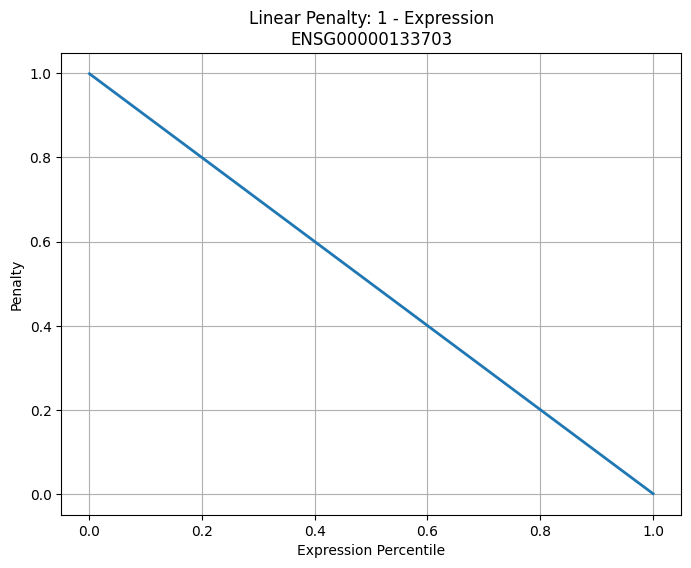

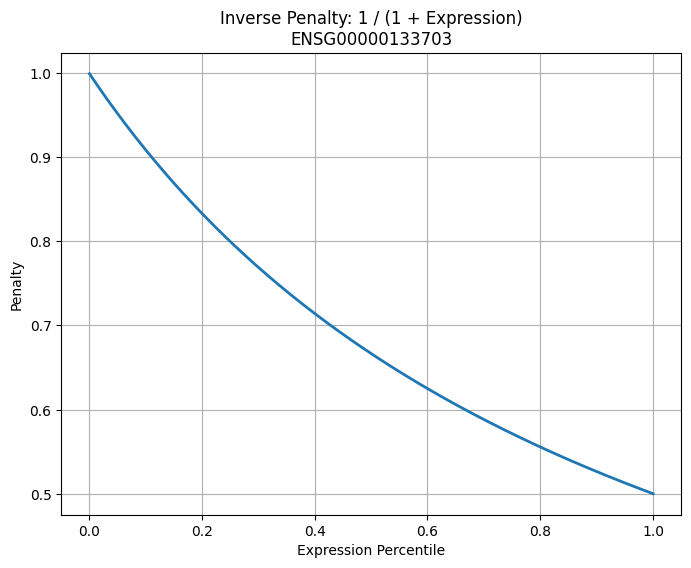

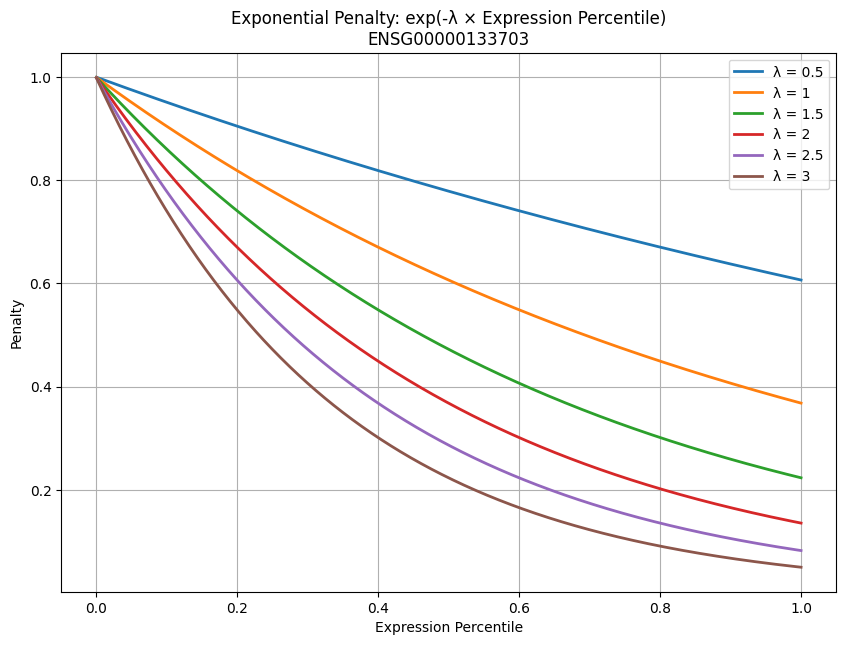

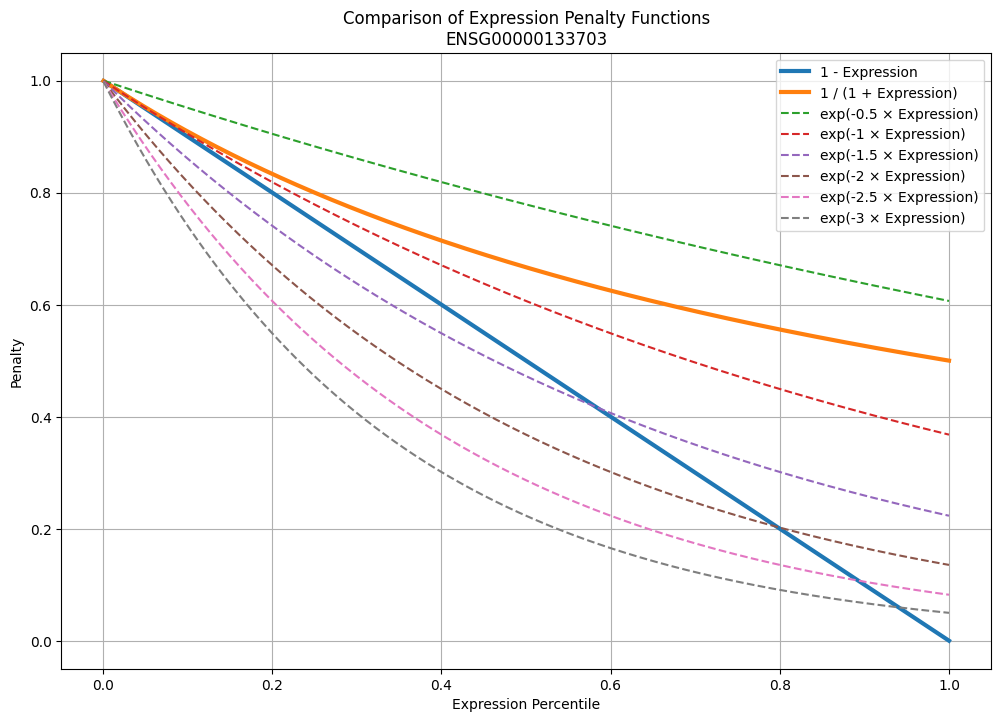

In [200]:
gene_col = "ENSG00000133703"
depmap_omicsexpressionallgenes_minmaxed = depmap_omicsexpressionallgenes_cleaned_df.copy()
depmap_omicsexpressionallgenes_minmaxed = depmap_omicsexpressionallgenes_minmaxed.set_index(depmap_omicsexpressionallgenes_minmaxed.columns[0])
minMax = MinMaxScaler()
depmap_omicsexpressionallgenes_minmaxed.iloc[:, :] = minMax.fit_transform(depmap_omicsexpressionallgenes_minmaxed)
depmap_omicsexpressionallgenes_minmaxed = depmap_omicsexpressionallgenes_minmaxed.reset_index()
result = compare_expression_penalties(depmap_omicsexpressionallgenes_minmaxed,gene_col,lambdas=(0.5, 1, 1.5, 2, 2.5, 3))

In [201]:
def plot_raw_expression_slope(df, gene_col):
    expression = (
        df[gene_col]
        .dropna()
        .astype(float)
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        np.arange(1, len(expression) + 1),
        expression.values,
        linewidth=2
    )

    plt.xlabel("Cell Lines")
    plt.ylabel("Raw Expression Value")
    plt.title(f"Descending Expression Profile: {gene_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return expression

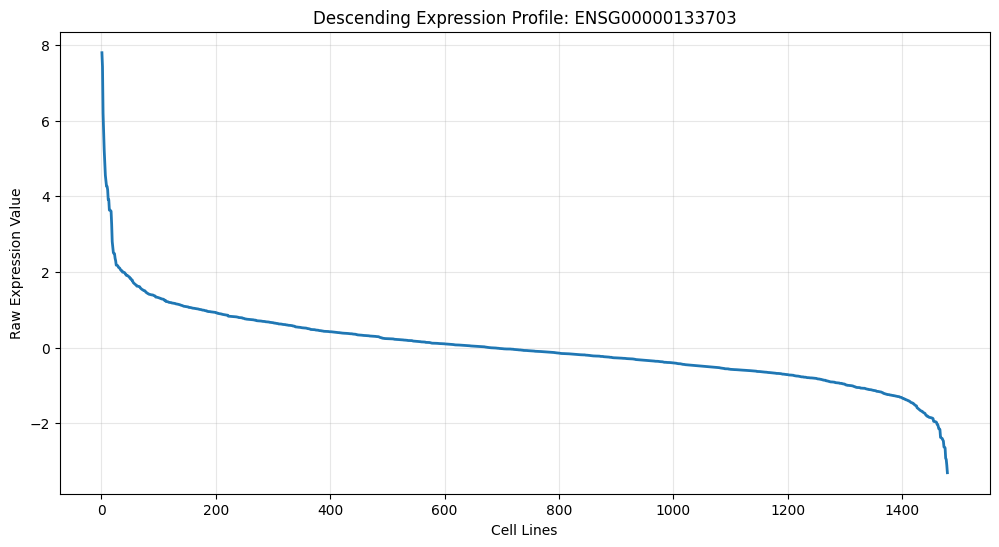

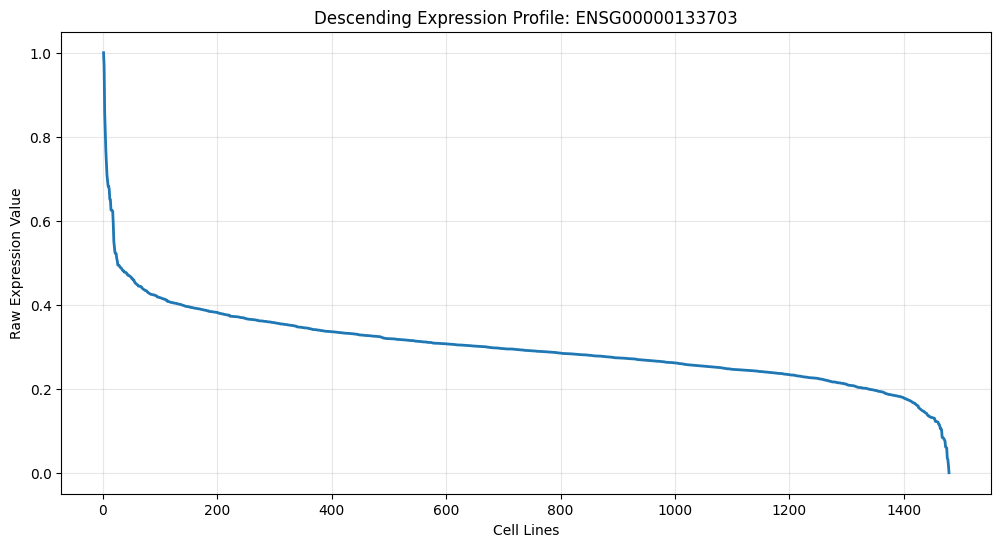

In [202]:
gene_col = "ENSG00000133703"
result = plot_raw_expression_slope(depmap_omicsexpressionallgenes_cleaned_df,gene_col)
result2 = plot_raw_expression_slope(depmap_omicsexpressionallgenes_minmaxed,gene_col)

In [203]:
def compare_mean_expression_with_penalties(
    df,
    id_col="ModelID",
    lambdas=(0.5, 1, 1.5, 2, 2.5, 3)
):
    gene_df = (
        df
        .drop(columns=[id_col], errors="ignore")
        .apply(pd.to_numeric, errors="coerce")
    )

    print("Cell lines:", gene_df.shape[0])
    print("Genes:", gene_df.shape[1])

    sorted_values = np.sort(
        gene_df.to_numpy(),
        axis=0
    )[::-1, :]

    mean_expression = np.nanmean(
        sorted_values,
        axis=1
    )

    median_expression = np.nanmedian(
        sorted_values,
        axis=1
    )

    rank_position = np.linspace(
        0,
        1,
        len(mean_expression)
    )

    difference = np.abs(
        mean_expression - median_expression
    )

    print("Maximum difference:", difference.max())
    print("Mean difference:", difference.mean())
    print("Median difference:", np.median(difference))
    
    plt.figure(figsize=(14, 8))

    plt.plot(
        rank_position,
        mean_expression,
        linewidth=4,
        label="Mean MinMax Expression"
    )

    plt.plot(
        rank_position,
        median_expression,
        linewidth=3,
        linestyle=":",
        label="Median MinMax Expression"
    )

    plt.xlabel(
        "Normalized Rank Position "
        "(Highest Expression → Lowest Expression)"
    )

    plt.ylabel(
        "MinMax Expression"
    )

    plt.title(
        "Average MinMax Expression Profile Across All Genes"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    expression_percentile = np.linspace(
        0,
        1,
        len(mean_expression)
    )
    penalty_linear = (
        1 - expression_percentile
    )

    penalty_inverse = (
        1 / (1 + expression_percentile)
    )

    exponential_penalties = {
        lam: np.exp(
            -lam * expression_percentile
        )
        for lam in lambdas
    }
    plt.figure(figsize=(14, 8))

    plt.plot(
        rank_position,
        penalty_linear,
        linewidth=3,
        label="1 - Percentile"
    )

    plt.plot(
        rank_position,
        penalty_inverse,
        linewidth=3,
        label="1 / (1 + Percentile)"
    )

    for lam, penalty in exponential_penalties.items():

        plt.plot(
            rank_position,
            penalty,
            linestyle="--",
            linewidth=2,
            label=f"exp(-{lam} × Percentile)"
        )

    plt.xlabel(
        "Penalty Rank Position "
        "(Highest Multiplier → Lowest Multiplier)"
    )

    plt.ylabel(
        "Penalty Multiplier"
    )

    plt.title(
        "Candidate Penalty Multipliers "
        "(Highest → Lowest)"
    )

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    results = pd.DataFrame({
        "RankPosition":
            rank_position,

        "ExpressionPercentile":
            expression_percentile,

        "MeanExpression":
            mean_expression,

        "MedianExpression":
            median_expression,

        "Penalty_Linear":
            penalty_linear,

        "Penalty_Inverse":
            penalty_inverse
    })

    for lam, penalty in exponential_penalties.items():

        results[
            f"Penalty_Exp_Lambda_{lam}"
        ] = penalty

    return results

Cell lines: 1479
Genes: 19916
Maximum difference: 0.12020830307083191
Mean difference: 0.06806643407133722
Median difference: 0.07385940481485476


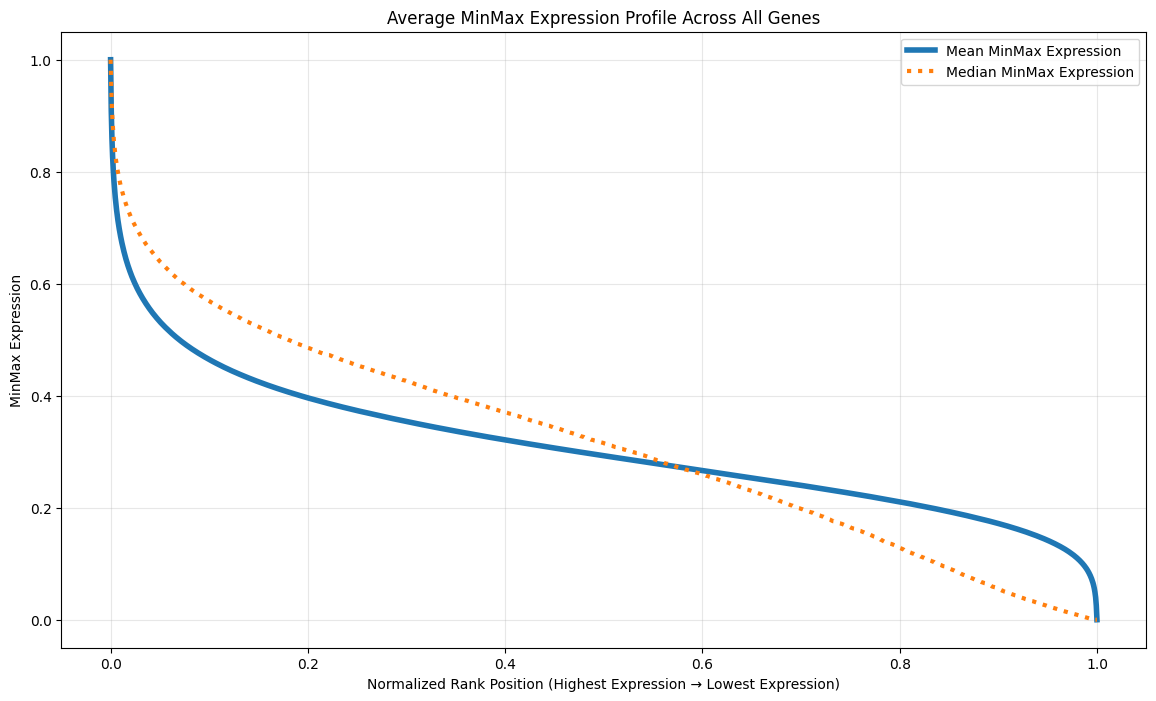

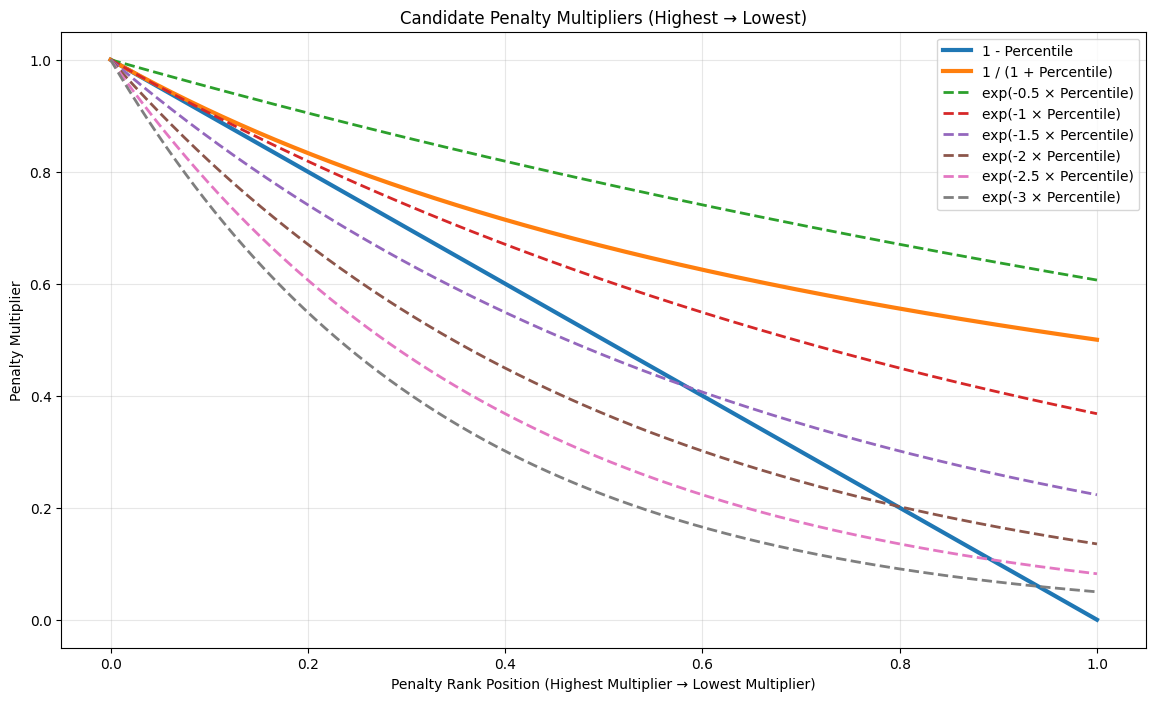

In [204]:
penalty_comparison_df = compare_mean_expression_with_penalties(depmap_omicsexpressionallgenes_minmaxed,id_col="ModelID")

## PCA

In [205]:
X = merged_df.drop(columns=["ModelID"])
pca = PCA(n_components=0.95,random_state=42)
X_pca = pca.fit_transform(X)
pca_columns = [f"PC{i+1}"for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca,columns=pca_columns)
pca_df.insert(
    0,
    "ModelID",
    merged_df["ModelID"].values
)

print("Original Shape :", X.shape)
print("PCA Shape      :", X_pca.shape)
print(
    "Variance Explained:",
    pca.explained_variance_ratio_.sum()
)

print(pca_df.head())

Original Shape : (1479, 27586)
PCA Shape      : (1479, 1004)
Variance Explained: 0.9500417277979138
      ModelID        PC1        PC2        PC3        PC4        PC5  \
0  ACH-001113  25.737805  15.253976   1.473828 -13.393797  28.047085   
1  ACH-001289  38.669914   7.862280 -38.437415 -44.321626  31.283479   
2  ACH-001339 -17.879452  27.421368 -49.930234  -2.541122  32.625168   
3  ACH-001538 -35.526150  16.064035  11.995085   3.055425  46.492291   
4  ACH-000242  -0.269269  -1.248868  43.623682   5.964446  18.041716   

         PC6        PC7        PC8        PC9  ...     PC995     PC996  \
0 -22.833175  -7.615898  16.377410 -25.945496  ...  1.325580 -1.090572   
1  -6.919153   5.442597  -2.956763   8.092285  ... -0.367867 -0.010683   
2   5.531249  39.934892  34.048103 -21.655043  ... -1.968927 -0.501170   
3 -28.950670  -8.016654   9.454056 -10.989287  ... -0.268331 -2.156264   
4   2.742415  -1.571755  -3.611749  -5.113487  ...  0.563424  1.609547   

      PC997     PC998 

In [206]:
X = merged_df.drop(columns=["ModelID"])
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
pca_2d_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)
pca_2d_df["ModelID"] = merged_df["ModelID"].values
print(
    pca.explained_variance_ratio_
) 
print(
    pca.explained_variance_ratio_.sum()
)

[0.09491957 0.06117263]
0.156092199468542


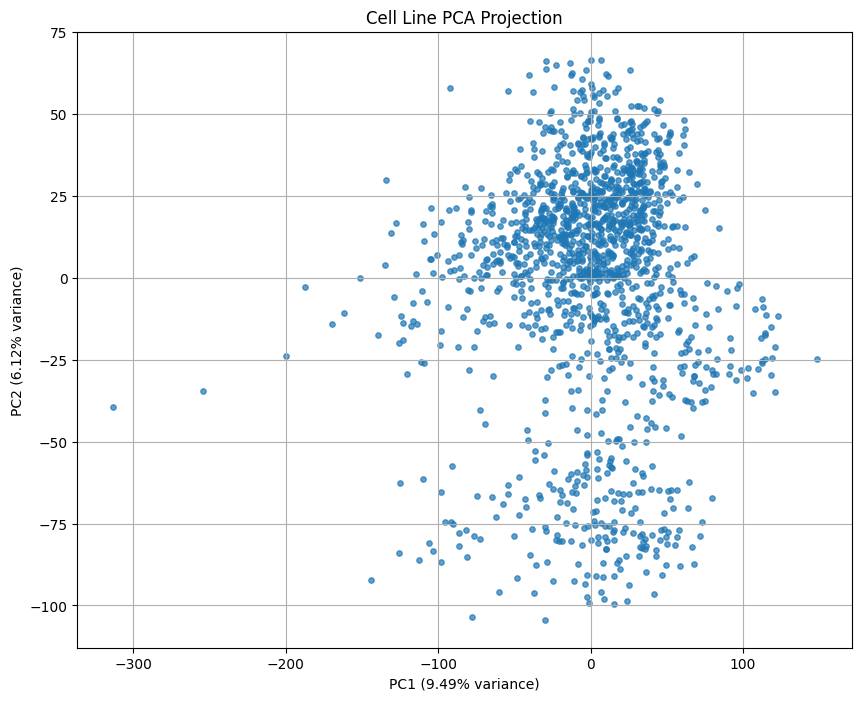

In [207]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    s=15,
    alpha=0.7
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)"
)

plt.title(
    "Cell Line PCA Projection"
)

plt.grid(True)

plt.show()

## Truncated SVD

In [208]:
X = merged_df.drop(columns=["ModelID"])
svd = TruncatedSVD(
    n_components=500,
    random_state=42
)
X_svd = svd.fit_transform(X)
svd_columns = [
    f"SVD{i+1}"
    for i in range(X_svd.shape[1])
]
svd_df = pd.DataFrame(
    X_svd,
    columns=svd_columns
)
svd_df.insert(
    0,
    "ModelID",
    merged_df["ModelID"].values
)

print("Original Shape :", X.shape)
print("SVD Shape      :", X_svd.shape)

print(
    "Explained Variance:",
    svd.explained_variance_ratio_.sum()
)

print(svd_df.head())

Original Shape : (1479, 27586)
SVD Shape      : (1479, 500)
Explained Variance: 0.8280537823712205
      ModelID       SVD1       SVD2       SVD3       SVD4       SVD5  \
0  ACH-001113  25.709821  15.219670   1.591891 -13.505444  28.065242   
1  ACH-001289  38.641956   7.828159 -38.317778 -44.435259  31.301379   
2  ACH-001339 -17.907310  27.387609 -49.812627  -2.654875  32.643397   
3  ACH-001538 -35.554101  16.029862  12.111757   2.945045  46.510355   
4  ACH-000242  -0.298213  -1.285105  43.748806   5.844203  18.062233   

        SVD6       SVD7       SVD8       SVD9  ...    SVD491    SVD492  \
0 -22.837771  -7.787428  16.375796 -25.980714  ...  3.827924 -3.620034   
1  -6.923678   5.268999  -2.958390   8.054268  ...  1.315452 -1.853223   
2   5.526857  39.761091  34.046525 -21.686059  ... -0.149960 -0.779522   
3 -28.955159  -8.178807   9.452743 -11.016040  ... -1.784193  0.363952   
4   2.737065  -1.783690  -3.613819  -5.160070  ... -6.114260 -2.021867   

     SVD493    SVD494  

In [209]:
cumulative_variance = np.cumsum(
    svd.explained_variance_ratio_
)

print(
    cumulative_variance[-1]
)

0.8280537823712198


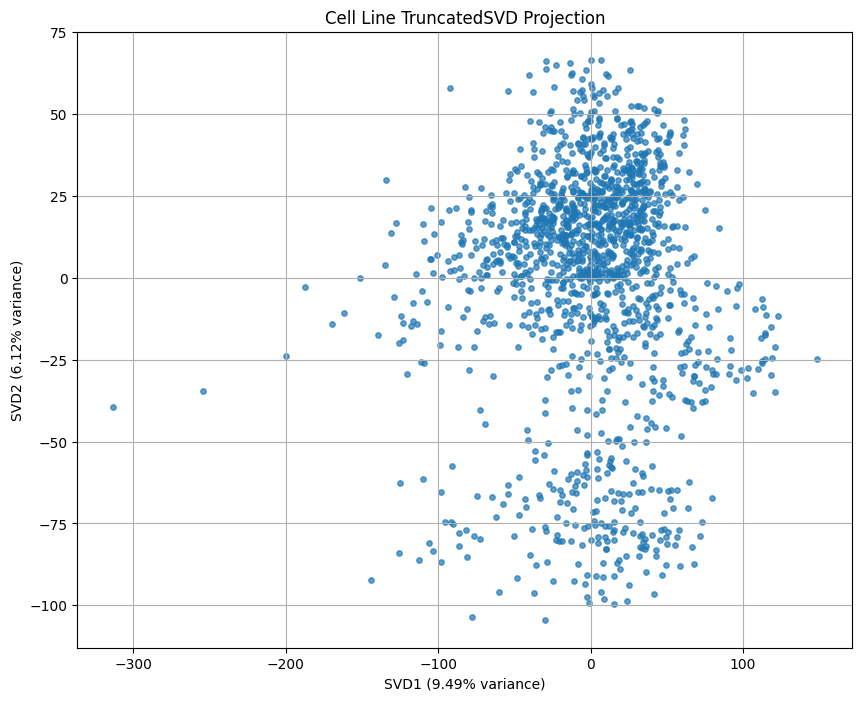

In [210]:
svd_vis = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_svd_2d = svd_vis.fit_transform(X)

svd_2d_df = pd.DataFrame(
    X_svd_2d,
    columns=["SVD1", "SVD2"]
)

svd_2d_df["ModelID"] = merged_df["ModelID"].values

plt.figure(figsize=(10,8))

plt.scatter(
    svd_2d_df["SVD1"],
    svd_2d_df["SVD2"],
    s=15,
    alpha=0.7
)

plt.xlabel(
    f"SVD1 ({svd_vis.explained_variance_ratio_[0]*100:.2f}% variance)"
)

plt.ylabel(
    f"SVD2 ({svd_vis.explained_variance_ratio_[1]*100:.2f}% variance)"
)

plt.title(
    "Cell Line TruncatedSVD Projection"
)

plt.grid(True)

plt.show()

## MOFA

In [211]:
depmap_omicsexpressionallgenes_cleaned_df = depmap_omicsexpressionallgenes_cleaned_df.sort_values(by="ModelID",key=lambda x: x.str.replace("ACH-", "", regex=False).astype(int)).reset_index(drop=True)
master_ids = depmap_omicsexpressionallgenes_cleaned_df["ModelID"]
print(depmap_omicsexpressionallgenes_cleaned_df.head(5))

      ModelID  ENSG00000000003  ENSG00000000005  ENSG00000000419  \
0  ACH-000001         1.097710        -0.205938         1.516895   
1  ACH-000002        -1.971517        -0.205938        -1.267380   
2  ACH-000003         1.175244         0.018867         2.057317   
3  ACH-000004        -0.745583        -0.205938        -1.651328   
4  ACH-000005        -0.576883        -0.205938        -0.984009   

   ENSG00000000457  ENSG00000000460  ENSG00000000938  ENSG00000000971  \
0        -0.477565         0.680725        -0.315912        -0.572589   
1        -2.078930        -0.703042         3.013390        -0.899612   
2        -0.904966         0.273742        -0.350549        -0.946889   
3         0.209087         0.307664         0.370328         1.220877   
4         1.034062         2.044685        -0.186776         1.574774   

   ENSG00000001036  ENSG00000001084  ...  ENSG00000288699  ENSG00000288701  \
0         0.308742         0.035317  ...         0.338178         1.091596

In [212]:
protein_df = (harmonized_ms_celline_cleaned_df.set_index("ModelID").reindex(master_ids).reset_index())
metabolomics_df = (CCLE_metabolomics_cleaned_20190502_df.set_index("ModelID").reindex(master_ids).reset_index())
globalsig_df = (OmicsGlobalSignatures_cleaned_df.set_index("ModelID").reindex(master_ids).reset_index())

In [213]:
globalsig_df = globalsig_df.drop(columns=['ModelConditionID', 'SequencingID', 'IsDefaultEntryForModel', 'IsDefaultEntryForMC'])
metabolomics_df = metabolomics_df.drop(columns=['CCLE_ID'])

In [214]:
print(depmap_omicsexpressionallgenes_cleaned_df.shape)
print(protein_df.shape)
print(metabolomics_df.shape)
print(globalsig_df.shape)

(1479, 19917)
(1479, 12559)
(1479, 226)
(1479, 7)


In [215]:
rna_long = depmap_omicsexpressionallgenes_cleaned_df.melt(
    id_vars="ModelID",
    var_name="feature",
    value_name="value"
)

rna_long["view"] = "RNA"
rna_long["group"] = "CellLines"

protein_long = protein_df.melt(
    id_vars="ModelID",
    var_name="feature",
    value_name="value"
)

protein_long["view"] = "Proteomics"
protein_long["group"] = "CellLines"

metabolomics_long = metabolomics_df.melt(
    id_vars="ModelID",
    var_name="feature",
    value_name="value"
)

metabolomics_long["view"] = "Metabolomics"
metabolomics_long["group"] = "CellLines"

globalsig_long = globalsig_df.melt(
    id_vars="ModelID",
    var_name="feature",
    value_name="value"
)

globalsig_long["view"] = "GlobalSignatures"
globalsig_long["group"] = "CellLines"

data_long = pd.concat(
    [
        rna_long,
        protein_long,
        metabolomics_long,
        globalsig_long
    ],
    ignore_index=True
)

data_long = data_long.rename(
    columns={
        "ModelID": "sample"
    }
)

In [216]:
ent = entry_point()
ent.set_data_options(
    scale_views=False,
    scale_groups=False,
    center_groups=True,
    use_float32=True
)
ent.set_data_df(data_long)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


use_float32 set to True: replacing float64 arrays by float32 arrays to speed up computations...



Loaded group='CellLines' view='GlobalSignatures' with N=1479 samples and D=6 features...
Loaded group='CellLines' view='Metabolomics' with N=1479 samples and D=225 features...
Loaded group='CellLines' view='Proteomics' with N=1479 samples and D=12558 features...
Loaded group='CellLines' v

In [217]:
ent.set_model_options(
    factors=20,
    spikeslab_factors=False,
    spikeslab_weights=True,
    ard_factors=True,
    ard_weights=True
)

ent.set_train_options(
    iter=1000,
    convergence_mode="fast",
    seed=42
)
ent.build()
ent.run()

Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (GlobalSignatures): gaussian
- View 1 (Metabolomics): gaussian
- View 2 (Proteomics): gaussian
- View 3 (RNA): gaussian






######################################
## Training the model with seed 42 ##
######################################


ELBO before training: -427062476.83 

Iteration 1: time=15.87, ELBO=-42835314.96, deltaELBO=384227161.870 (89.96977789%), Factors=20
Iteration 2: time=14.96, ELBO=-39152276.40, deltaELBO=3683038.561 (0.86241212%), Factors=20
Iteration 3: time=14.10, ELBO=-38835219.56, deltaELBO=317056.836 (0.07424132%), Factors=20
Iteration 4: time=13.55, ELBO=-38668290.13, deltaELBO=166929.433 (0.03908782%), Factors=20
Iteration 5: time=13.63, ELBO=-38535688.49, deltaELBO=132601.638 (0.03104970%), Factors=20
Iterat

In [218]:
factors = ent.model.nodes["Z"].getExpectation()

print("Factors shape:", factors.shape)

if factors.shape[0] == len(master_ids):

    factor_df = pd.DataFrame(
        factors,
        columns=[
            f"Factor{i+1}"
            for i in range(factors.shape[1])
        ]
    )

else:

    factor_df = pd.DataFrame(
        factors.T,
        columns=[
            f"Factor{i+1}"
            for i in range(factors.shape[0])
        ]
    )

factor_df.insert(
    0,
    "ModelID",
    master_ids.values
)

print(factor_df.shape)
print(factor_df.head())

Factors shape: (1479, 20)
(1479, 21)
      ModelID   Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
0  ACH-000001  3.254857  1.094717  2.590412 -2.309249  0.354017 -0.827697   
1  ACH-000002 -8.913815 -6.591320 -1.456575  2.323557 -2.622683  5.152744   
2  ACH-000003 -1.974996  0.382741  3.195194 -0.195651  1.694738  3.794047   
3  ACH-000004  3.533759 -5.255245 -1.221656  2.728721 -0.539121 -0.111255   
4  ACH-000005  6.502093 -4.759291 -1.751314  2.923748  5.435082 -0.826647   

    Factor7   Factor8   Factor9  ...  Factor11  Factor12  Factor13  Factor14  \
0 -1.840472  0.290216 -1.815119  ...  1.463745 -2.396510  1.080129  1.146823   
1  0.014880 -2.059438 -1.662718  ... -2.295511  7.505150 -1.693451 -1.186863   
2  1.582860 -2.903916 -0.307365  ... -0.095387 -1.490502  1.307250  1.409092   
3  0.765097 -3.441640 -5.083339  ... -1.348928  5.437452 -2.307235  2.471508   
4  0.502088 -2.959733 -4.777240  ... -1.647142  5.657424 -2.303980  1.749524   

   Factor15  Factor

In [219]:
factor_variance = factors.var(axis=0)

variance_ratio = factor_variance / factor_variance.sum()

print(variance_ratio)

variance_percent = variance_ratio * 100
cumulative = variance_percent.cumsum()

print(cumulative)

[0.24364407 0.06624609 0.05769752 0.07631486 0.09798488 0.08523387
 0.05468845 0.03759396 0.03775998 0.03190643 0.0266943  0.03959259
 0.02688224 0.01849532 0.02561996 0.01899578 0.01200651 0.01525755
 0.0113473  0.01603824]
[24.364407 30.989016 36.758766 44.39025  54.18874  62.712128 68.18097
 71.94037  75.71637  78.90701  81.57645  85.535706 88.22393  90.07346
 92.63546  94.535034 95.73569  97.261444 98.39617  99.99999 ]


In [220]:
r2 = ent.model.calculate_variance_explained()

print(type(r2))
print(len(r2))
print(r2)

<class 'list'>
1
[array([[0.0034101 , 0.06375927, 0.05963373, 0.00804031, 0.00802797,
        0.01112843, 0.0042209 , 0.04963022, 0.00582135, 0.00028074,
        0.00646782, 0.00747168, 0.00093633, 0.01112562, 0.00042272,
        0.00390571, 0.00895214, 0.00105572, 0.0256806 , 0.00428158],
       [0.00218457, 0.10374302, 0.01330984, 0.00659305, 0.00291955,
        0.00968122, 0.00714231, 0.00541961, 0.00731021, 0.00440162,
        0.00726348, 0.00839651, 0.00049824, 0.0029307 , 0.00286138,
        0.00365043, 0.00327122, 0.00303221, 0.00270963, 0.00216228],
       [0.01041275, 0.08372742, 0.04683495, 0.02227706, 0.0063954 ,
        0.00284582, 0.02417153, 0.0148837 , 0.0145995 , 0.01346165,
        0.00954294, 0.03223252, 0.05520111, 0.016092  , 0.01268727,
        0.00928986, 0.01306856, 0.00822026, 0.00480807, 0.01405704],
       [0.09889436, 0.06318104, 0.04411501, 0.03412396, 0.02587503,
        0.02038121, 0.0153721 , 0.01192296, 0.01128799, 0.01104164,
        0.01014924, 0.00847

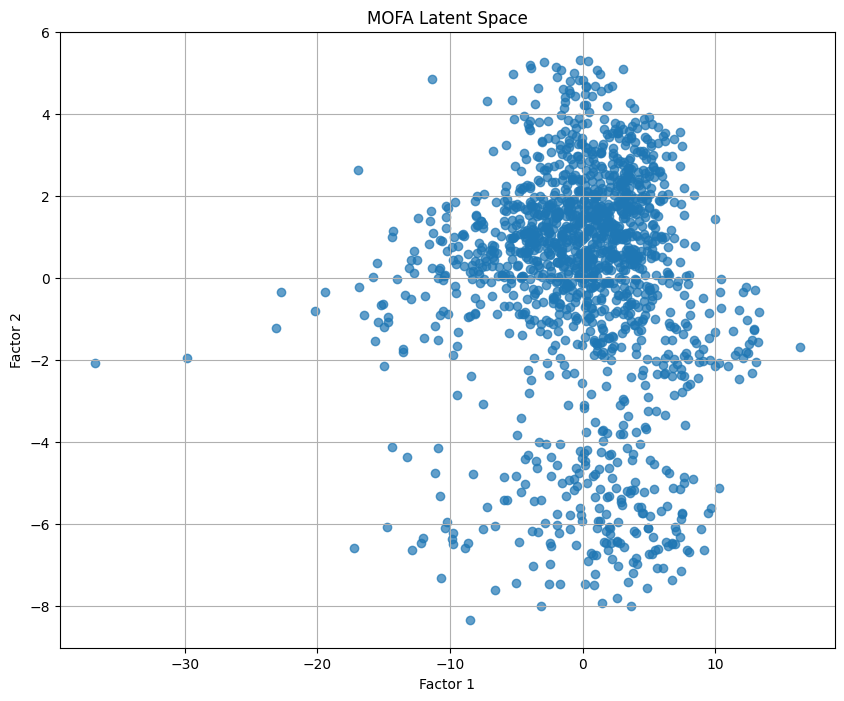

In [221]:
plt.figure(figsize=(10,8))

plt.scatter(
    factor_df["Factor1"],
    factor_df["Factor2"],
    alpha=0.7
)

plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("MOFA Latent Space")

plt.grid(True)

plt.show()

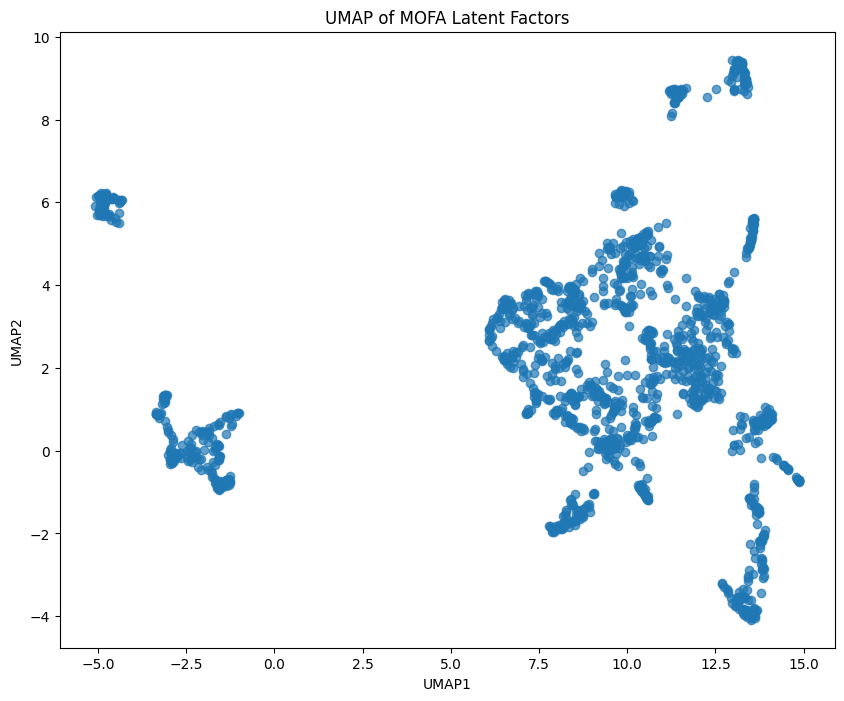

In [222]:
embedding = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
).fit_transform(
    factor_df.drop(columns=["ModelID"])
)

umap_df = pd.DataFrame(
    embedding,
    columns=["UMAP1", "UMAP2"]
)

umap_df["ModelID"] = factor_df["ModelID"]

plt.figure(figsize=(10,8))

plt.scatter(
    umap_df["UMAP1"],
    umap_df["UMAP2"],
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.title("UMAP of MOFA Latent Factors")

plt.show()

# Modelling

## Kmeans

In [223]:
embedding_dict = {
    "PCA": pca_df.drop(columns=["ModelID"]).values,
    "SVD": svd_df.drop(columns=["ModelID"]).values,
    "MOFA": factor_df.drop(columns=["ModelID"]).values
}

In [224]:
kmeans_results = []

for method, X in embedding_dict.items():

   for k in range(2, 200):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42
        )

        labels = kmeans.fit_predict(X)

        kmeans_results.append({
            "Method": method,
            "K": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(X, labels),
        })

kmeans_results_df = pd.DataFrame(kmeans_results)
print(kmeans_results_df)

  File "c:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\CelllineSelector\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\CelllineSelector\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\python3119\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\python3119\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\python3119\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

    Method    K       Inertia  Silhouette
0      PCA    2  2.826427e+07    0.050516
1      PCA    3  2.701120e+07    0.061305
2      PCA    4  2.637735e+07    0.050119
3      PCA    5  2.513145e+07    0.056674
4      PCA    6  2.498485e+07    0.056846
..     ...  ...           ...         ...
589   MOFA  195  2.929787e+04    0.118300
590   MOFA  196  2.924294e+04    0.118343
591   MOFA  197  2.912704e+04    0.119038
592   MOFA  198  2.905742e+04    0.119038
593   MOFA  199  2.898393e+04    0.119024

[594 rows x 4 columns]


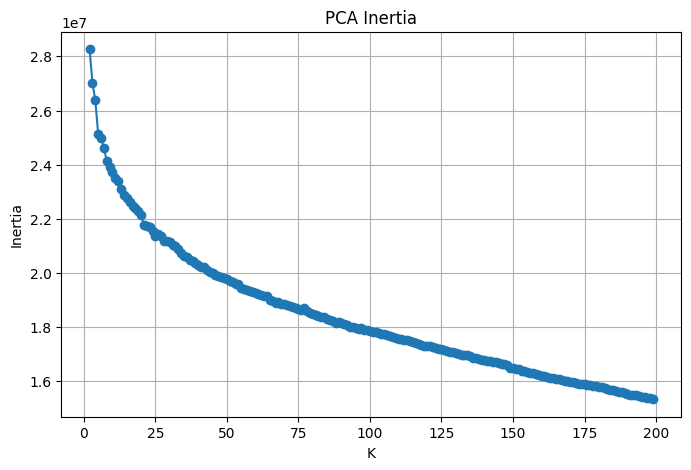

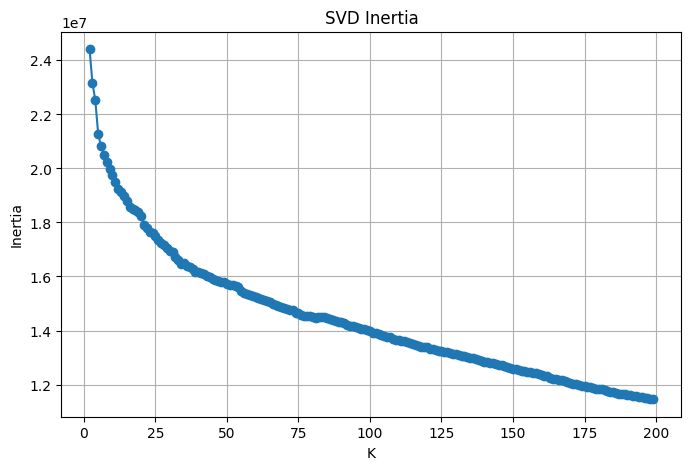

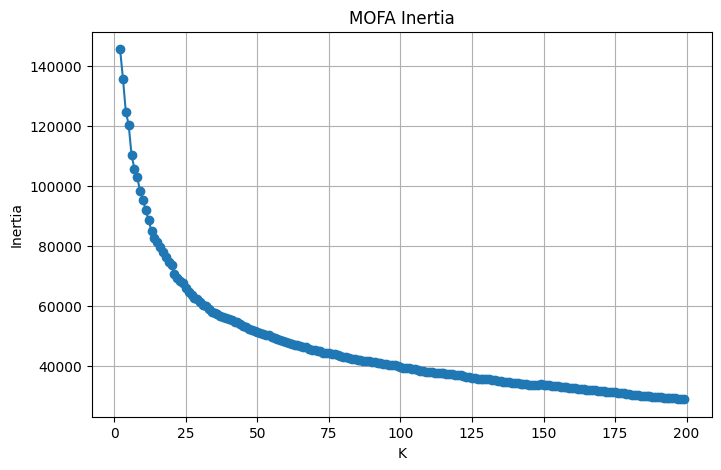

In [225]:
for method in kmeans_results_df["Method"].unique():

    subset = kmeans_results_df[
        kmeans_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["K"],
        subset["Inertia"],
        marker="o"
    )

    plt.title(f"{method} Inertia")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

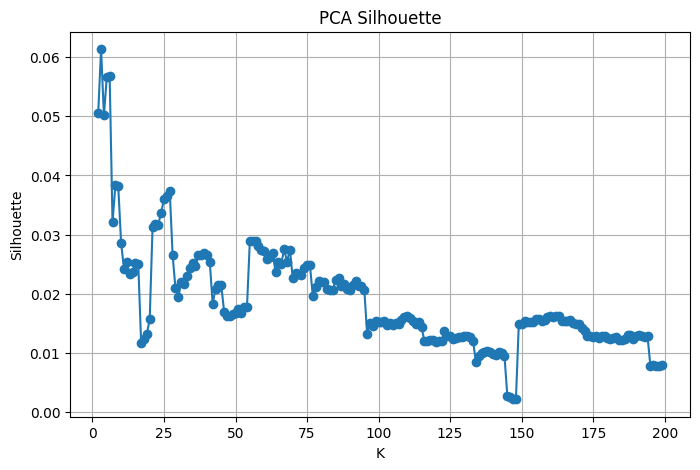

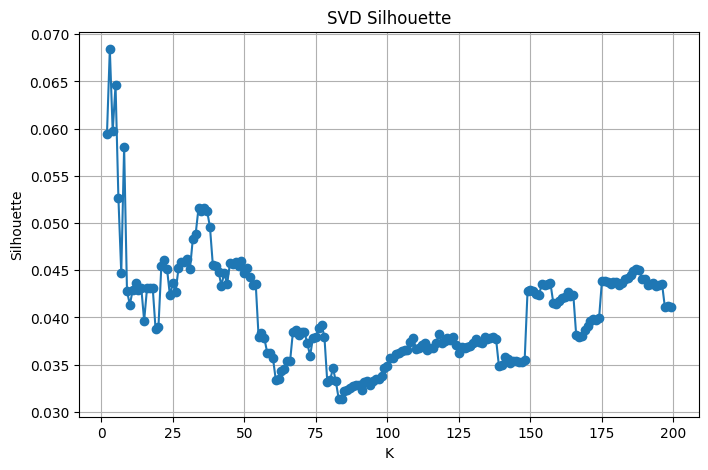

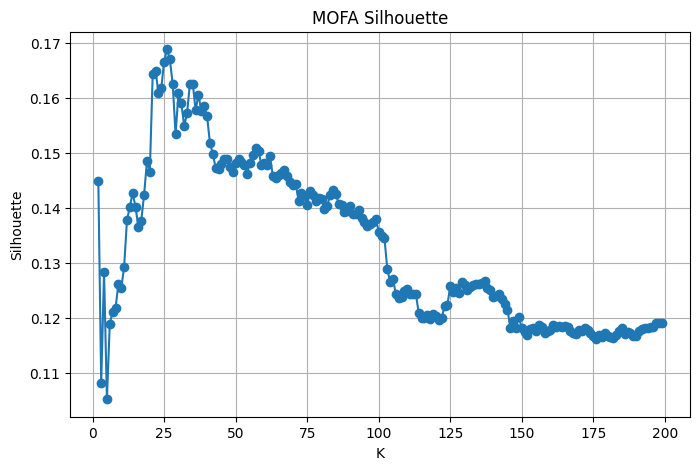

In [226]:
for method in kmeans_results_df["Method"].unique():

    subset = kmeans_results_df[
        kmeans_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["K"],
        subset["Silhouette"],
        marker="o"
    )

    plt.title(f"{method} Silhouette")
    plt.xlabel("K")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.show()

In [227]:
kmeans_results = []

for method, X in embedding_dict.items():

   for k in range(2, 50):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42
        )

        labels = kmeans.fit_predict(X)

        kmeans_results.append({
            "Method": method,
            "K": k,
            "Inertia": kmeans.inertia_,
            "Silhouette": silhouette_score(X, labels),
        })

kmeans_results_df = pd.DataFrame(kmeans_results)
print(kmeans_results_df)

    Method   K       Inertia  Silhouette
0      PCA   2  2.826427e+07    0.050516
1      PCA   3  2.701120e+07    0.061305
2      PCA   4  2.637735e+07    0.050119
3      PCA   5  2.513145e+07    0.056674
4      PCA   6  2.498485e+07    0.056846
..     ...  ..           ...         ...
139   MOFA  45  5.333596e+04    0.148040
140   MOFA  46  5.298518e+04    0.148850
141   MOFA  47  5.248701e+04    0.148848
142   MOFA  48  5.209332e+04    0.147550
143   MOFA  49  5.185399e+04    0.146662

[144 rows x 4 columns]


In [228]:
subset = kmeans_results_df[kmeans_results_df['Method'] == 'MOFA']
print(subset.sort_values(by="Silhouette", ascending=False).head(1))

    Method   K       Inertia  Silhouette
120   MOFA  26  64790.863281    0.168926


In [229]:
print(subset)

    Method   K        Inertia  Silhouette
96    MOFA   2  145531.343750    0.144886
97    MOFA   3  135741.968750    0.108100
98    MOFA   4  124726.328125    0.128318
99    MOFA   5  120424.796875    0.105201
100   MOFA   6  110288.414062    0.118943
101   MOFA   7  105778.664062    0.121148
102   MOFA   8  102871.742188    0.121758
103   MOFA   9   98265.625000    0.126114
104   MOFA  10   95303.234375    0.125391
105   MOFA  11   91897.992188    0.129203
106   MOFA  12   88498.101562    0.137747
107   MOFA  13   84963.859375    0.140266
108   MOFA  14   82698.023438    0.142747
109   MOFA  15   81488.632812    0.140177
110   MOFA  16   79576.843750    0.136539
111   MOFA  17   77910.039062    0.137730
112   MOFA  18   76482.421875    0.142439
113   MOFA  19   74787.562500    0.148592
114   MOFA  20   73516.398438    0.146611
115   MOFA  21   70797.632812    0.164349
116   MOFA  22   69266.289062    0.165000
117   MOFA  23   68511.187500    0.160944
118   MOFA  24   67731.203125    0

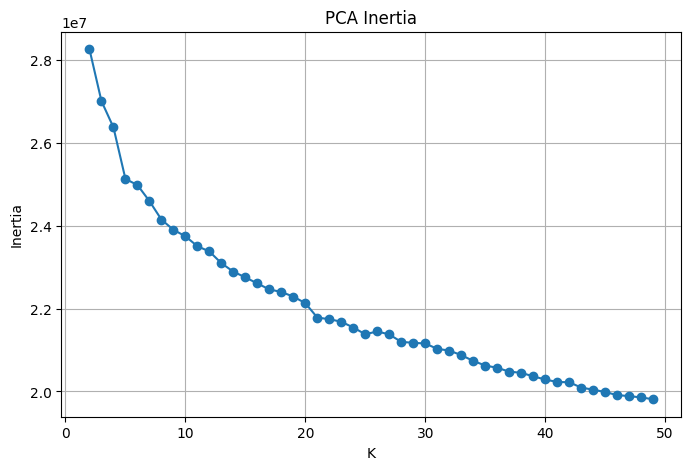

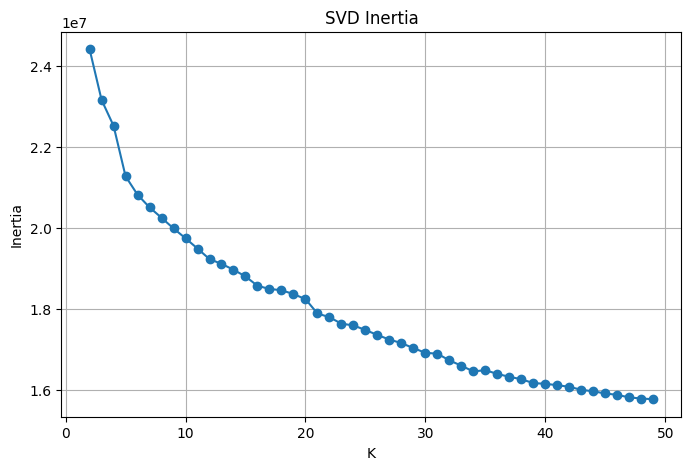

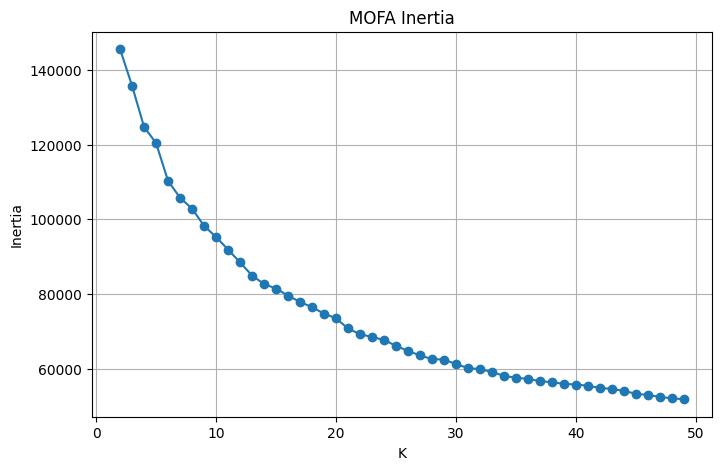

In [230]:
for method in kmeans_results_df["Method"].unique():

    subset = kmeans_results_df[
        kmeans_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["K"],
        subset["Inertia"],
        marker="o"
    )

    plt.title(f"{method} Inertia")
    plt.xlabel("K")
    plt.ylabel("Inertia")
    plt.grid(True)
    plt.show()

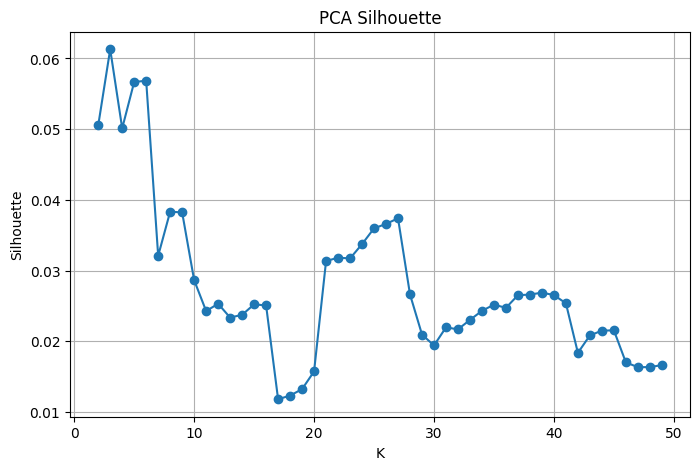

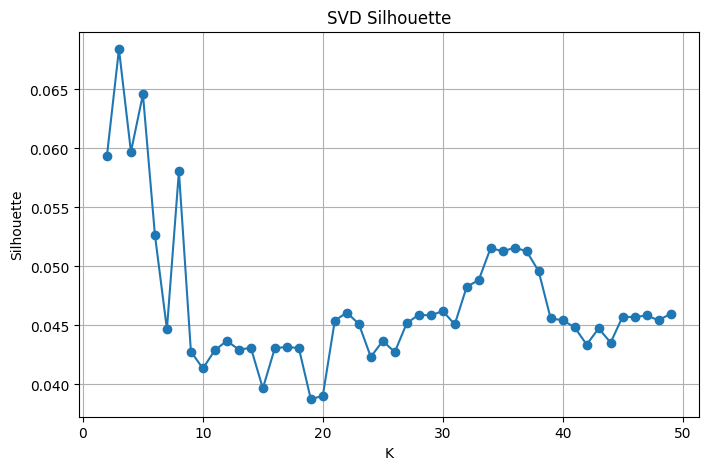

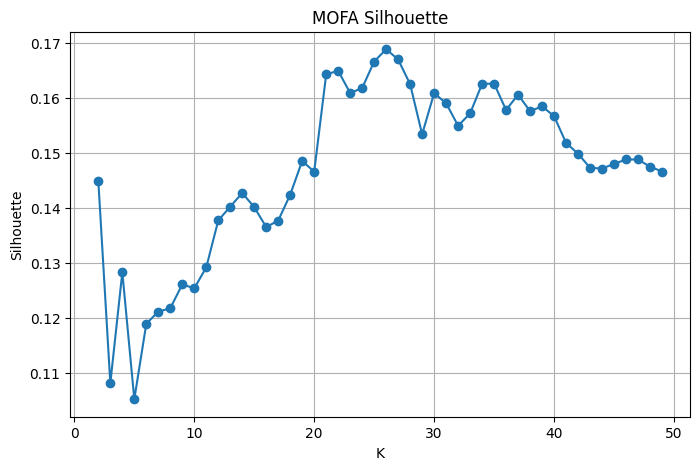

In [231]:
for method in kmeans_results_df["Method"].unique():

    subset = kmeans_results_df[
        kmeans_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["K"],
        subset["Silhouette"],
        marker="o"
    )

    plt.title(f"{method} Silhouette")
    plt.xlabel("K")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.show()

In [232]:
kmeans = KMeans(
    n_clusters=26,
    random_state=42
)

X = embedding_dict['MOFA']

labels = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({
    "ModelID": pca_df["ModelID"],
    "Cluster": labels
})

In [233]:
cluster_groups = cluster_df.groupby("Cluster")["ModelID"].apply(list)

print(cluster_groups)

Cluster
0     [ACH-000705, ACH-000167, ACH-000765, ACH-00137...
1     [ACH-000690, ACH-000914, ACH-000787, ACH-00141...
2     [ACH-001098, ACH-000154, ACH-000421, ACH-00137...
3     [ACH-000998, ACH-000749, ACH-000429, ACH-00035...
4     [ACH-001113, ACH-002023, ACH-000606, ACH-00001...
5     [ACH-000233, ACH-000528, ACH-000751, ACH-00170...
6     [ACH-001536, ACH-000678, ACH-000176, ACH-00199...
7     [ACH-000543, ACH-001163, ACH-000538, ACH-00179...
8     [ACH-000984, ACH-000785, ACH-000554, ACH-00058...
9     [ACH-000075, ACH-000194, ACH-000135, ACH-00067...
10    [ACH-001538, ACH-000242, ACH-000708, ACH-00072...
11    [ACH-000437, ACH-000375, ACH-000547, ACH-00027...
12    [ACH-001794, ACH-002040, ACH-000800, ACH-00206...
13    [ACH-000351, ACH-000317, ACH-000117, ACH-00139...
14    [ACH-002687, ACH-000866, ACH-000715, ACH-00229...
15    [ACH-000327, ACH-000769, ACH-001119, ACH-00103...
16    [ACH-000828, ACH-000313, ACH-000138, ACH-00154...
17    [ACH-000574, ACH-000386, ACH-00062

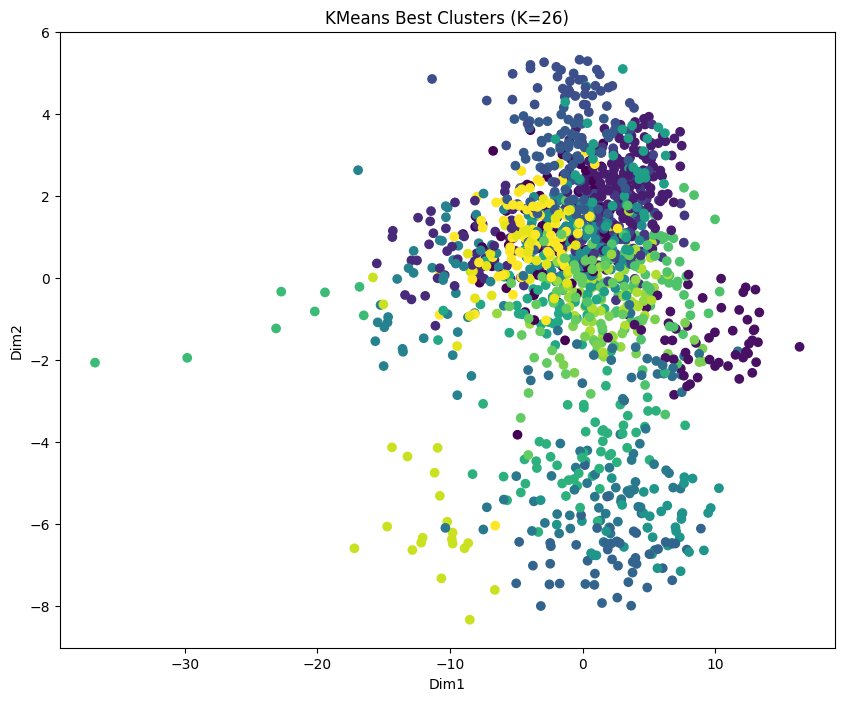

In [234]:
X = embedding_dict['MOFA']
plt.figure(figsize=(10,8))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels
)

plt.title(
    f"KMeans Best Clusters (K=26)"
)

plt.xlabel("Dim1")
plt.ylabel("Dim2")

plt.show()

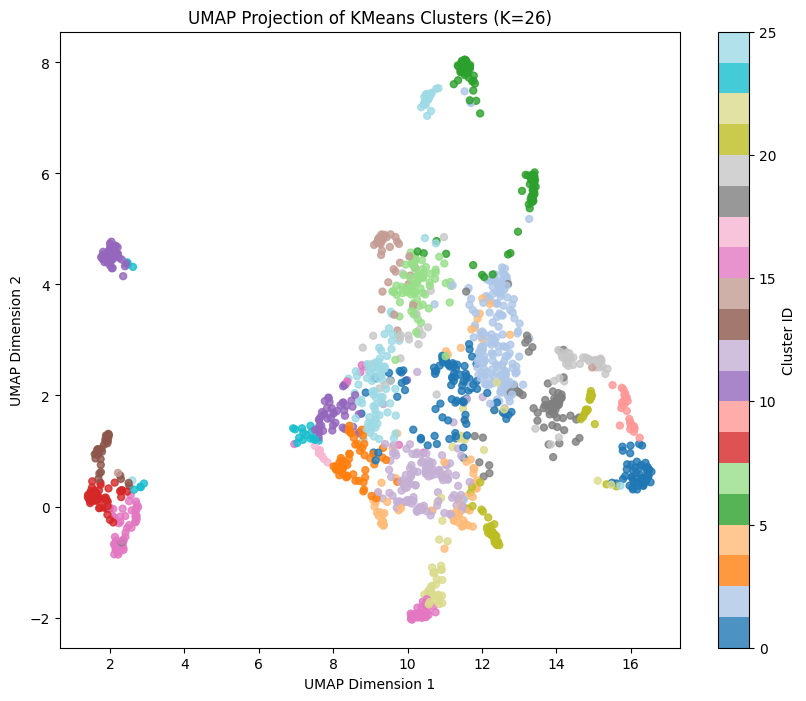

In [235]:
reducer = UMAP(n_neighbors=35, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X)

# 4. Create the beautifully separated plot
plt.figure(figsize=(10, 8))

# Scatter using the UMAP dimensions, colored by your KMeans labels
scatter = plt.scatter(
    X_umap[:, 0], 
    X_umap[:, 1], 
    c=labels, 
    cmap='tab20',  # Colormap that handles high cluster numbers well
    s=25,          # Slightly smaller dot size so they don't over-crowd
    alpha=0.8
)

plt.title(f"UMAP Projection of KMeans Clusters (K={26})")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

# Optional: Add a colorbar or legend if you want to trace cluster numbers
plt.colorbar(scatter, label="Cluster ID")

plt.show()

## KNN algorithm

In [236]:
knn_results = []

for method, X in embedding_dict.items():

    for k in range(2, 21):

        knn = NearestNeighbors(
            n_neighbors=k
        )

        knn.fit(X)

        distances, _ = knn.kneighbors(X)

        knn_results.append({
            "Method": method,
            "K": k,
            "AverageDistance": np.mean(distances)
        })

knn_results_df = pd.DataFrame(knn_results)
print(knn_results_df)

   Method   K  AverageDistance
0     PCA   2        61.908468
1     PCA   3        84.745863
2     PCA   4        96.945145
3     PCA   5       104.708980
4     PCA   6       110.175445
5     PCA   7       114.304834
6     PCA   8       117.562438
7     PCA   9       120.216206
8     PCA  10       122.432879
9     PCA  11       124.326401
10    PCA  12       125.971124
11    PCA  13       127.420873
12    PCA  14       128.714875
13    PCA  15       129.879094
14    PCA  16       130.937763
15    PCA  17       131.905358
16    PCA  18       132.795784
17    PCA  19       133.620838
18    PCA  20       134.387808
19    SVD   2        52.329674
20    SVD   3        72.199224
21    SVD   4        83.018139
22    SVD   5        90.002154
23    SVD   6        94.998116
24    SVD   7        98.819637
25    SVD   8       101.869542
26    SVD   9       104.383563
27    SVD  10       106.507806
28    SVD  11       108.335560
29    SVD  12       109.930551
30    SVD  13       111.346896
31    SV

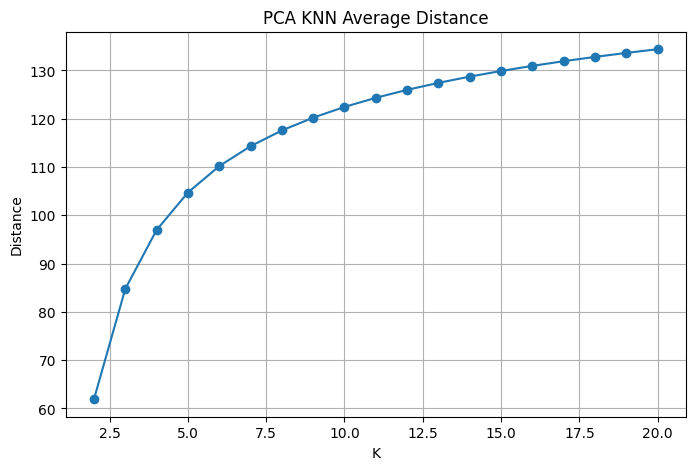

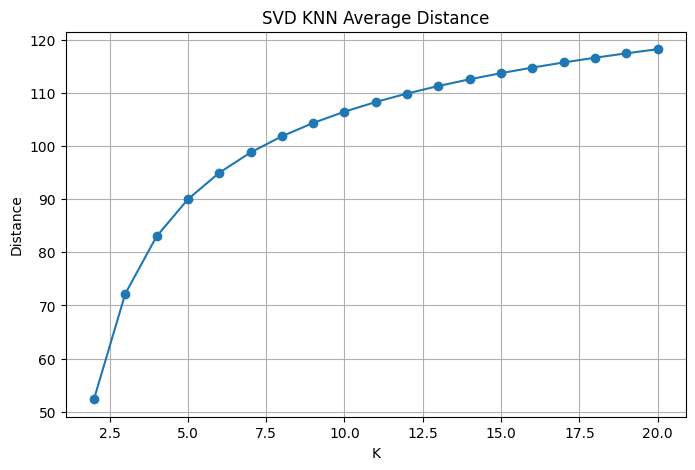

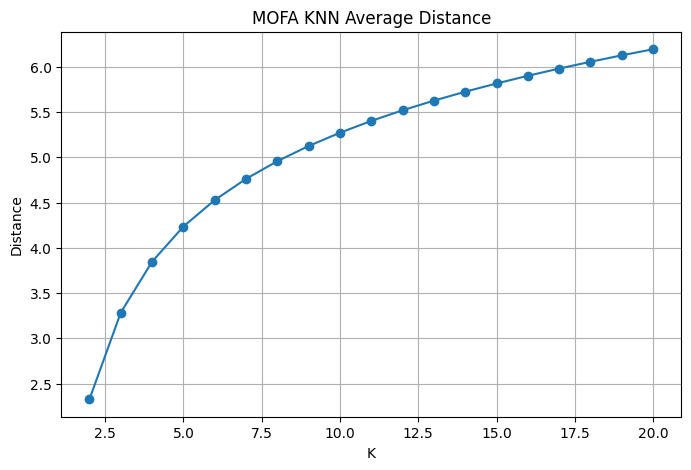

In [237]:
for method in knn_results_df["Method"].unique():

    subset = knn_results_df[
        knn_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["K"],
        subset["AverageDistance"],
        marker="o"
    )

    plt.title(f"{method} KNN Average Distance")
    plt.xlabel("K")
    plt.ylabel("Distance")
    plt.grid(True)
    plt.show()

In [238]:
def plot_knn_regions_existing(X, k=6, title="KNN Neighborhood Regions"):
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(X_2d)
    point_ids = np.arange(len(X_2d))
    h = 0.1
    x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
    y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    distances, indices = knn.kneighbors(grid_points, n_neighbors=1)
    Z = point_ids[indices.flatten()]
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(12,8))
    plt.contourf(
        xx, yy, Z,
        alpha=0.35
    )
    plt.scatter(
        X_2d[:,0],
        X_2d[:,1],
        s=25,
        edgecolor="black"
    )
    plt.title(f"{title} (k={k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    return X_2d

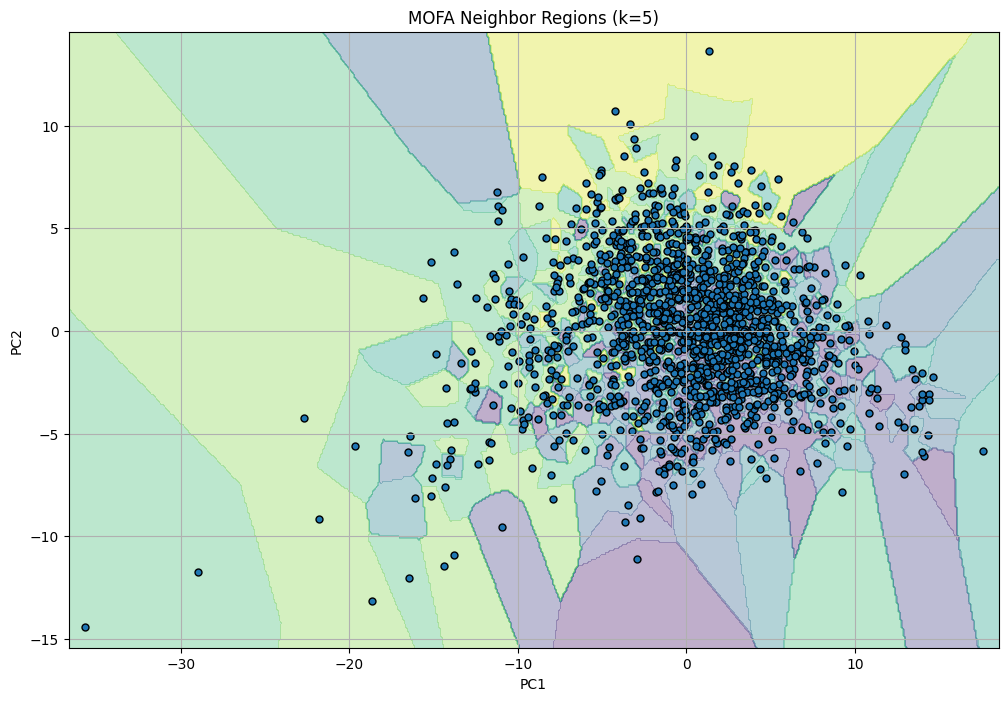

array([[ 3.3521264,  0.8551066],
       [-8.78433  , -4.2628484],
       [-2.3530743,  2.3210409],
       ...,
       [ 2.9358501,  3.2952993],
       [ 5.8151426,  2.4583938],
       [ 4.289261 ,  5.7697277]], shape=(1479, 2), dtype=float32)

In [239]:
plot_knn_regions_existing(
    embedding_dict["MOFA"],
    k=5,
    title="MOFA Neighbor Regions"
)

In [240]:
def plot_knn_regions_umap(X, k=6, title="KNN Neighborhood Regions (UMAP)"):
    # SWAP HERE: Replace PCA with UMAP
    reducer = UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)
    
    knn = NearestNeighbors(n_neighbors=k)
    knn.fit(X_2d)
    
    point_ids = np.arange(len(X_2d))
    h = 0.1
    x_min, x_max = X_2d[:,0].min()-1, X_2d[:,0].max()+1
    y_min, y_max = X_2d[:,1].min()-1, X_2d[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    distances, indices = knn.kneighbors(grid_points, n_neighbors=1)
    Z = point_ids[indices.flatten()]
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(12,8))
    plt.contourf(xx, yy, Z, alpha=0.35, cmap='viridis') # 'tab20' handles discrete IDs well
    plt.scatter(
        X_2d[:,0],
        X_2d[:,1],
        s=25,
        edgecolor="black",
        c='#2077b4'
    )
    plt.title(f"{title} (k={k})")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.grid(True)
    plt.show()

    return X_2d

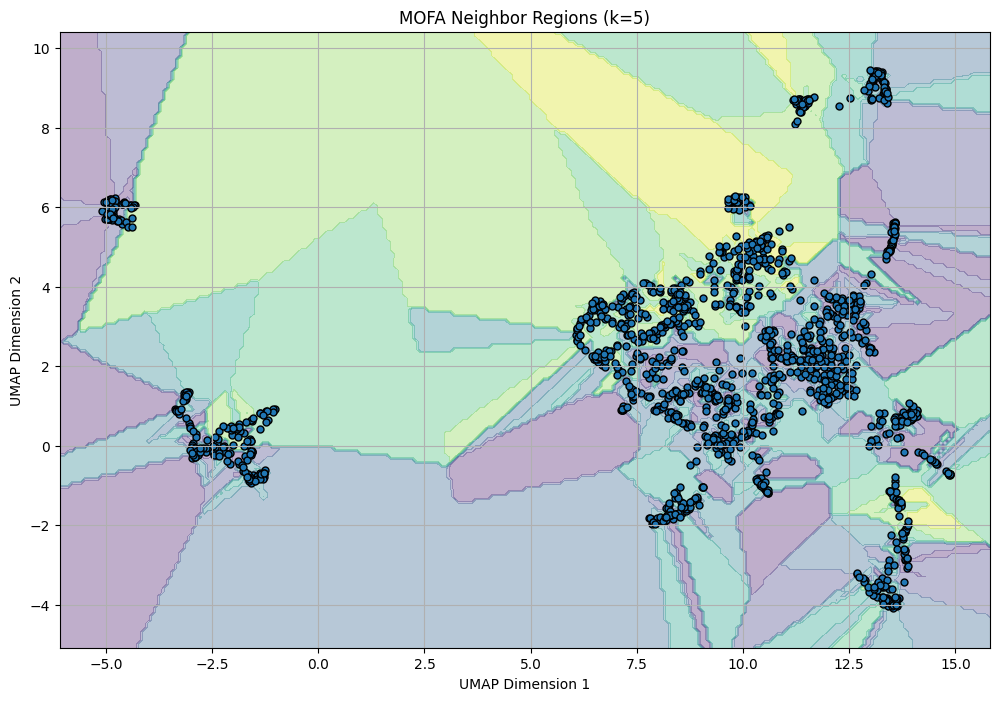

array([[10.109489  ,  0.39093262],
       [-4.432104  ,  6.065647  ],
       [10.615393  ,  0.5911174 ],
       ...,
       [ 9.905852  ,  6.2644296 ],
       [ 9.972853  ,  6.2644906 ],
       [ 9.811031  ,  6.2929044 ]], shape=(1479, 2), dtype=float32)

In [241]:
plot_knn_regions_umap(
    embedding_dict["MOFA"],
    k=5,
    title="MOFA Neighbor Regions"
)

In [242]:
def trainingknnmodel(factor_df):
    try:
        X = factor_df.drop(columns=["ModelID"]).values
        knn = NearestNeighbors(n_neighbors=6)
        knn.fit(X)
        distances, _ = knn.kneighbors(X)
        avg_distances = np.mean(distances, axis=1)
        knn_df = pd.DataFrame({
            "ModelID": factor_df["ModelID"],
            "AverageDistance": avg_distances
        })
        overall_mean_distance = np.mean(distances)
        print("Overall mean distance", overall_mean_distance)
        plt.figure(figsize=(10, 8))
        scatter1 = plt.scatter(
            X[:, 0],
            X[:, 1],
            c=avg_distances,
            cmap='viridis',
            alpha=0.8
        )
        plt.title("KNN Raw Factors (K=6)")
        plt.xlabel("Dim1")
        plt.ylabel("Dim2")
        plt.colorbar(scatter1, label="Average Distance to Neighbors")
        plt.show()
        reducer = UMAP(n_neighbors=35, min_dist=0.1, random_state=42)
        X_umap = reducer.fit_transform(X)
        
        plt.figure(figsize=(10, 8))
        scatter2 = plt.scatter(
            X_umap[:, 0], 
            X_umap[:, 1], 
            c=avg_distances, 
            cmap='viridis',
            s=25,
            alpha=0.8
        )
        plt.title("UMAP Projection of KNN Distances (K=6)")
        plt.xlabel("UMAP Dimension 1")
        plt.ylabel("UMAP Dimension 2")
        plt.colorbar(scatter2, label="Average Distance to Neighbors")
        plt.show()
        
    except Exception as e:
        print(e)
        raise


Overall mean distance 4.527891945878522


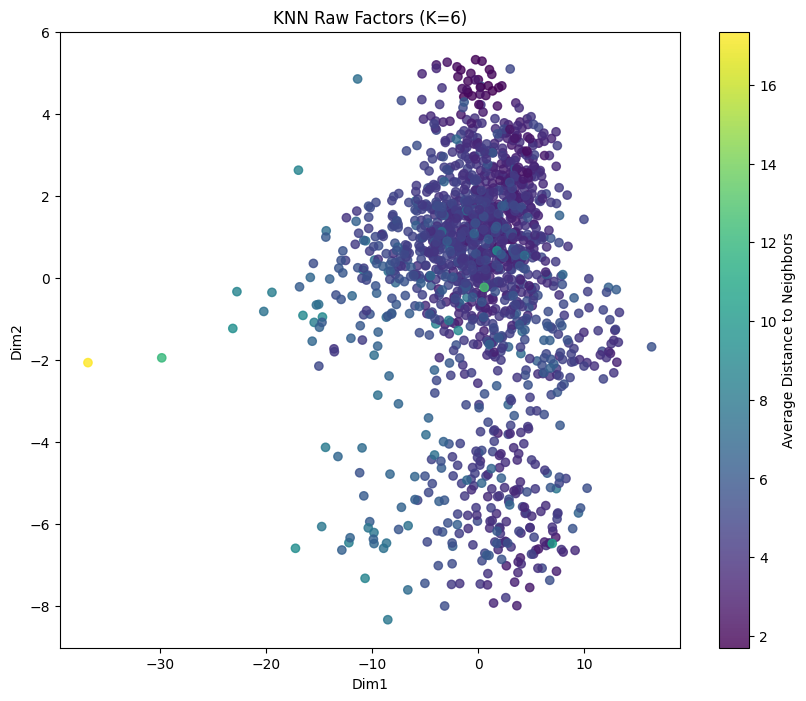

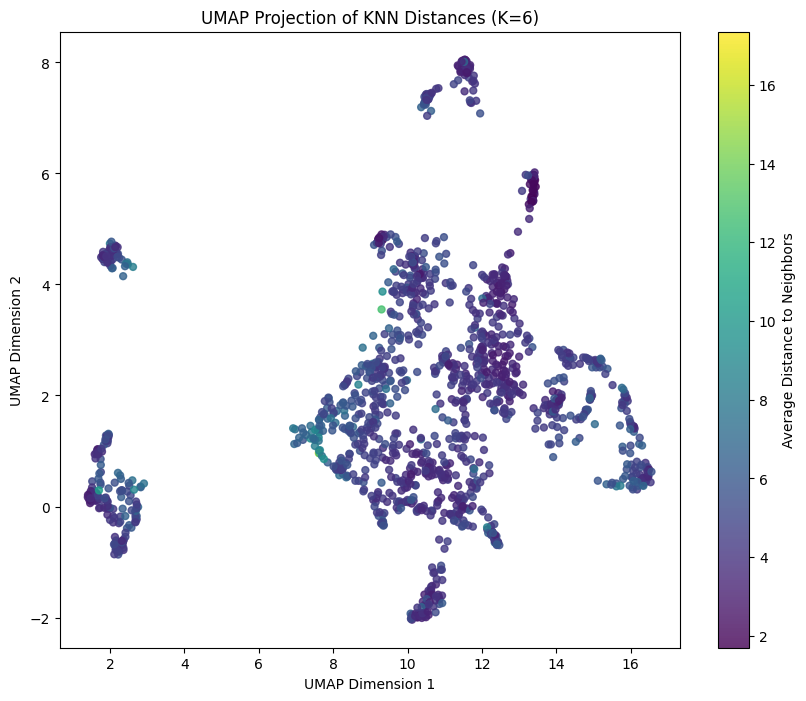

In [243]:
trainingknnmodel(factor_df)

## KNN as Radius based

   Method    Radius  AverageNeighborCount
0     PCA  0.500000              1.000000
1     PCA  0.821429              1.000000
2     PCA  1.142857              1.000000
3     PCA  1.464286              1.000000
4     PCA  1.785714              1.000000
5     PCA  2.107143              1.000000
6     PCA  2.428571              1.000000
7     PCA  2.750000              1.000000
8     PCA  3.071429              1.000000
9     PCA  3.392857              1.000000
10    PCA  3.714286              1.000000
11    PCA  4.035714              1.000000
12    PCA  4.357143              1.000000
13    PCA  4.678571              1.000000
14    PCA  5.000000              1.000000
15    SVD  0.500000              1.000000
16    SVD  0.821429              1.000000
17    SVD  1.142857              1.000000
18    SVD  1.464286              1.000000
19    SVD  1.785714              1.000000
20    SVD  2.107143              1.000000
21    SVD  2.428571              1.000000
22    SVD  2.750000              1

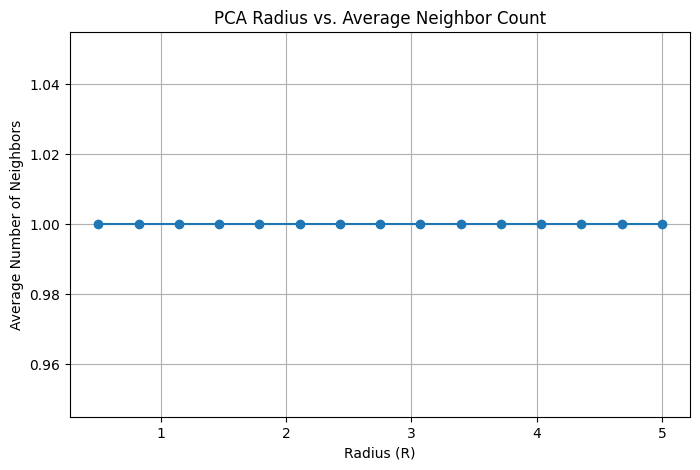

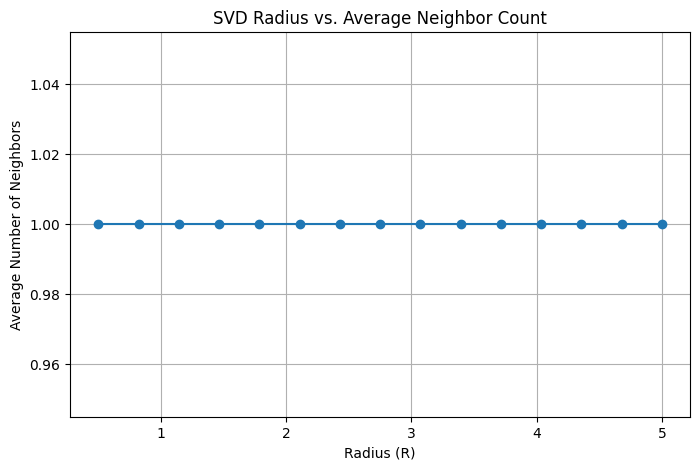

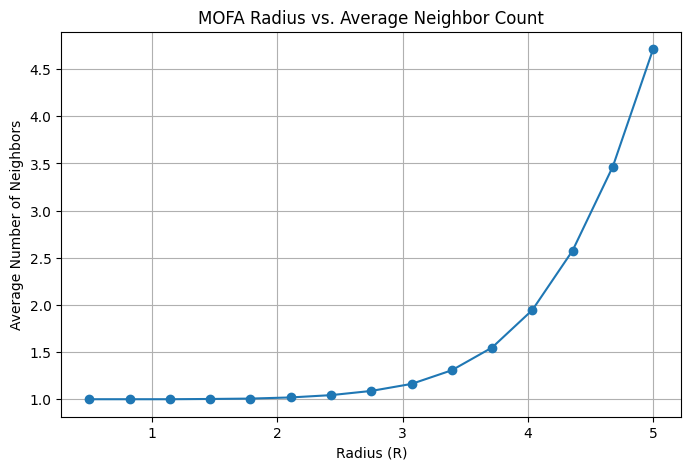

In [244]:
radius_results = []
radii_to_test = np.linspace(0.5, 5.0, 15)

for method, X in embedding_dict.items():

    for r in radii_to_test:
        rn = NearestNeighbors(radius=r)
        rn.fit(X)
        _, indices = rn.radius_neighbors(X)
        avg_neighbor_count = np.mean([len(idx) for idx in indices])

        radius_results.append({
            "Method": method,
            "Radius": r,
            "AverageNeighborCount": avg_neighbor_count
        })

radius_results_df = pd.DataFrame(radius_results)
print(radius_results_df)

for method in radius_results_df["Method"].unique():

    subset = radius_results_df[
        radius_results_df["Method"] == method
    ]

    plt.figure(figsize=(8, 5))

    plt.plot(
        subset["Radius"],
        subset["AverageNeighborCount"],
        marker="o",
        color="#1f77b4"
    )

    plt.title(f"{method} Radius vs. Average Neighbor Count")
    plt.xlabel("Radius (R)")
    plt.ylabel("Average Number of Neighbors")
    plt.grid(True)
    plt.show()

In [245]:
def plot_radius_regions_umap(X, r=3, title="Radius Neighborhood Regions (UMAP)"):
    reducer = UMAP(n_components=2, random_state=42)
    X_2d = reducer.fit_transform(X)
    rn = NearestNeighbors(radius=r)
    rn.fit(X_2d)
    h = 0.1
    x_min, x_max = X_2d[:,0].min() - 1, X_2d[:,0].max() + 1
    y_min, y_max = X_2d[:,1].min() - 1, X_2d[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    _, indices = rn.radius_neighbors(grid_points)
    Z = np.array([len(idx) for idx in indices])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(12, 8))
    contour = plt.contourf(xx, yy, Z, alpha=0.35, cmap='viridis') 
    
    plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        s=25,
        edgecolor="black",
        c='#2077b4',
        alpha=0.9
    )
    
    plt.title(f"{title} (Radius={r})")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.colorbar(contour, label="Number of Neighbors within Radius")
    plt.grid(True, linestyle='-', alpha=0.5)
    plt.show()

    return X_2d

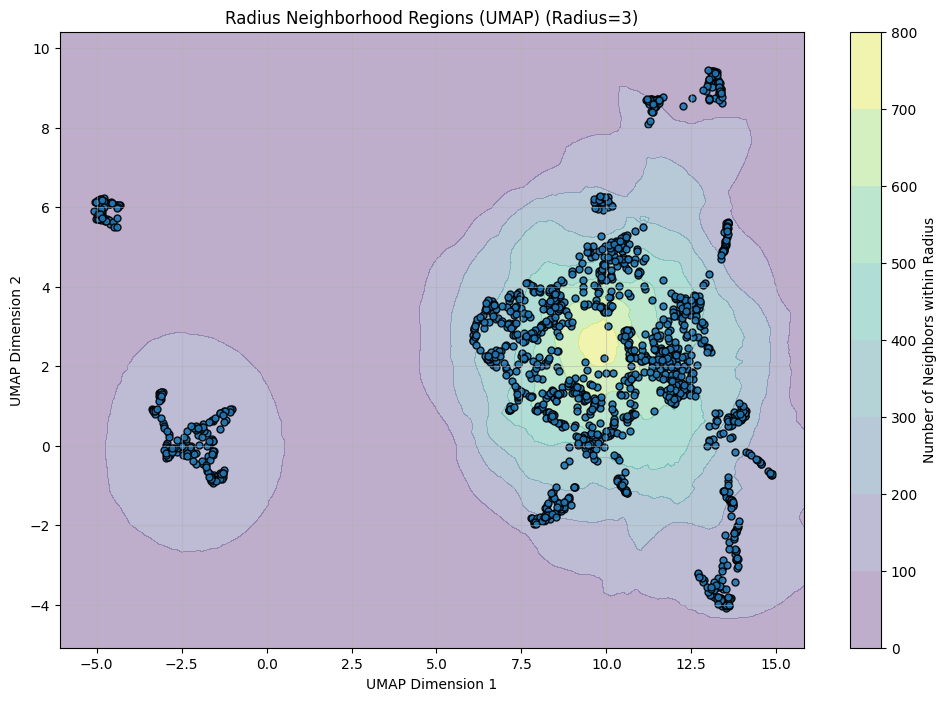

array([[10.109489  ,  0.39093262],
       [-4.432104  ,  6.065647  ],
       [10.615393  ,  0.5911174 ],
       ...,
       [ 9.905852  ,  6.2644296 ],
       [ 9.972853  ,  6.2644906 ],
       [ 9.811031  ,  6.2929044 ]], shape=(1479, 2), dtype=float32)

In [246]:
plot_radius_regions_umap(embedding_dict["MOFA"], r=3, title="Radius Neighborhood Regions (UMAP)")

## HDBSCAN

In [247]:
hdbscan_results = []

for method, X in embedding_dict.items():

    for min_size in range(2, 21):

        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size
        )

        labels = clusterer.fit_predict(X)

        if len(set(labels)) > 1:

            hdbscan_results.append({
                "Method": method,
                "MinClusterSize": min_size,
                "Silhouette": silhouette_score(X, labels),
                "Clusters": len(set(labels)) - (1 if -1 in labels else 0)
            })

hdbscan_results_df = pd.DataFrame(hdbscan_results)
print(hdbscan_results_df)

   Method  MinClusterSize  Silhouette  Clusters
0     PCA               2    0.052806         6
1     PCA               3    0.070846         3
2     PCA               4    0.156378         2
3     PCA               5    0.154374         2
4     PCA               6   -0.004959         4
5     PCA               7   -0.008122         4
6     PCA               8    0.001059         3
7     PCA               9    0.025232         2
8     PCA              10    0.022475         2
9     PCA              11    0.020023         2
10    PCA              12    0.016519         2
11    PCA              13    0.011960         2
12    PCA              14    0.008487         2
13    PCA              15    0.006401         2
14    PCA              16   -0.000035         2
15    PCA              17   -0.001236         2
16    PCA              18   -0.002728         2
17    PCA              19   -0.005039         2
18    PCA              20   -0.005745         2
19    SVD               2   -0.181150   

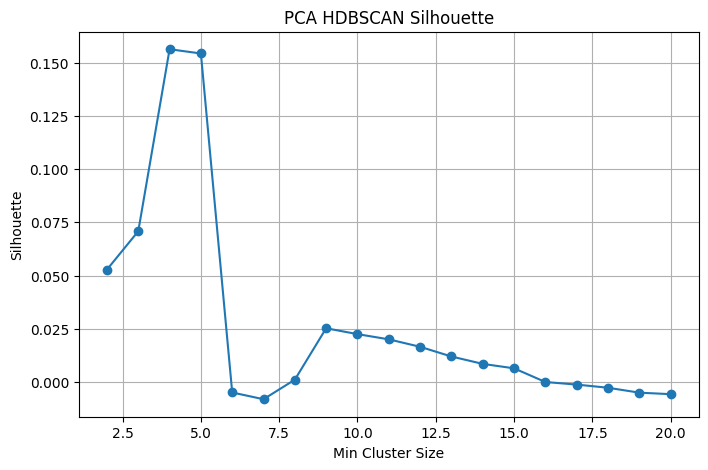

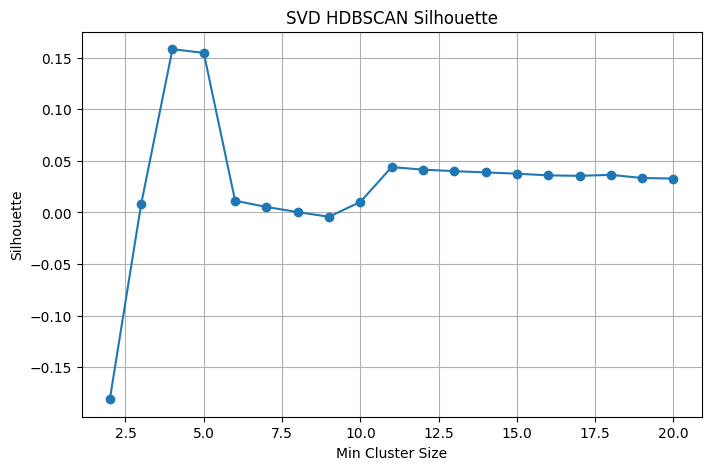

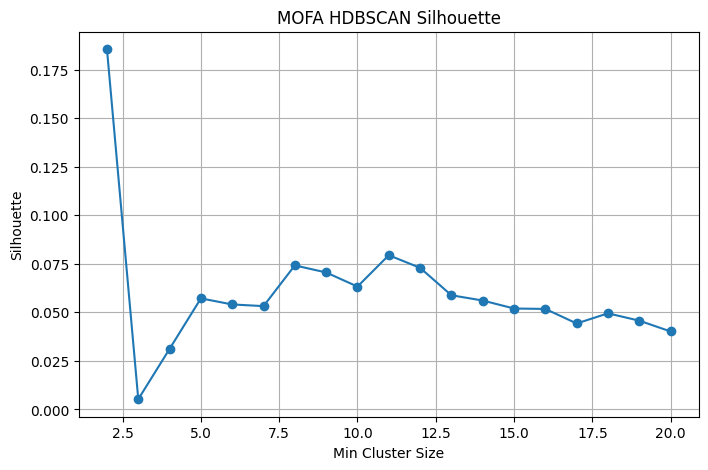

In [248]:
for method in hdbscan_results_df["Method"].unique():

    subset = hdbscan_results_df[
        hdbscan_results_df["Method"] == method
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        subset["MinClusterSize"],
        subset["Silhouette"],
        marker="o"
    )

    plt.title(f"{method} HDBSCAN Silhouette")
    plt.xlabel("Min Cluster Size")
    plt.ylabel("Silhouette")
    plt.grid(True)
    plt.show()

In [249]:
X = embedding_dict['MOFA']
clusterer = hdbscan.HDBSCAN(min_cluster_size=6)
labels = clusterer.fit_predict(X)

In [250]:
hdbscan_clusters = pd.DataFrame({
    "ModelID": factor_df["ModelID"].values,
    "Cluster": labels
})

print(hdbscan_clusters)

         ModelID  Cluster
0     ACH-000001        0
1     ACH-000002       -1
2     ACH-000003        0
3     ACH-000004        1
4     ACH-000005       -1
...          ...      ...
1474  ACH-003157        0
1475  ACH-003158        0
1476  ACH-003159        0
1477  ACH-003160        0
1478  ACH-003161        0

[1479 rows x 2 columns]


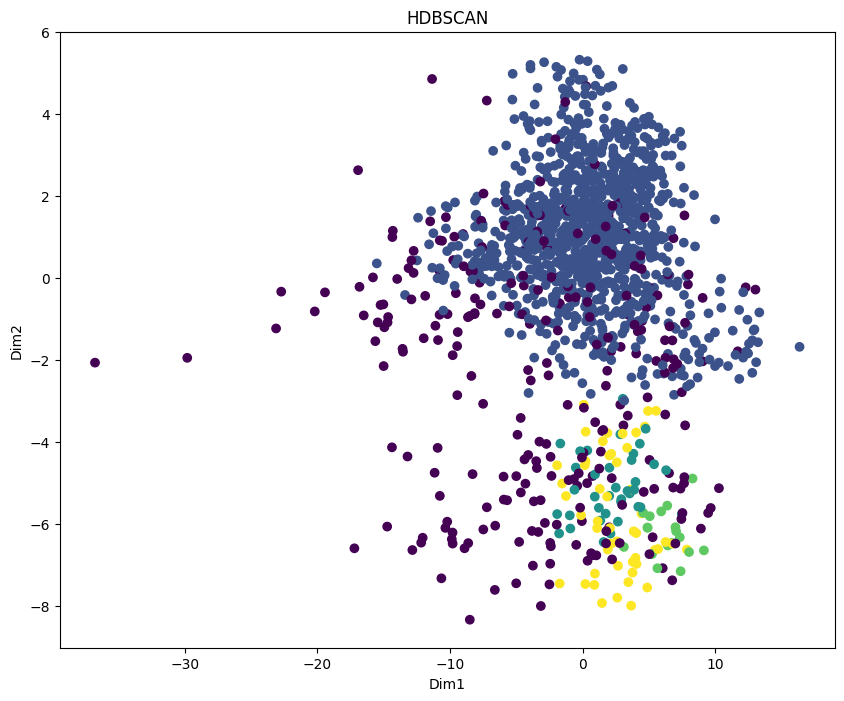

In [251]:
plt.figure(figsize=(10,8))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels
)

plt.title(
    f"HDBSCAN"
)

plt.xlabel("Dim1")
plt.ylabel("Dim2")

plt.show()

# Cosine similarity

In [252]:
depmap_df = depmap_omicsexpressionallgenes_cleaned_df.copy()
depmap_df = (
    depmap_df
    .set_index("ModelID")
    .reindex(master_ids)
    .reset_index()
)
model_ids = depmap_df["ModelID"]
rna_view = depmap_df.drop(columns=["ModelID"])
rna_view = rna_view.loc[:, ~rna_view.columns.duplicated()]


In [253]:
ent_rna = entry_point()
ent_rna.set_data_matrix(
    data=[
        [
            rna_view.values.copy()
        ]
    ],
    views_names=[
        "RNA"
    ],
    groups_names=[
        "AllSamples"
    ]
)
ent_rna.set_data_options(
    scale_views=False,
    scale_groups=False,
    center_groups=True,
    use_float32=True
)
N_FACTORS = 20

ent_rna.set_model_options(
    factors=N_FACTORS,
    spikeslab_factors=False,
    spikeslab_weights=True,
    ard_factors=False,
    ard_weights=True
)
ent_rna.set_train_options(
    iter=1000,
    convergence_mode="fast",
    verbose=True,
    seed=42
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         


Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='RNA' group='AllSamples' with N=1479 samples and D=19916 features...


use_float32 set to True: replacing float64 arrays by float32 arr

In [254]:
ent_rna.build()
ent_rna.run()



######################################
## Training the model with seed 42 ##
######################################


ELBO before training:
Z=-1811.84  W=-513278.28  Tau=-106320.52  Y=-380939325.09  AlphaW=-613.18  ThetaW=0.00  
Total: -381561348.91

Iteration 1: time=9.47, ELBO=-38424686.97, deltaELBO=343136661.946 (89.92961759%), Factors=20
- ELBO decomposition:  Z=-122371.06  W=-491846.10  Tau=-175229.95  Y=-37634531.61  AlphaW=-708.25  ThetaW=0.00  
- Time spent in ELBO computation: 1.3%
- Variance explained:  View 0: 26.10%
- Fraction of zero weights:  View 0: 64%
- Maximum correlation between factors: 0.30
- Factor norms:  29.85 7.86 7.40 10.34 13.00 12.04 9.35 6.93 6.61 5.05 5.71 6.08 2.95 4.24 3.36 0.63 3.03 2.14 1.86 1.47
- Tau per view (average):  View 0: 1.37


Iteration 2: time=8.96, ELBO=-35024257.96, deltaELBO=3400429.004 (0.89118801%), Factors=20
- ELBO decomposition:  Z=-151251.52  W=-1152495.38  Tau=-175245.25  Y=-33544557.53  AlphaW=-708.28  ThetaW=0.00  
- Time spe

In [255]:
print(factor_df.shape)
newfactor_df = factor_df.set_index('ModelID')
newfactor_df.index.name = None
print(newfactor_df.shape)
print(newfactor_df.head(10))

(1479, 21)
(1479, 20)
             Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
ACH-000001  3.254857  1.094717  2.590412 -2.309249  0.354017 -0.827697   
ACH-000002 -8.913815 -6.591320 -1.456575  2.323557 -2.622683  5.152744   
ACH-000003 -1.974996  0.382741  3.195194 -0.195651  1.694738  3.794047   
ACH-000004  3.533759 -5.255245 -1.221656  2.728721 -0.539121 -0.111255   
ACH-000005  6.502093 -4.759291 -1.751314  2.923748  5.435082 -0.826647   
ACH-000006  6.281332 -4.687353 -0.996876  4.205674 -0.827742 -1.716352   
ACH-000007 -3.140200 -1.133406  4.849031  1.008237  0.704492  1.096342   
ACH-000008  1.957181  2.518062 -1.971123  1.737143 -1.637133  5.298716   
ACH-000009  3.370260  0.751687  2.960185  0.212946  5.105789  2.951309   
ACH-000011 -4.399904  1.082556  0.035951 -0.143865 -3.624165  1.595117   

             Factor7   Factor8   Factor9  Factor10  Factor11  Factor12  \
ACH-000001 -1.840472  0.290216 -1.815119  0.789199  1.463745 -2.396510   
ACH-000002  0.0

In [256]:
w_rna = ent_rna.model.nodes["W"].getExpectation()[0]

print(w_rna.shape)

w_rna_df = pd.DataFrame(
    w_rna,
    index=rna_view.columns,
    columns=[
        f"Factor{i+1}"
        for i in range(w_rna.shape[1])
    ]
)

print(w_rna_df.shape)
print(w_rna_df.head())

(19916, 20)
(19916, 20)
                  Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
ENSG00000000003 -0.004499  0.241300  0.096642 -0.107220  0.064177  0.018789   
ENSG00000000005 -0.000940 -0.000596  0.000279 -0.045310  0.035727  0.001706   
ENSG00000000419  0.032822  0.132097  0.000423  0.000787  0.154234 -0.004355   
ENSG00000000457  0.092746 -0.081186  0.079093  0.009782  0.022319 -0.117398   
ENSG00000000460  0.131819 -0.052546 -0.000251  0.018039  0.114351  0.052626   

                  Factor7   Factor8   Factor9  Factor10  Factor11  Factor12  \
ENSG00000000003 -0.000319 -0.053062  0.038971  0.010199  0.016029 -0.008942   
ENSG00000000005  0.021751 -0.087541 -0.025845  0.005138 -0.001619 -0.050094   
ENSG00000000419 -0.001030  0.048877  0.013717  0.048369  0.002214 -0.004152   
ENSG00000000457  0.090402  0.000101 -0.019473  0.058615  0.011707 -0.070225   
ENSG00000000460 -0.037537  0.064267  0.037767 -0.000916 -0.035455  0.003098   

                 Factor13 

In [257]:
Z = newfactor_df.values   # (1479 × 20)
W = w_rna_df.values       # (19862 × 20)

# Compute cosine similarity
similarity_matrix = cosine_similarity(Z, W)

# Convert to dataframe
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=newfactor_df.index,   # rows = cell lines
    columns=w_rna_df.index       # columns = gene ids
)

print(similarity_df.shape)
similarity_df = similarity_df.sort_index(axis=1)
print(similarity_df.head())

(1479, 19916)
            ENSG00000000003  ENSG00000000005  ENSG00000000419  \
ACH-000001         0.310630         0.301042         0.127128   
ACH-000002        -0.337294        -0.072216        -0.363083   
ACH-000003         0.353544         0.408282        -0.076558   
ACH-000004        -0.375011         0.047295        -0.229406   
ACH-000005        -0.257095         0.082904         0.085128   

            ENSG00000000457  ENSG00000000460  ENSG00000000938  \
ACH-000001         0.097756        -0.079152        -0.194714   
ACH-000002        -0.228867        -0.127522         0.350895   
ACH-000003        -0.253800        -0.376970        -0.108790   
ACH-000004        -0.068740         0.016612         0.300068   
ACH-000005         0.034434         0.259665         0.252194   

            ENSG00000000971  ENSG00000001036  ENSG00000001084  \
ACH-000001        -0.212897        -0.044155         0.279194   
ACH-000002         0.049588        -0.089310        -0.209771   
ACH-00000

In [258]:
similarity_df.to_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\cleaned_data\similarity.csv')
similarity_df.describe()

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288699,ENSG00000288701,ENSG00000288702,ENSG00000288705,ENSG00000288709,ENSG00000288710,ENSG00000288711,ENSG00000288721,ENSG00000288722,ENSG00000288725
count,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,...,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000
mean,0.023771,0.001502,0.023768,-0.010649,0.015396,-0.020530,0.017095,0.023513,0.006781,0.007153,...,0.013582,0.018817,0.008310,0.008278,0.012468,0.004269,0.000488,-0.005732,0.007809,-0.009977
std,0.226059,0.181876,0.226143,0.245457,0.243580,0.216327,0.218104,0.227198,0.231158,0.290434,...,0.261700,0.307446,0.209107,0.215994,0.228219,0.237265,0.254032,0.268503,0.227132,0.237751
min,-0.683488,-0.578595,-0.581384,-0.759448,-0.667879,-0.369095,-0.540298,-0.723899,-0.582814,-0.667272,...,-0.672281,-0.785080,-0.493355,-0.517532,-0.515482,-0.636917,-0.628377,-0.683564,-0.531469,-0.649943
25%,-0.049330,-0.124144,-0.144911,-0.179894,-0.157447,-0.160805,-0.139095,-0.114367,-0.166823,-0.210235,...,-0.188642,-0.203414,-0.146198,-0.148218,-0.156354,-0.166040,-0.188840,-0.213080,-0.163582,-0.179674
50%,0.071189,-0.014935,0.018371,0.006525,0.024681,-0.076620,0.005715,0.062767,-0.005948,0.014845,...,0.023979,0.058934,-0.036778,-0.035807,-0.012737,0.003393,-0.030352,-0.017625,-0.008838,-0.020773
75%,0.170143,0.122156,0.183041,0.162082,0.193894,0.023328,0.174366,0.186209,0.169007,0.242574,...,0.212756,0.257897,0.173419,0.149978,0.141321,0.162249,0.162903,0.190410,0.183203,0.144002
max,0.550707,0.589695,0.663763,0.684202,0.609643,0.703297,0.586798,0.575755,0.685296,0.644069,...,0.606470,0.628644,0.654907,0.680807,0.771807,0.744258,0.728857,0.736169,0.648385,0.621706


In [259]:
print(similarity_df.isna().sum())

ENSG00000000003    0
ENSG00000000005    0
ENSG00000000419    0
ENSG00000000457    0
ENSG00000000460    0
                  ..
ENSG00000288710    0
ENSG00000288711    0
ENSG00000288721    0
ENSG00000288722    0
ENSG00000288725    0
Length: 19916, dtype: int64


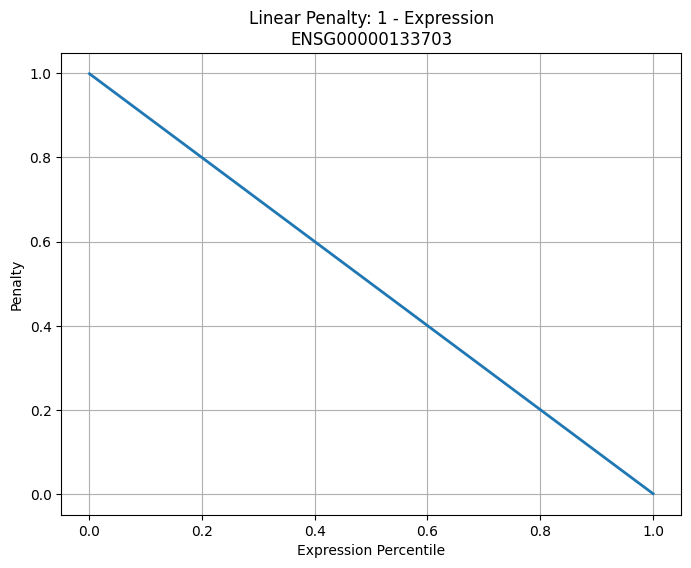

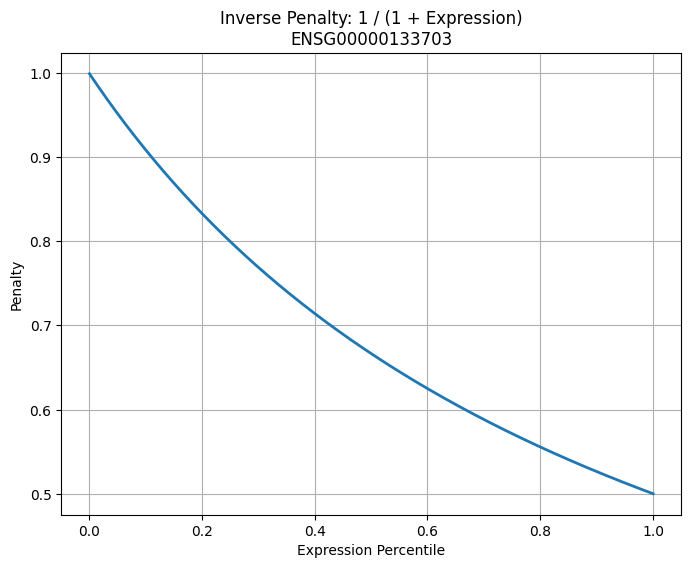

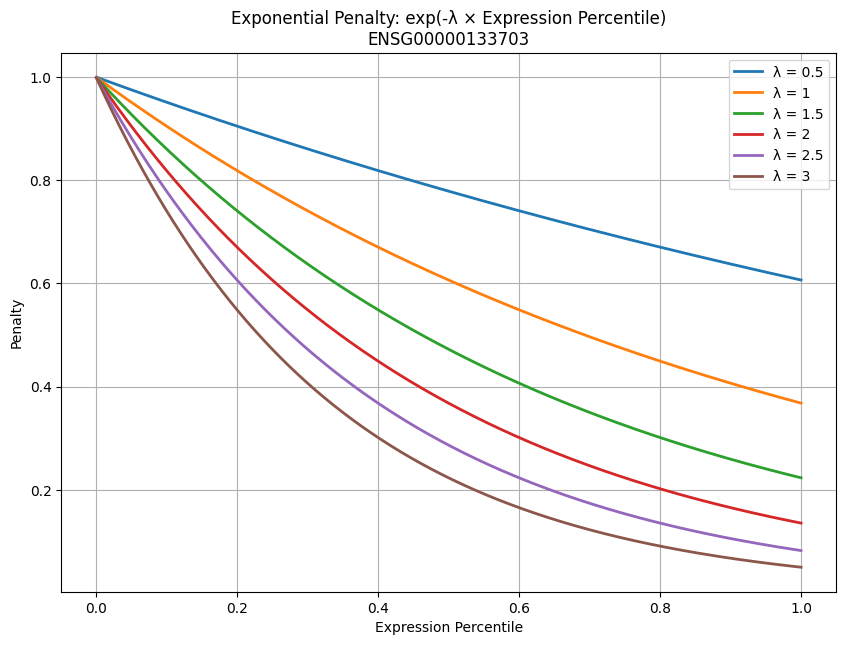

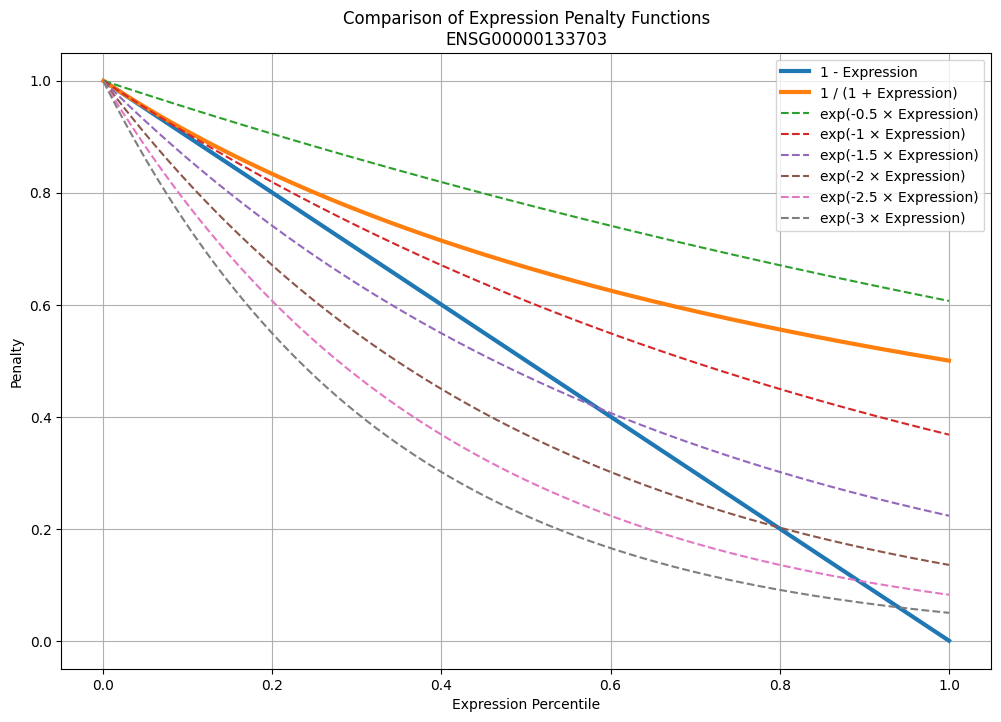

In [260]:
gene_col = "ENSG00000133703"
similarity_df_minmaxed = similarity_df.copy()
similarity_df_minmaxed = similarity_df_minmaxed.set_index(similarity_df_minmaxed.columns[0])
minMax = MinMaxScaler()
similarity_df_minmaxed.iloc[:, :] = minMax.fit_transform(similarity_df_minmaxed)
similarity_df_minmaxed = similarity_df_minmaxed.reset_index()
result = compare_expression_penalties(similarity_df_minmaxed,gene_col,lambdas=(0.5, 1, 1.5, 2, 2.5, 3))

In [261]:
def plot_raw_expression_slope(df, gene_col):
    expression = (
        df[gene_col]
        .dropna()
        .astype(float)
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        np.arange(1, len(expression) + 1),
        expression.values,
        linewidth=2
    )

    plt.xlabel("Cell Lines")
    plt.ylabel("Raw Expression Value")
    plt.title(f"Descending Expression Profile: {gene_col}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return expression

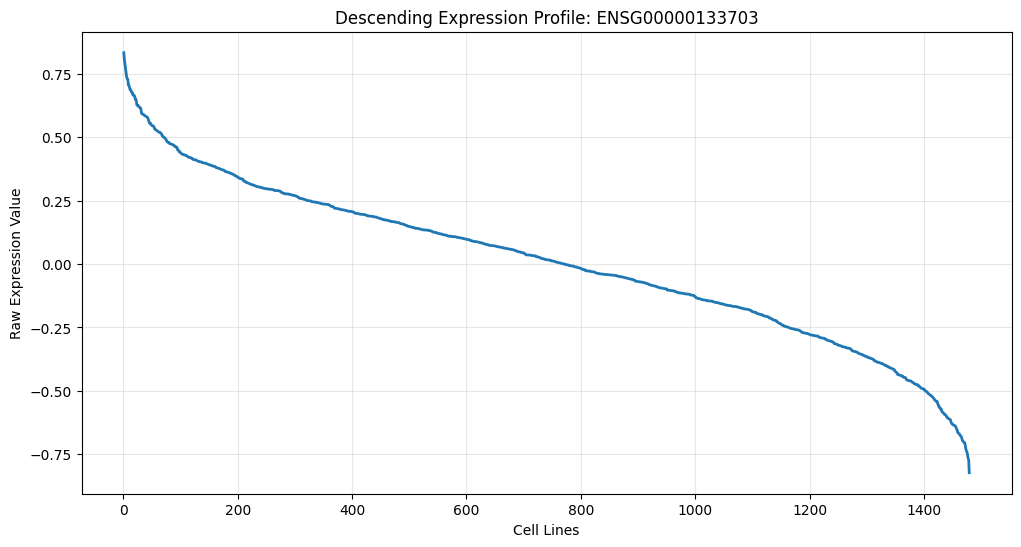

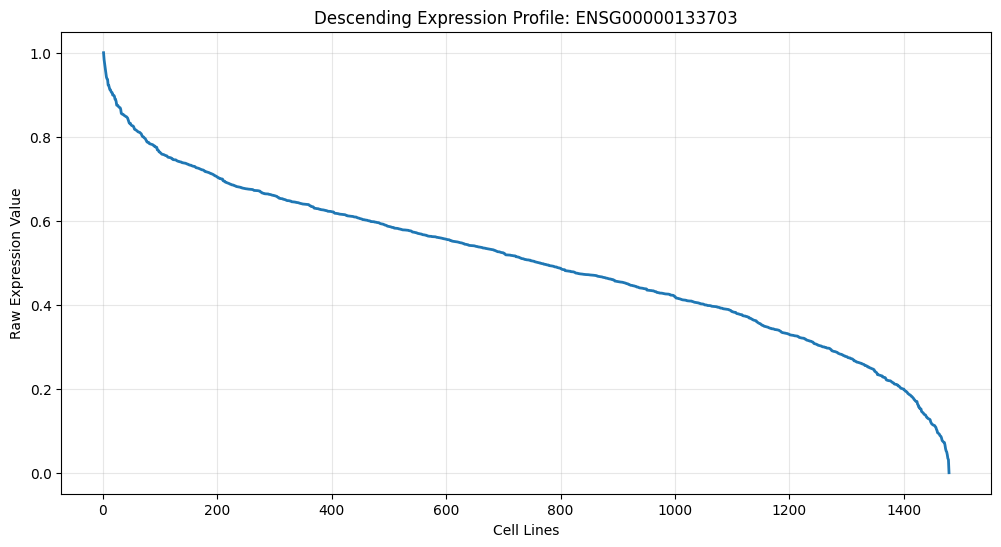

In [262]:
gene_col = "ENSG00000133703"
result = plot_raw_expression_slope(similarity_df,gene_col)
result2 = plot_raw_expression_slope(similarity_df_minmaxed,gene_col)

Cell lines: 1479
Genes: 19916
Maximum difference: 0.008573949
Mean difference: 0.0045248466
Median difference: 0.0043553114


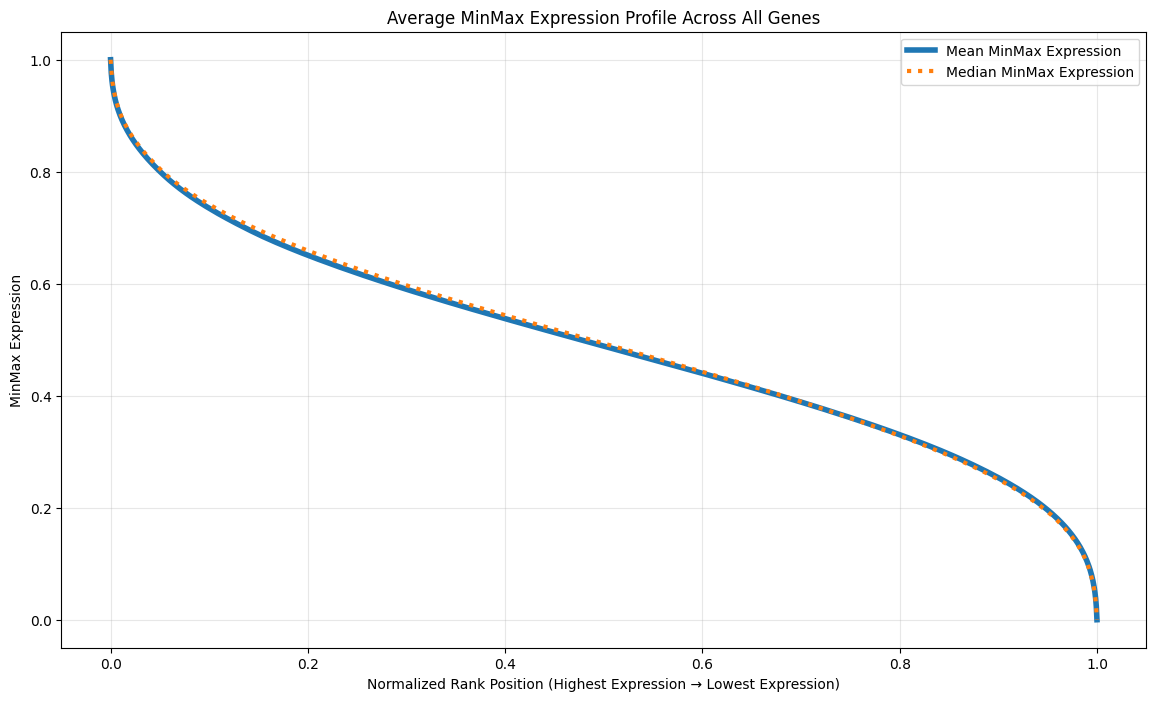

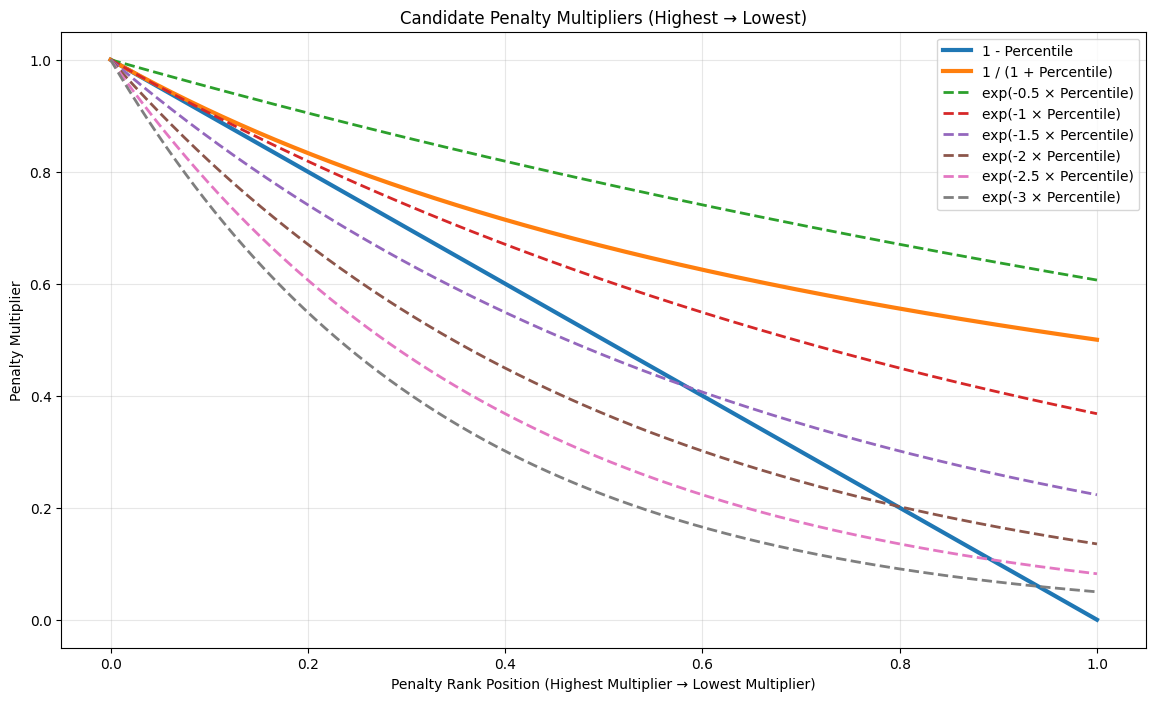

In [263]:
result = compare_mean_expression_with_penalties(similarity_df_minmaxed,id_col="ModelID")

In [265]:
from IPython.display import display
scoreoftop10 = pd.read_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\CelllineSelector\data\test\top10\final_top10_df.csv')
scoreoftop10 = scoreoftop10[['cell_line_name','stripped_cell_line_name','ModelID','target_evidence','exclusion_evidence','exclusion_percentile','exclusion_penalty','net_evidence','agreement','modality_score','confidence_score','target_similarity','exclusion_similarity','exclusion_similarity_percentile','exclusion_similarity_penalty','net_similarity','final_score']]
display(scoreoftop10.head(10))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Shankar\\Desktop\\AstraZeneca\\code\\astrazeneca\\CelllineSelector\\data\\test\\top10\\final_top10_df.csv'

In [ ]:
exclusion = pd.read_csv(r'C:\Users\Shankar\Desktop\AstraZeneca\code\astrazeneca\CelllineSelector\data\test\top10\full_scored_data.csv')
exclusion = exclusion[exclusion['exclusion_evidence'] != 0.0]
print(exclusion['exclusion_evidence'])

0       0.002630
4       0.005233
6       0.005233
7       0.036090
12      0.030856
          ...   
1402    0.002630
1404    0.002630
1405    0.043750
1407    0.005233
1409    0.002630
Name: exclusion_evidence, Length: 686, dtype: float64
